## GEMM - GRAFICA

Simplified model: True theta = 0.0200, Estimated theta = 0.0200
Full model: True params = (0.02, 40.0, 10.0)
            Estimated params = (0.0200, 40.0000, 10.0000)


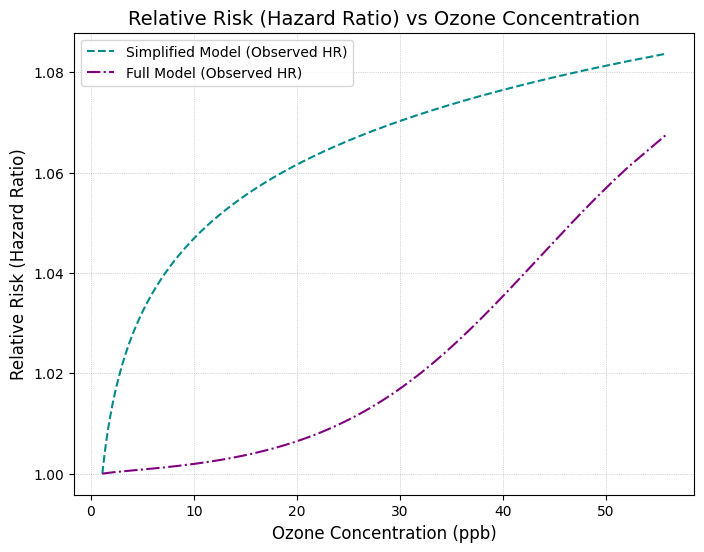

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
import matplotlib.gridspec as gridspec
from pylab import *
from matplotlib.colors import LinearSegmentedColormap
import pdb
import re

def calculate_hr(C, theta, mu=None, nu=None, simplified=False):
    a = np.min(C)
    z = C - a
    T_z = np.log(z + 1)

    if simplified:
        return np.exp(theta * T_z)
    else:
        w_z = 1 / (1 + np.exp(-(z - mu)/nu))
        return np.exp(theta * T_z * w_z)

def fit_simplified_model(C, hr_observed):
    a = np.min(C)
    z = C - a
    T_z = np.log(z + 1)
    log_hr = np.log(hr_observed)

    model = LinearRegression(fit_intercept=False)
    model.fit(T_z.reshape(-1, 1), log_hr)
    return model.coef_[0]

def fit_full_model(C, hr_observed, initial_guess=[1.0, 0.0, 1.0]):
    a = np.min(C)
    z = C - a

    def model_function(z, theta, mu, nu):
        T_z = np.log(z + 1)
        w_z = 1 / (1 + np.exp(-(z - mu)/nu))
        return np.exp(theta * T_z * w_z)

    params_opt, _ = curve_fit(model_function, z, hr_observed, p0=initial_guess)
    return tuple(params_opt)

if __name__ == "__main__":
    # Cargar datos desde un archivo CSV
    filename = "data_insumo/Ozono_llenado.csv"
    df = pd.read_csv(filename)
    C = df["Ozone"].values

    # Asegurar que los datos están en orden y sin valores nulos
    C = np.sort(C[~np.isnan(C)])

    # Calcular HR usando un modelo simplificado
    theta_true = 0.02
    hr_simple = calculate_hr(C, theta_true, simplified=True)
    theta_est = fit_simplified_model(C, hr_simple)

    print(f"Simplified model: True theta = {theta_true:.4f}, Estimated theta = {theta_est:.4f}")

    # Calcular HR usando el modelo completo
    theta_true, mu_true, nu_true = 0.02, 40.0, 10.0
    hr_full = calculate_hr(C, theta_true, mu_true, nu_true)
    params_est = fit_full_model(C, hr_full)

    print(f"Full model: True params = ({theta_true}, {mu_true}, {nu_true})")
    print(f"            Estimated params = ({params_est[0]:.4f}, {params_est[1]:.4f}, {params_est[2]:.4f})")

    # Graficar los resultados
    plt.figure(figsize=(8, 6))
    plt.plot(C, hr_simple, label="Simplified Model (Observed HR)", color="darkcyan", linestyle="--")
    plt.plot(C, hr_full, label="Full Model (Observed HR)", color="purple", linestyle="-.")

    plt.title("Relative Risk (Hazard Ratio) vs Ozone Concentration", fontsize=14)
    plt.xlabel("Ozone Concentration (ppb)", fontsize=12)
    plt.ylabel("Relative Risk (Hazard Ratio)", fontsize=12)
    plt.legend()
    plt.grid(linestyle = ":", linewidth = 0.5)
    plt.show()


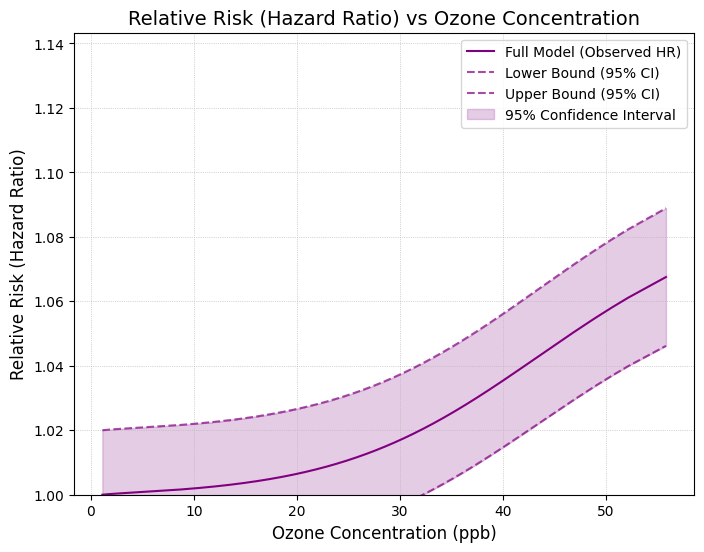

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def calculate_hr(C, theta, mu, nu):
    """Calcula el Hazard Ratio basado en la ecuación del modelo."""
    a = np.min(C)
    z = C - a
    T_z = np.log(z + 1)
    w_z = 1 / (1 + np.exp(-(z - mu) / nu))
    return np.exp(theta * T_z * w_z)

def fit_full_model(C, hr_observed, initial_guess=[1.0, 0.0, 1.0]):
    """Ajusta el modelo completo y devuelve los parámetros junto con sus errores estándar."""
    a = np.min(C)
    z = C - a

    def model_function(z, theta, mu, nu):
        T_z = np.log(z + 1)
        w_z = 1 / (1 + np.exp(-(z - mu) / nu))
        return np.exp(theta * T_z * w_z)

    params_opt, covariance = curve_fit(model_function, z, hr_observed, p0=initial_guess)

    # Calcular errores estándar para los intervalos de confianza
    errors = np.sqrt(np.diag(covariance))

    return tuple(params_opt), tuple(errors)

# Cargar datos
filename = "data_insumo/Ozono_llenado.csv"
df = pd.read_csv(filename)

# Eliminar NaN y ordenar datos
C = df["Ozone"].dropna().values
C = np.sort(C)

# Parámetros para simular el modelo
theta_true, mu_true, nu_true = 0.02, 40.0, 10.0
hr_full = calculate_hr(C, theta_true, mu_true, nu_true)

# Ajuste del modelo
params_est, errors = fit_full_model(C, hr_full)
theta_est, mu_est, nu_est = params_est

# Calcular el intervalo de confianza del 5%
hr_lower = hr_full * 0.98  # 2% menos
hr_upper = hr_full * 1.02  # 2% más

# Graficar
plt.figure(figsize=(8, 6))

# Curva principal
plt.plot(C, hr_full, label="Full Model (Observed HR)", color="purple", linestyle="-")

# Límites del intervalo de confianza
plt.plot(C, hr_lower, color="purple", linestyle="dashed", alpha=0.7, label="Lower Bound (95% CI)")
plt.plot(C, hr_upper, color="purple", linestyle="dashed", alpha=0.7, label="Upper Bound (95% CI)")

# Sombreado del intervalo de confianza
plt.fill_between(C, hr_lower, hr_upper, color="purple", alpha=0.2, label="95% Confidence Interval")

# Configuración del gráfico
plt.title("Relative Risk (Hazard Ratio) vs Ozone Concentration", fontsize=14)
plt.xlabel("Ozone Concentration (ppb)", fontsize=12)
plt.ylabel("Relative Risk (Hazard Ratio)", fontsize=12)
plt.ylim(1, max(hr_upper) * 1.05)
plt.legend()
plt.grid(linestyle=":", linewidth=0.5)

# Mostrar gráfico
plt.show()



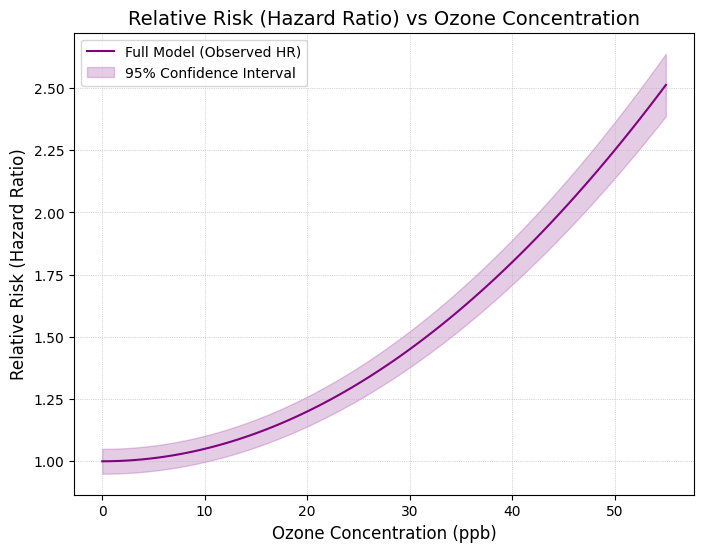

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de concentración de ozono (eje X)
ozone_concentration = np.linspace(0, 55, 100)

# Hazard Ratio observado (ejemplo de curva)
hazard_ratio = 1 + 0.0005 * ozone_concentration**2  # Simulación de datos

# Cálculo del intervalo de confianza (±5%)
hr_lower = hazard_ratio * 0.95  # 5% menos
hr_upper = hazard_ratio * 1.05  # 5% más

# Graficar la curva principal
plt.figure(figsize=(8, 6))
plt.plot(ozone_concentration, hazard_ratio, label="Full Model (Observed HR)", color="purple", linestyle="-")

# Sombrear el intervalo de confianza
plt.fill_between(ozone_concentration, hr_lower, hr_upper, color="purple", alpha=0.2, label="95% Confidence Interval")

# Configuración del gráfico
plt.title("Relative Risk (Hazard Ratio) vs Ozone Concentration", fontsize=14)
plt.xlabel("Ozone Concentration (ppb)", fontsize=12)
plt.ylabel("Relative Risk (Hazard Ratio)", fontsize=12)
plt.legend()
plt.grid(linestyle=":", linewidth=0.5)
plt.show()


# GRAFICAS DATOS DEMOGRAFIA

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import pandas as pd

In [42]:
data_mort_1 = pd.read_excel('data_insumo/osb_demografia-causasmortalidad_all.xlsx')
data_poblacional = pd.read_excel('data_insumo/osb_demografia-poblacion-localidad_all.xlsx')

In [30]:
data_poblacional.columns

Index(['ANIO', 'Cod_Loc', 'LOCALIDAD_NOMBRE', 'Sexo', 'Edad', 'Grupo_Edad',
       'Población'],
      dtype='object')

In [11]:
causas_filtrar = [ 'Enfermedades isquemicas del corazón',
                  'Enfermedad cardiopulmonar y enfermedades de la circulación pulmonar y otras formas de enfermedad del corazón',
    'Resto de enfermedades del sistema respiratorio',
    'Enfermedades cerebrovasculares',
    'Cardiomiopatía isquémica',
    'Infecciones respiratorias agudas',
    'Enfermedades crónicas de las vías respiratorias inferiores',
    'Tumor maligno de la tráquea, los bronquios y el pulmón',
    'Otras infecciones respiratorias clasificadas en otra parte']

In [12]:
data_mort= data_mort_1[data_mort_1['ANO'] <= 2023]

In [14]:
datos_filtrados = data_mort[data_mort['CAUSAS_667'].isin(causas_filtrar)].copy()

In [19]:
datos_filtrados

,ANO,LOCALIDAD,SEXO,EDAD_QUINQUENAL,CAUSAS_667,CAUSAS_105,TOTAL_CASOS
5,2005,Antonio Nariño,Hombres,0 a 4,Resto de enfermedades del sistema respiratorio,Enfermedades del pulmón debida a agentes externos,1
8,2005,Antonio Nariño,Hombres,10 a 14,Resto de enfermedades del sistema respiratorio,Todas las demás enfermedades del sistema respi...,1
17,2005,Antonio Nariño,Hombres,25 a 29,Resto de enfermedades del sistema respiratorio,Todas las demás enfermedades del sistema respi...,1
25,2005,Antonio Nariño,Hombres,30 a 34,Resto de enfermedades del sistema respiratorio,Todas las demás enfermedades del sistema respi...,1
31,2005,Antonio Nariño,Hombres,40 a 44,Enfermedades cerebrovasculares,Enfermedades cerebrovasculares,1
...,...,...,...,...,...,...,...
245683,2023,Usme,Mujeres,90 a 94,Enfermedades crónicas de las vías respiratoria...,Enfermedades crónicas de las vías respiratorias,12
245685,2023,Usme,Mujeres,90 a 94,Enfermedades cerebrovasculares,Enfermedades cerebrovasculares,5
245691,2023,Usme,Mujeres,90 a 94,Enfermedad cardiopulmonar y enfermedades de la...,Todas las demás formas de enfermedad del corazón,1
245699,2023,Usme,Mujeres,95 a 99,Enfermedades crónicas de las vías respiratoria...,Enfermedades crónicas de las vías respiratorias,3


In [15]:
datos_2017 = datos_filtrados[datos_filtrados['ANO'] == 2017]

In [16]:

tabla_resumen = pd.pivot_table(
    data=datos_2017,
    index=['CAUSAS_667'],
    columns=['SEXO', 'LOCALIDAD'],
    values='TOTAL_CASOS',
    aggfunc='sum',
    fill_value=0
)
tabla_resumen.to_excel("tabla_resumen_2017.xlsx")

/var/folders/30/gtfddbxx5z3f_hc8v4br4pkh0000gn/T/ipykernel_10099/2478705244.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


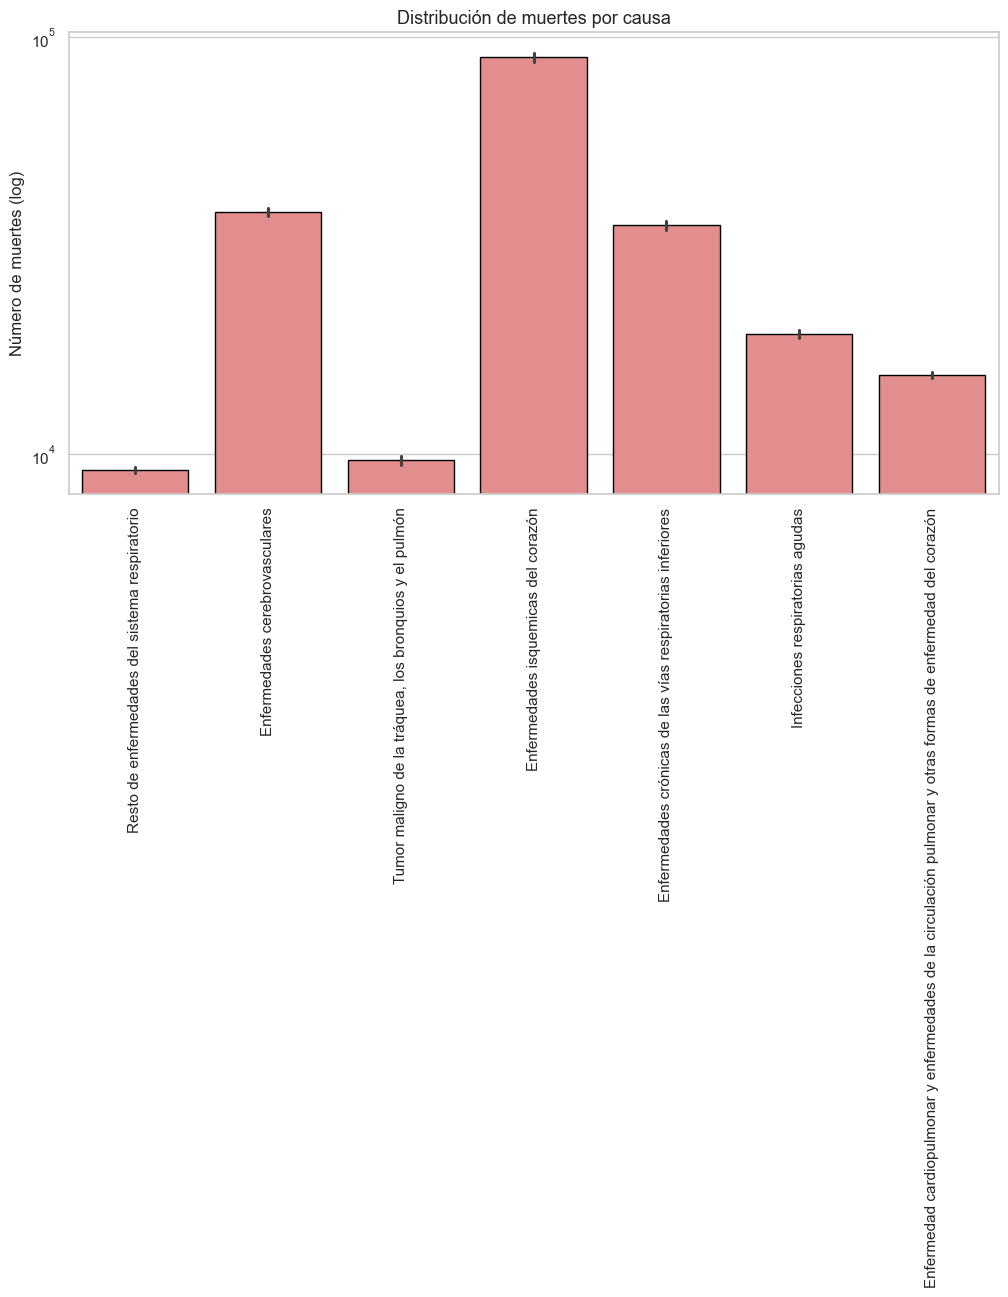

In [17]:
sns.set(style="whitegrid", palette="rocket")

plt.figure(figsize=(12, 6))
sns.barplot(
    data=datos_filtrados,
    x='CAUSAS_667',
    y='TOTAL_CASOS',
    estimator=sum,
    color='lightcoral',
    edgecolor='k'
)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Número de muertes (log)', fontsize=12)
plt.yscale('log')
plt.xlabel(None)
plt.title('Distribución de muertes por causa', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# Calcular el conteo y porcentaje por causa de muerte
conteo = datos_filtrados['MORTALIDAD_DESCRIPCION'].value_counts()
porcentaje = (conteo / len(datos_filtrados)) * 100

# Convertir a DataFrame
tabla_resultado = pd.DataFrame({
    'Causa de Muerte': conteo.index,
    'Conteo': conteo.values,
    'Porcentaje (%)': porcentaje.round(2).values
})

orden_mapeo = {
    'ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICA, NO ESPECIFICADA': 'COPD',
    'ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICA CON INFECCION AGUDA DE LAS VIAS RESPIRATORIAS INFERIORES': 'ALRI',
    'ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICA CON EXACERBACION AGUDA, NO ESPECIFICADA': 'COPD-AE',
    'ENFERMEDAD CEREBROVASCULAR, NO ESPECIFICADA': 'CVD',
    'OTRAS ENFERMEDADES PULMONARES OBSTRUCTIVAS CRONICAS ESPECIFICADAS': 'Other pulmonary diseases',
    'CARDIOMIOPATIA ISQUEMICA': 'Ischemic Cardiomyopathy',
    'INFECCION AGUDA NO ESPECIFICADA DE LAS VIAS RESPIRATORIAS INFERIORES': 'Unspecified Acute Respiratory Infection',
    'CARCINOMA IN SITU DEL BRONQUIO Y DEL PULMON': 'Bronchus and Lung Carcinoma',
    'Infecciones respiratorias, clasificadas en otra parte': 'Other infections'
}

tabla_resultado['Etiqueta'] = tabla_resultado['Causa de Muerte'].map(orden_mapeo)
tabla_resultado = tabla_resultado.set_index('Etiqueta').reindex(custom_labels).reset_index()
tabla_resultado = tabla_resultado.rename(columns={'index': 'Causa de Muerte'})

# Llenar valores NaN con ceros si faltan categorías
tabla_resultado = tabla_resultado.fillna({'Conteo': 0, 'Porcentaje (%)': 0})
# Exportar la tabla a un archivo Excel
tabla_resultado.to_excel("tabla_mortalidad_codigos.xlsx", index=False)

# Mostrar la tabla
print(tabla_resultado)


KeyError: 'MORTALIDAD_DESCRIPCION'

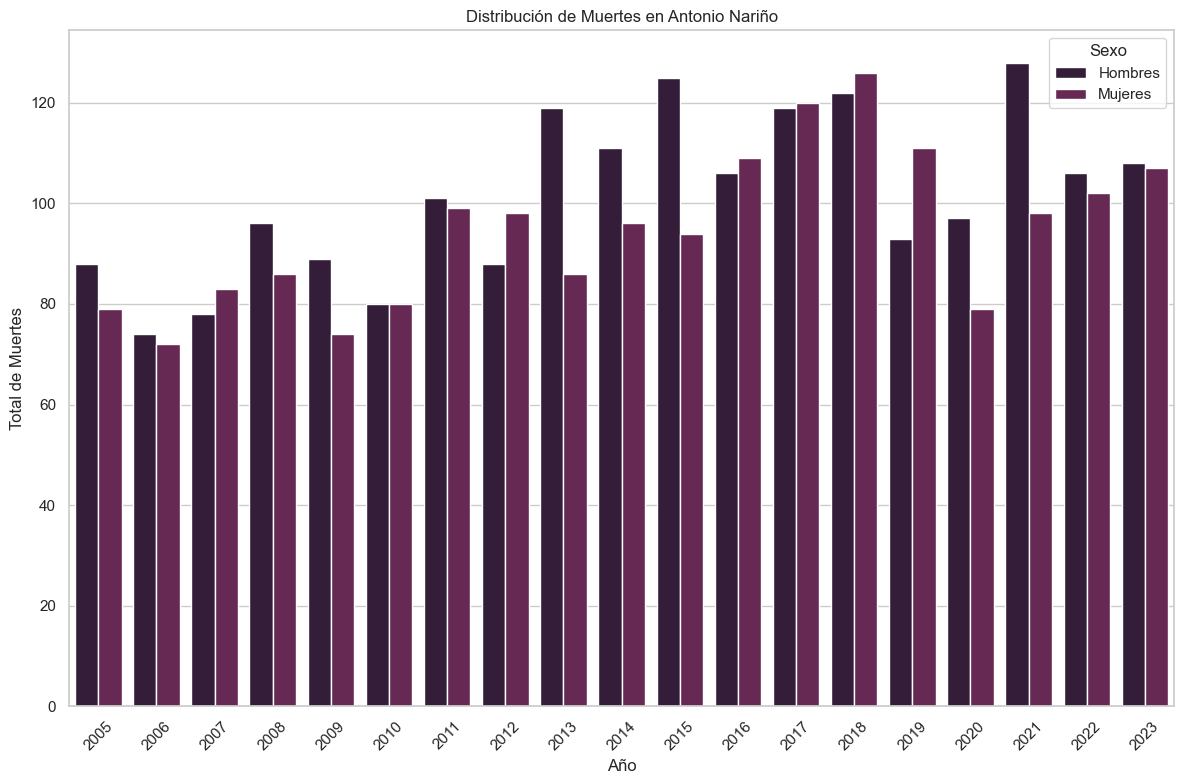

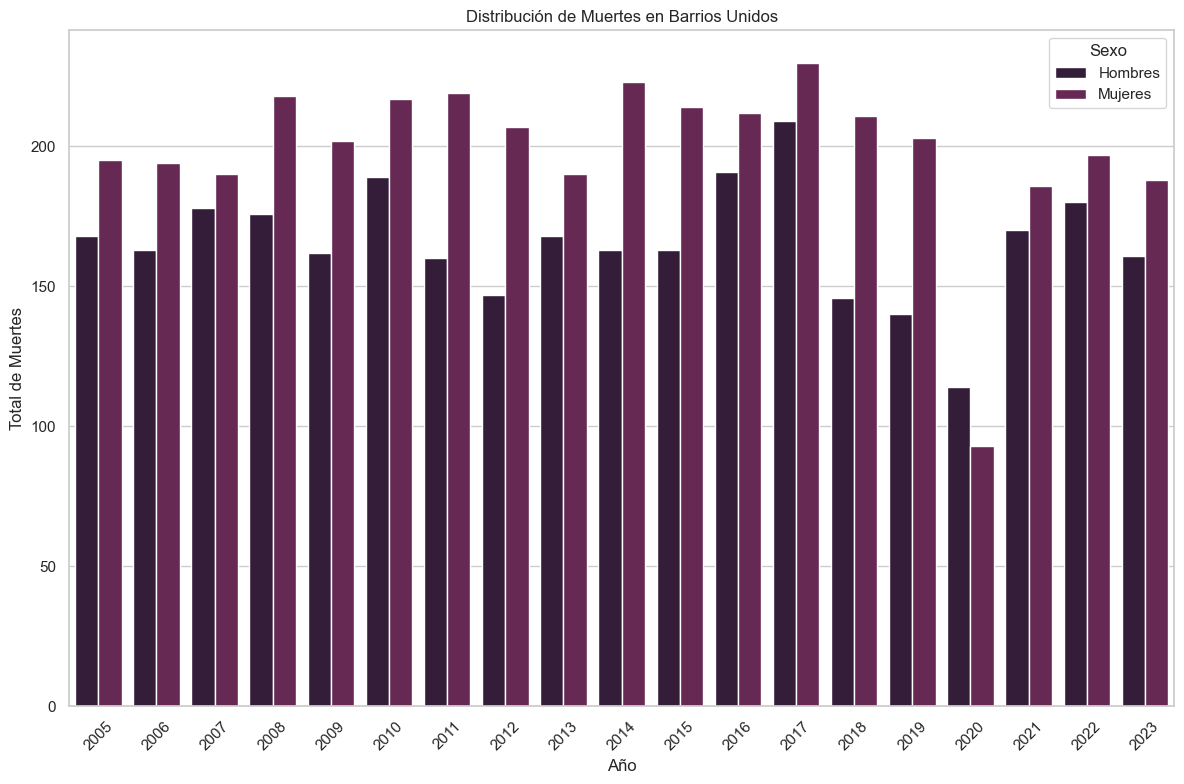

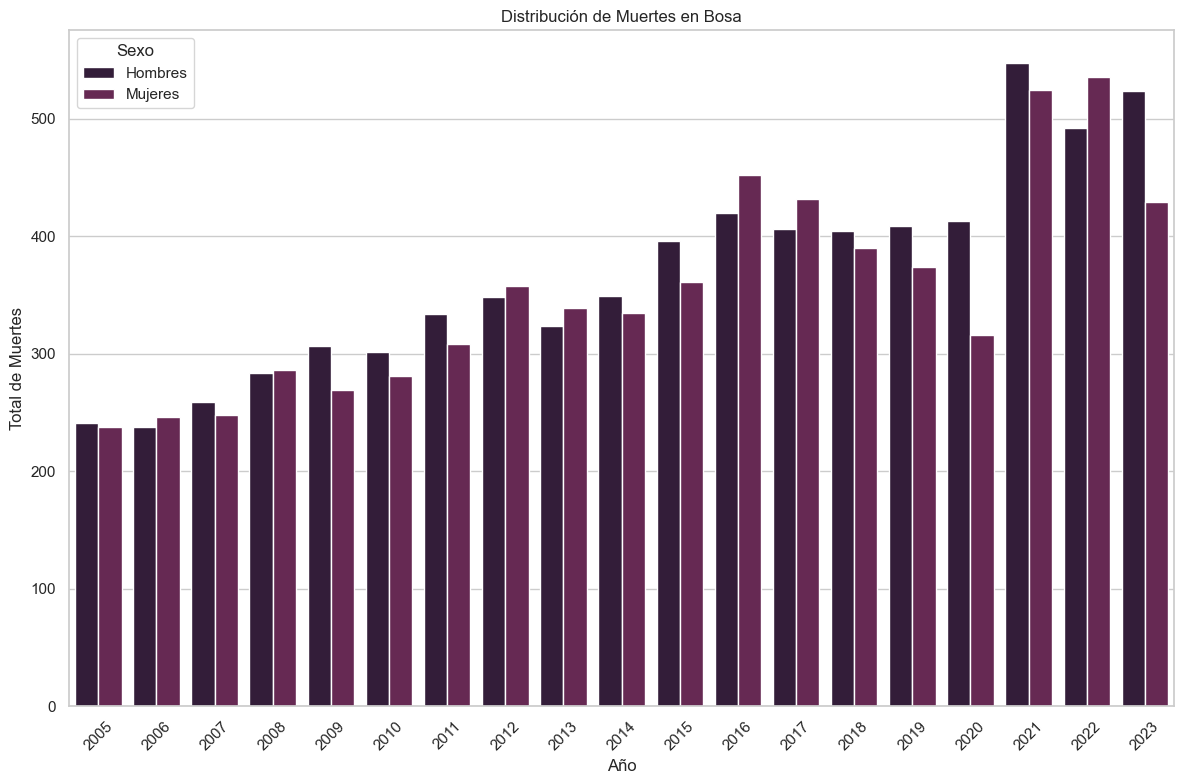

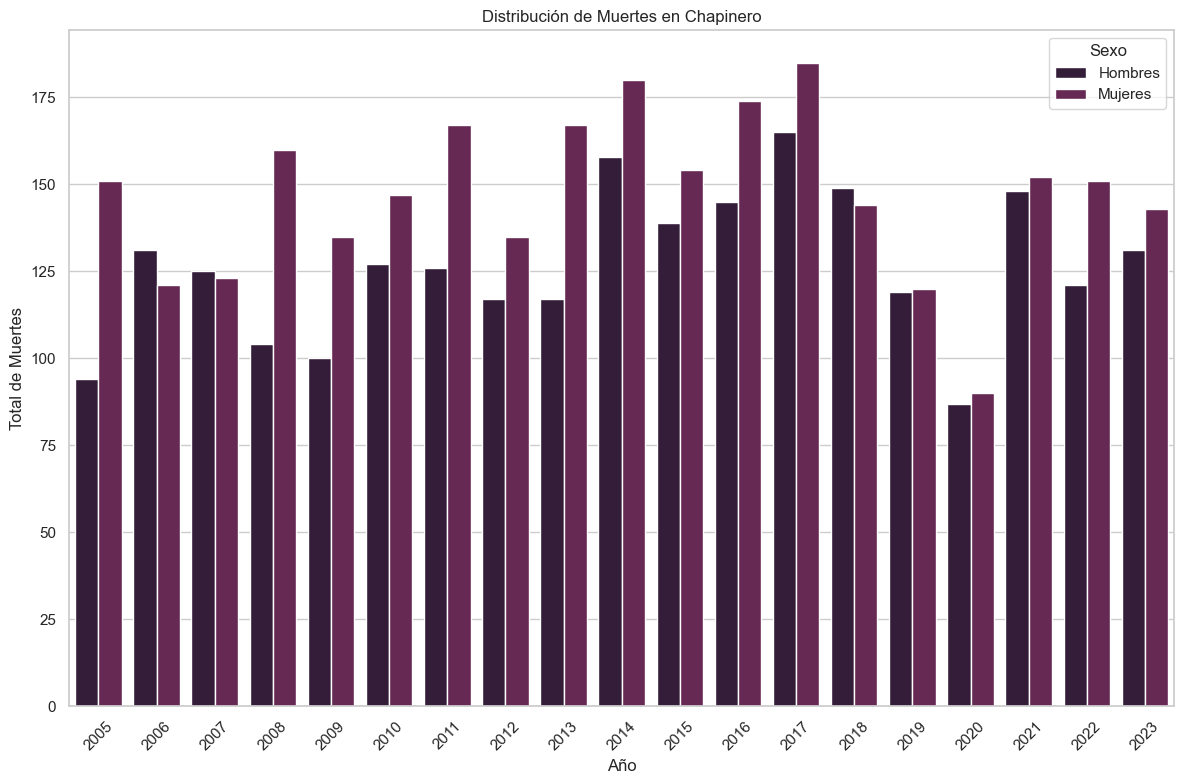

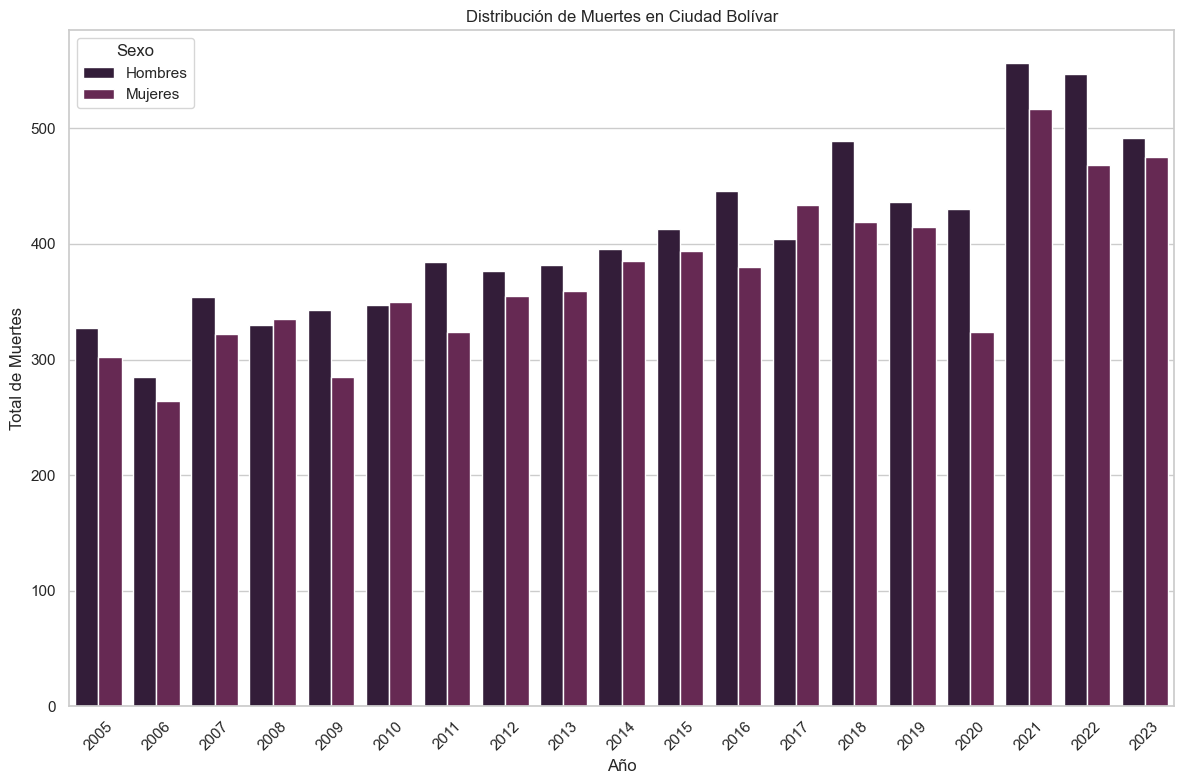

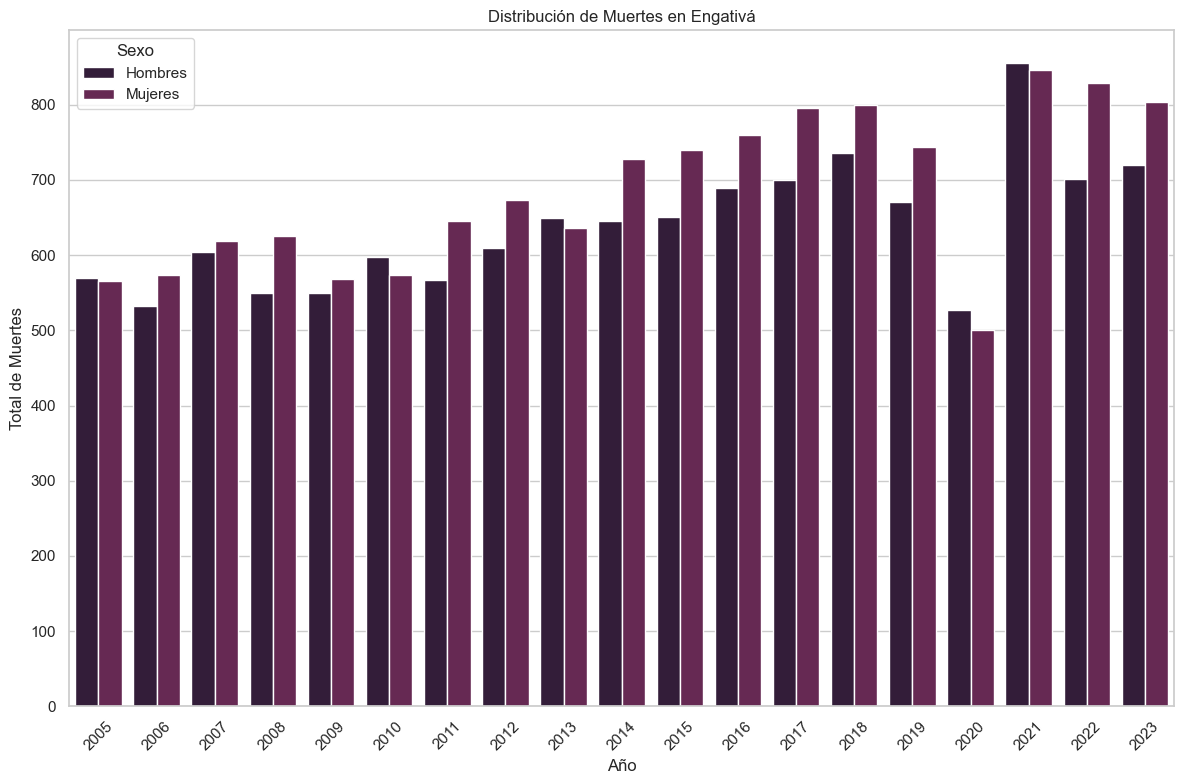

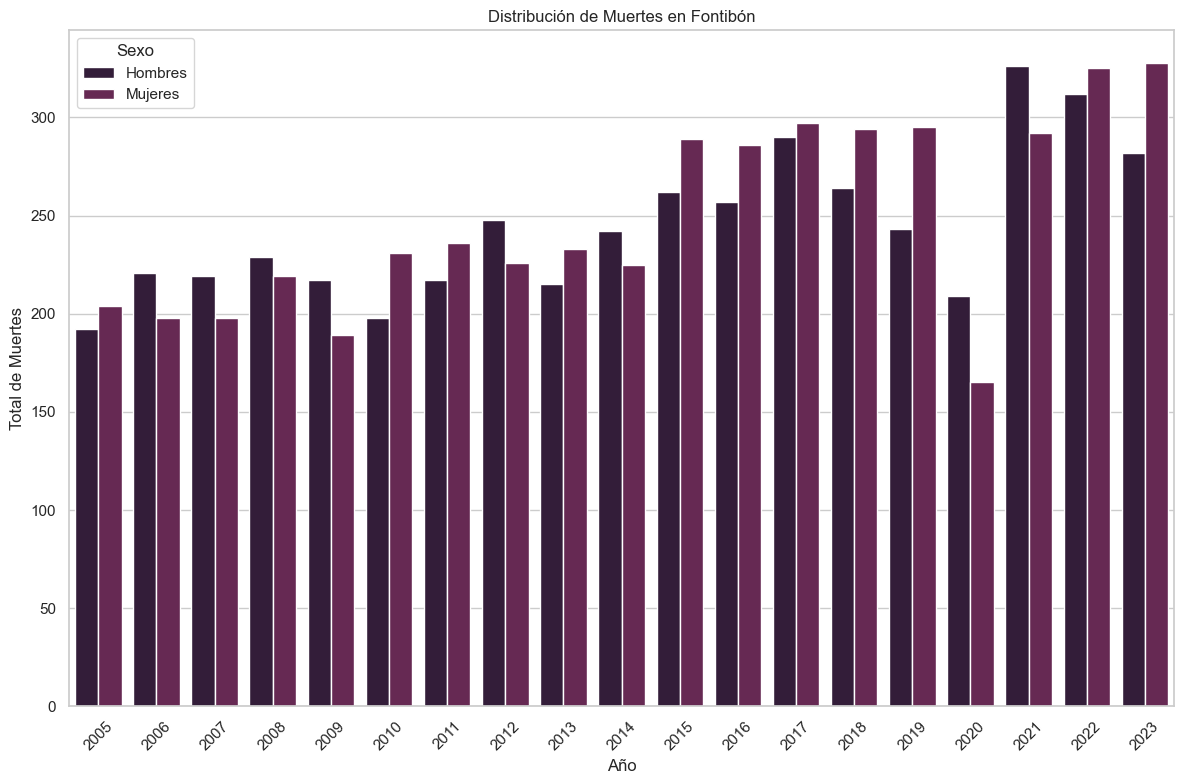

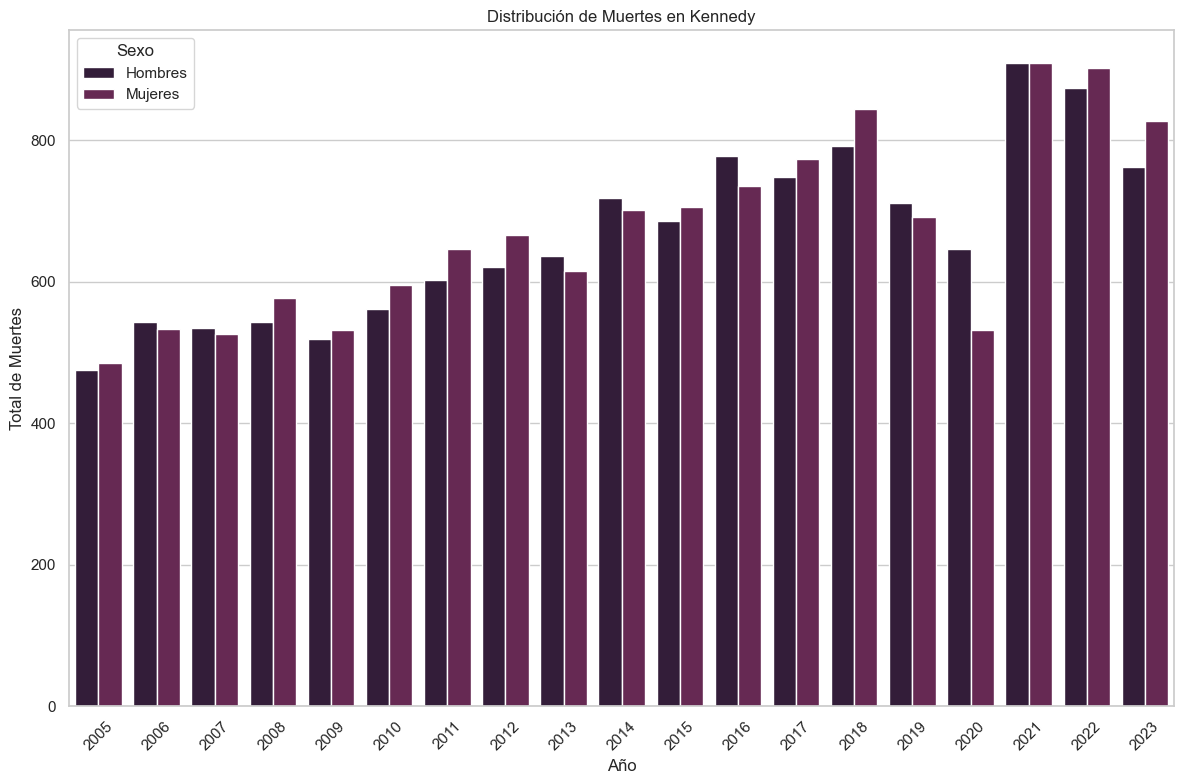

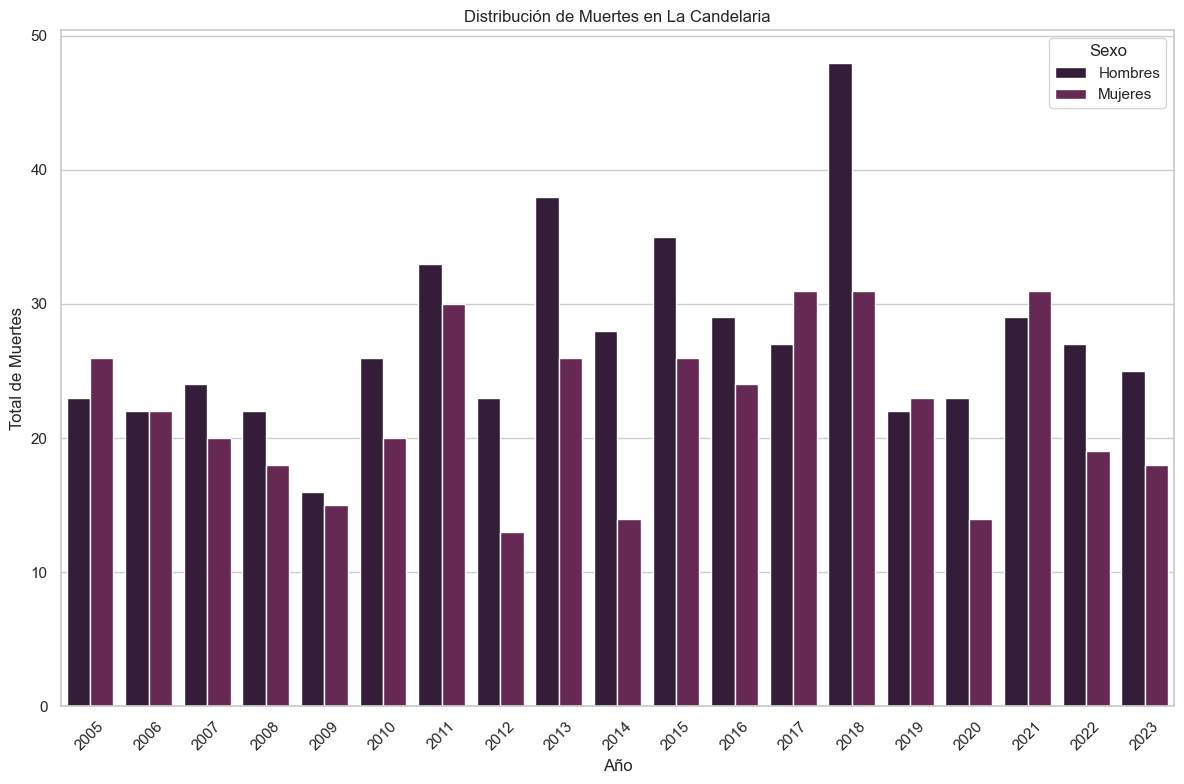

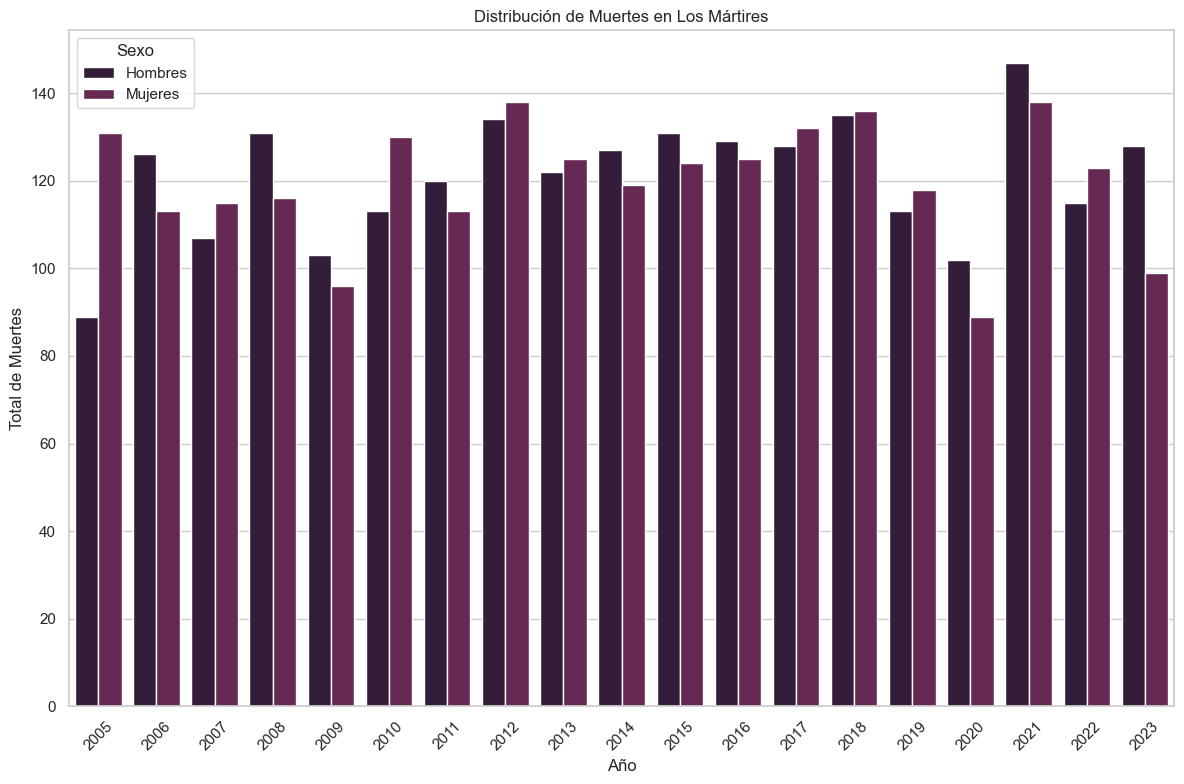

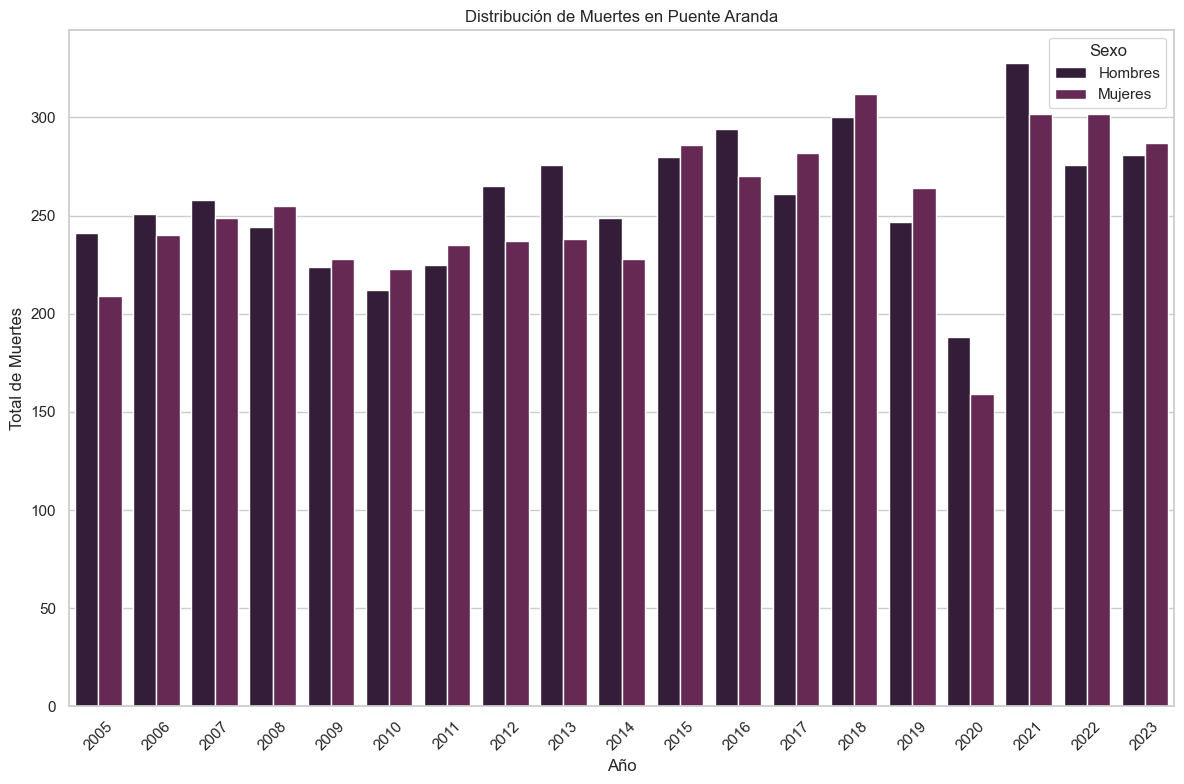

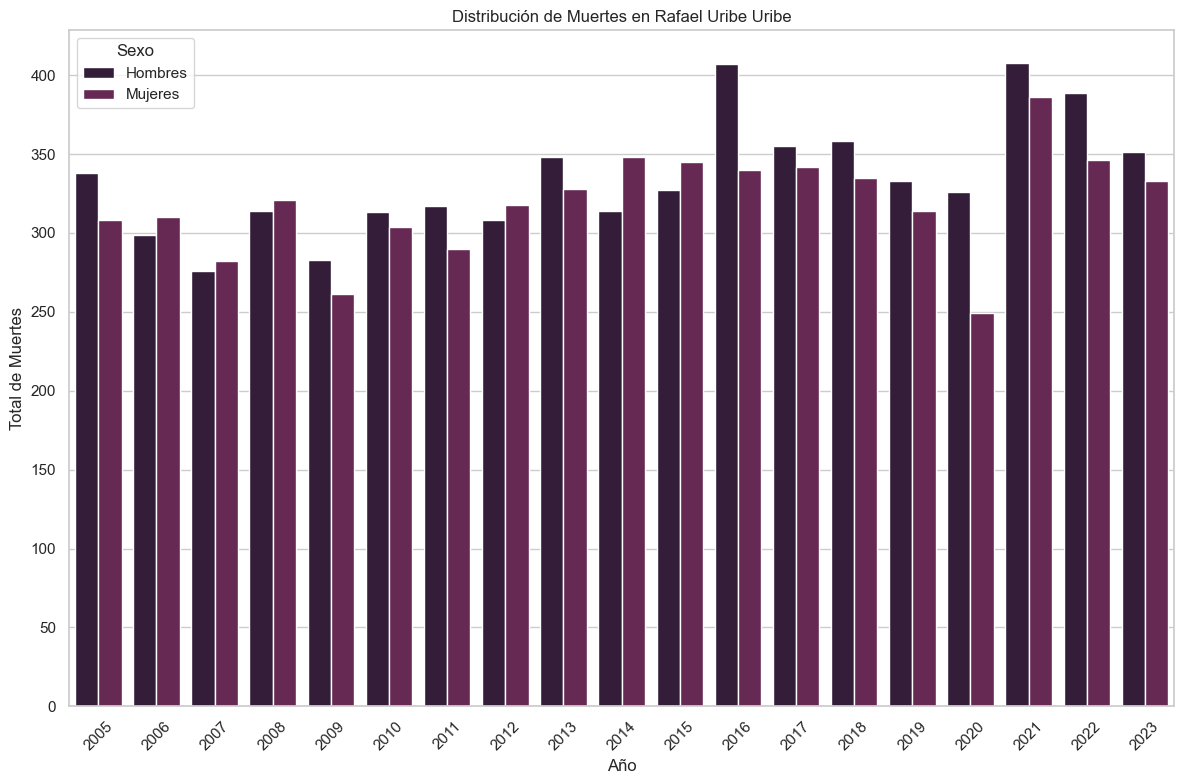

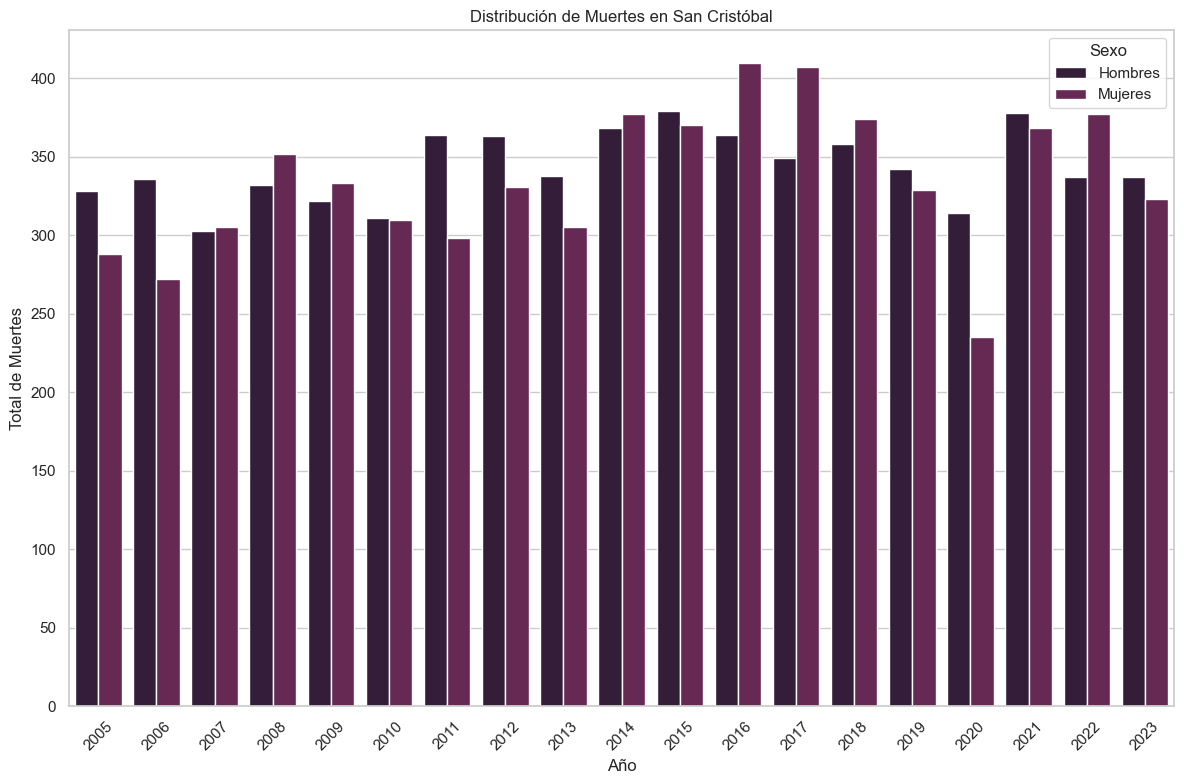

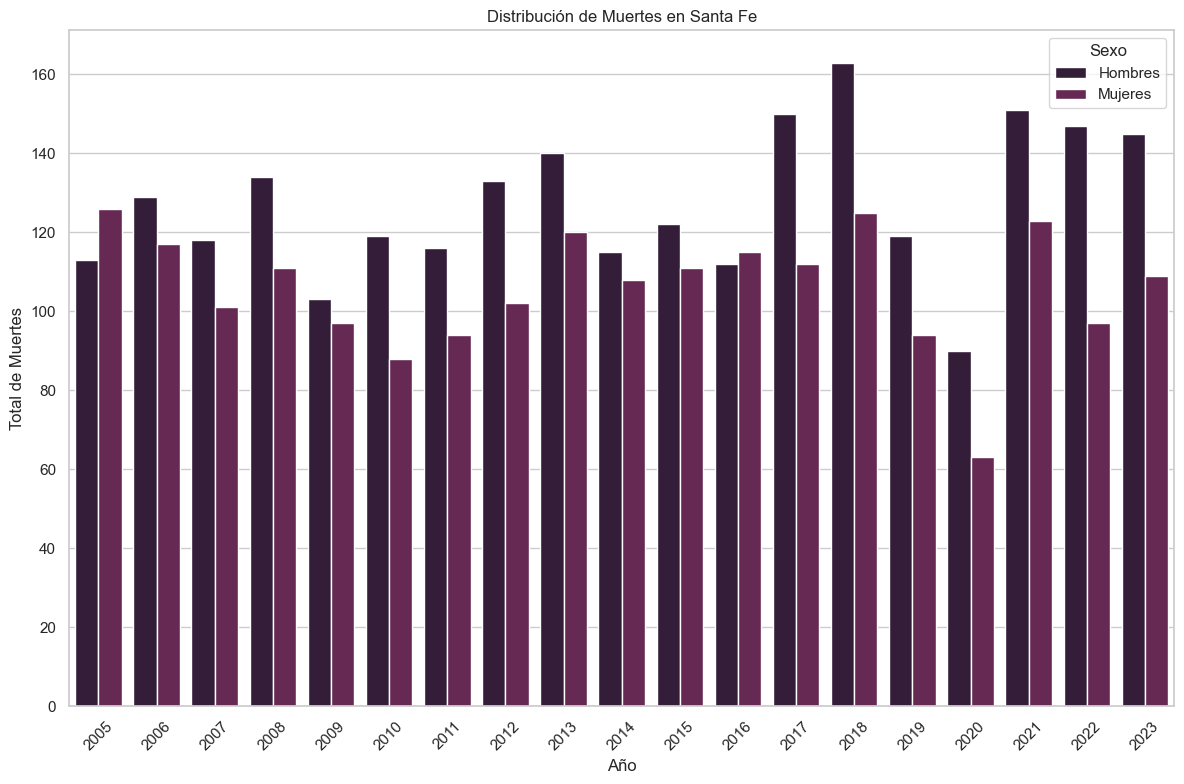

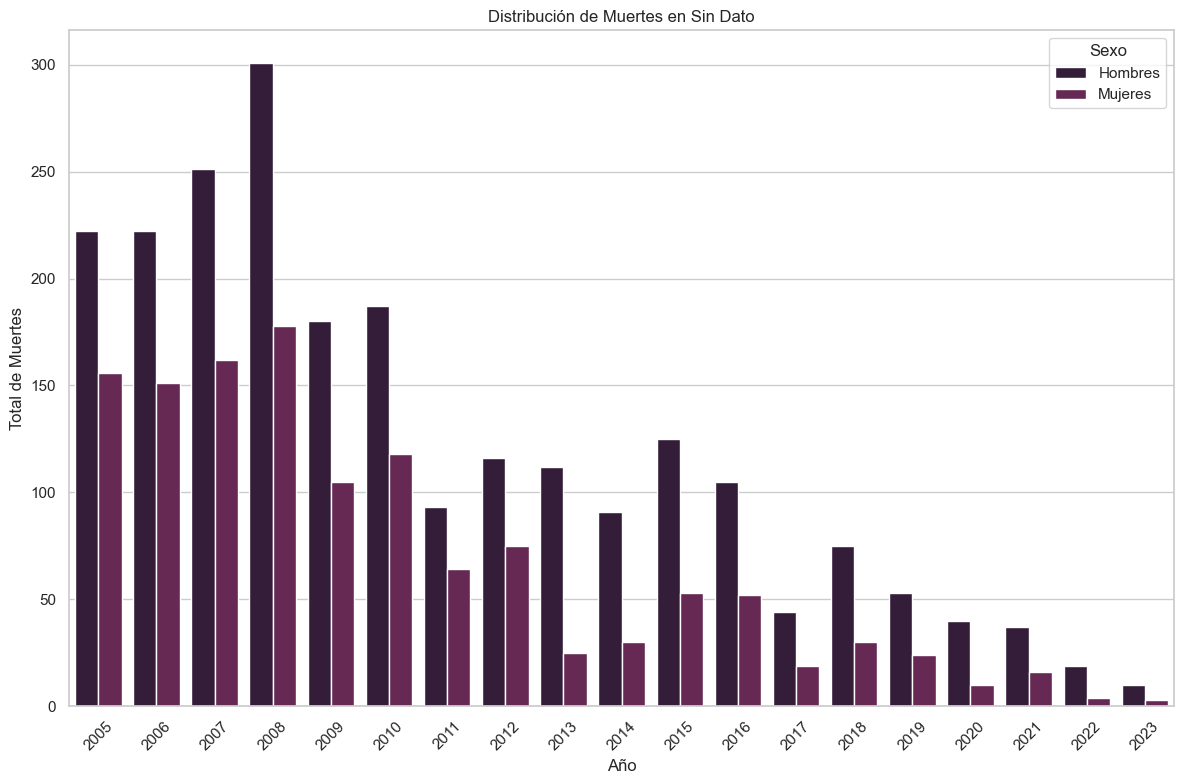

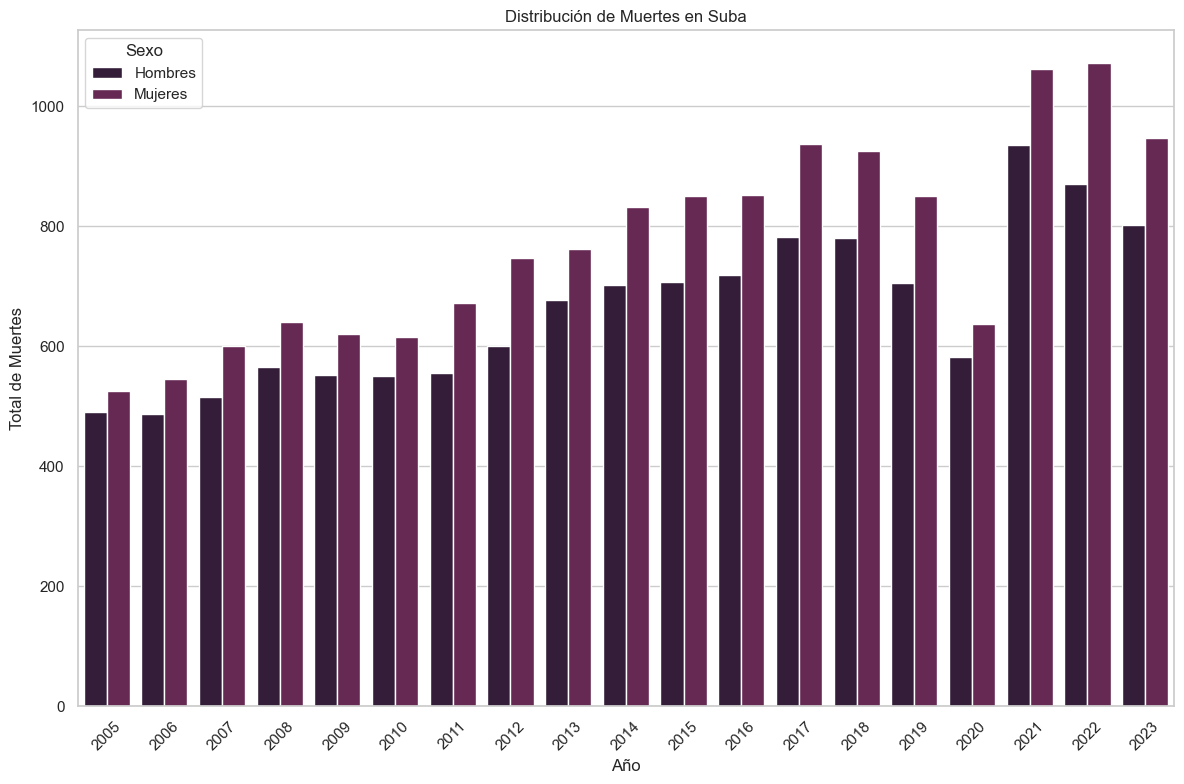

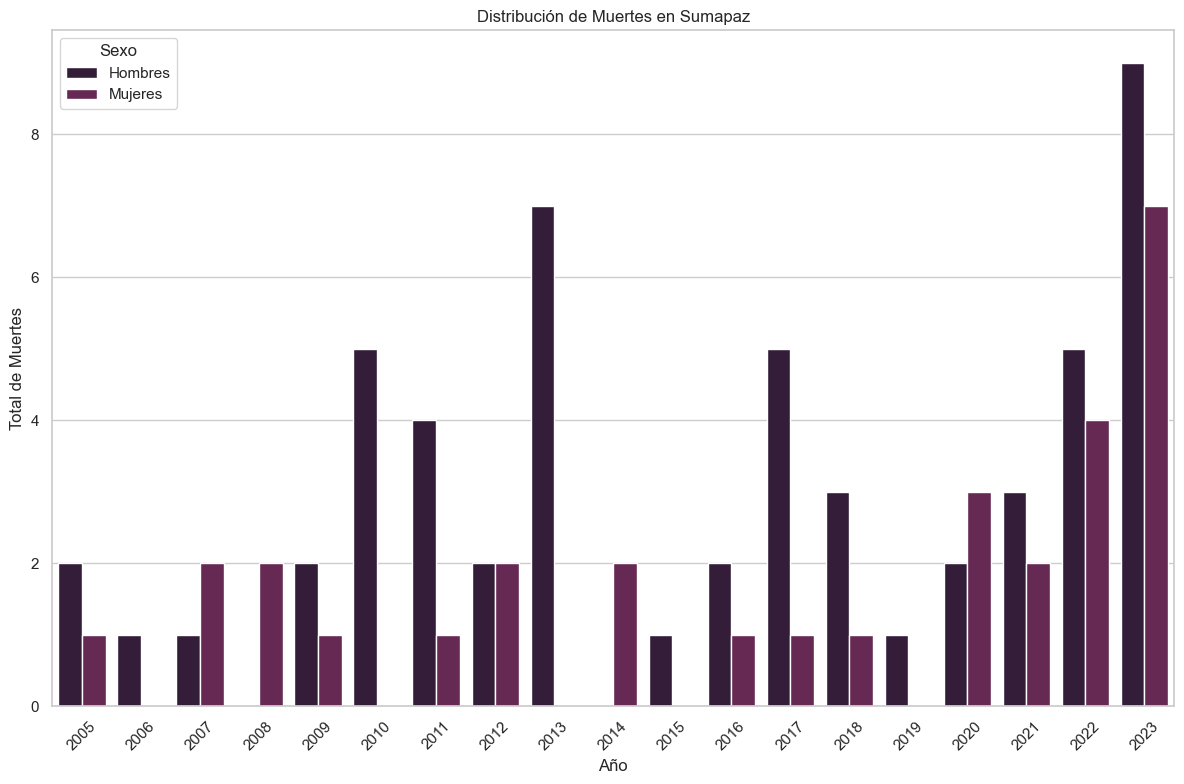

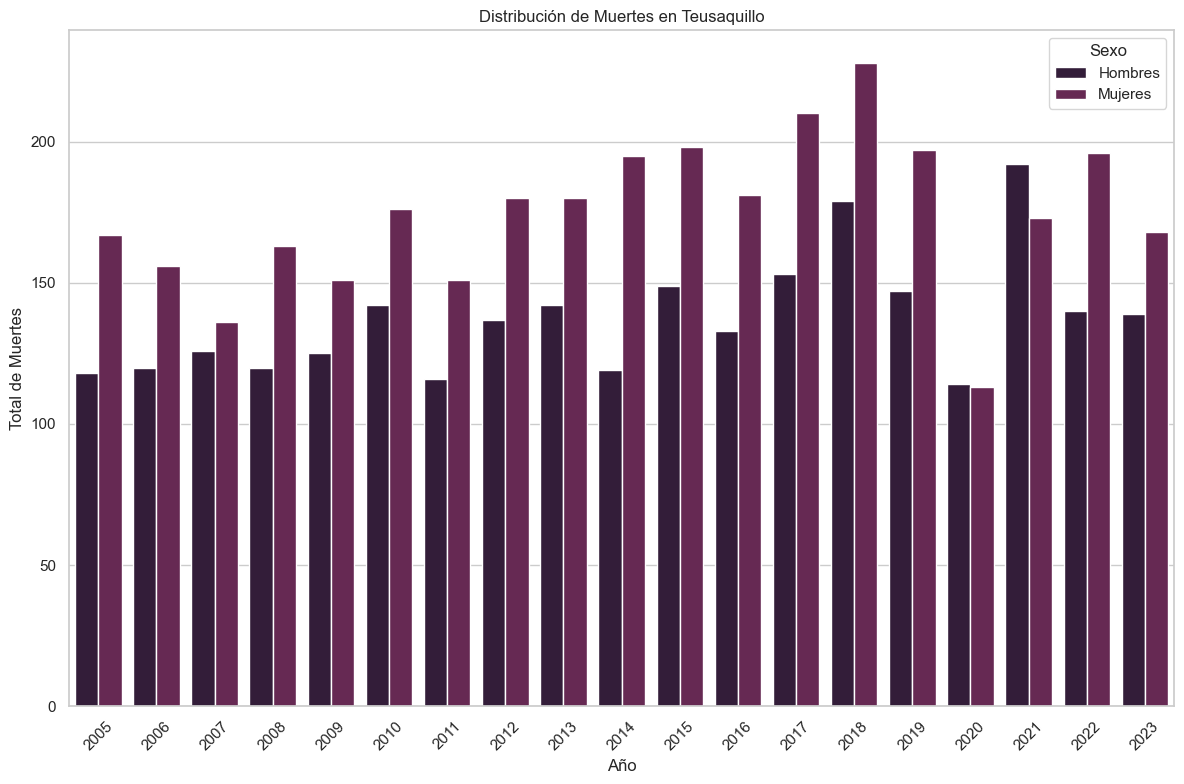

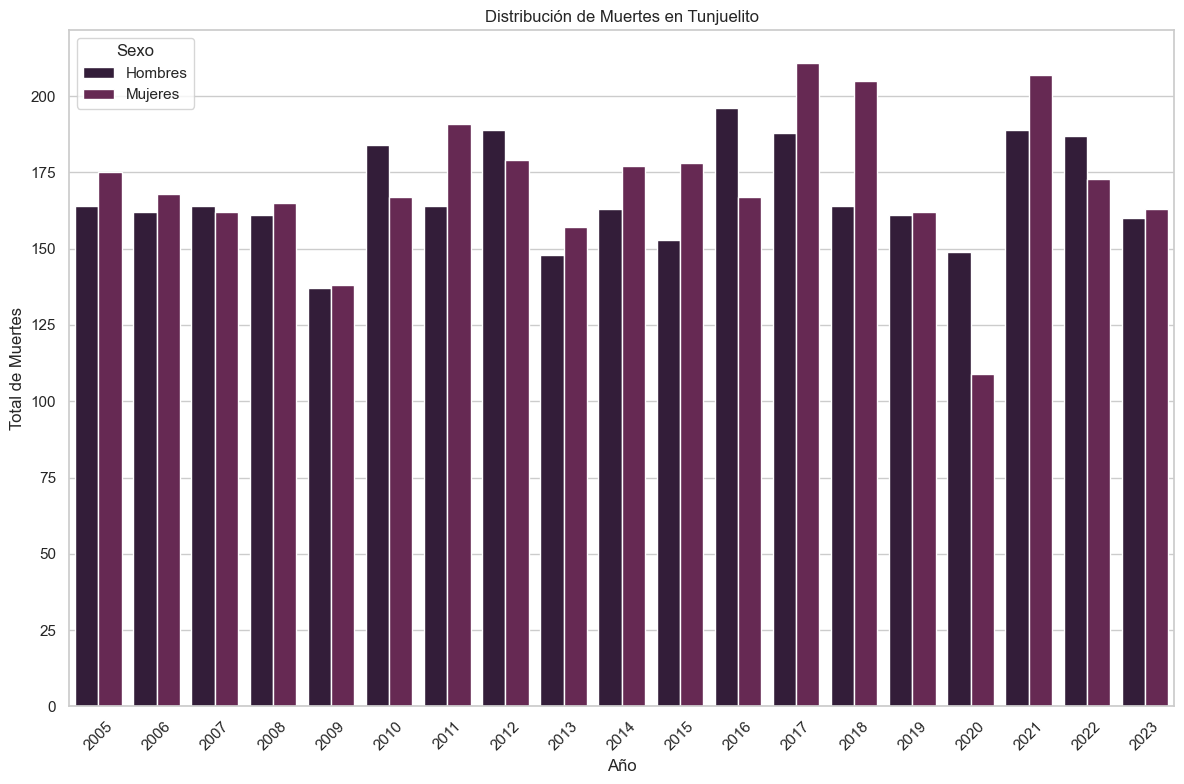

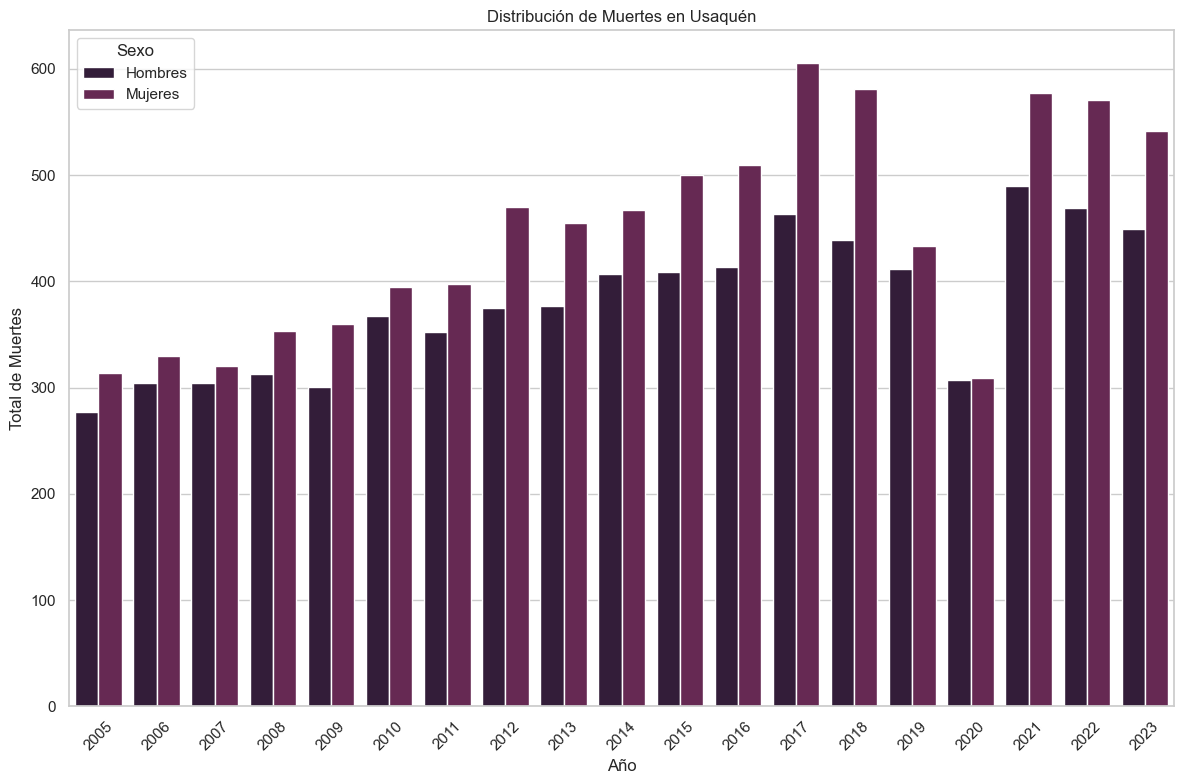

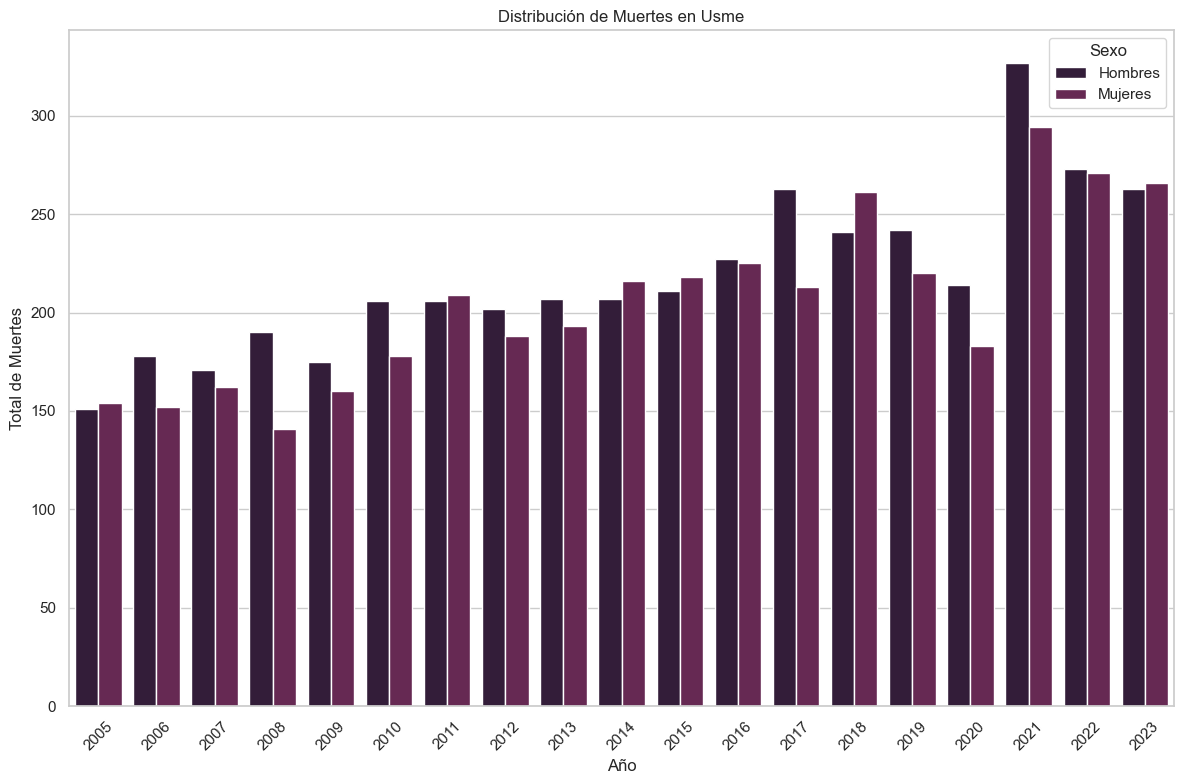

In [20]:
# Obtener una lista de localidades únicas
localidades_unicas = datos_filtrados['LOCALIDAD'].unique()


for localidad in localidades_unicas:
    # Filtrar por localidad
    datos_localidad = datos_filtrados[datos_filtrados['LOCALIDAD'] == localidad]

    # Agrupar por año y sexo, sumando el total de casos
    resumen = datos_localidad.groupby(['ANO', 'SEXO'], as_index=False)['TOTAL_CASOS'].sum()

    # Crear gráfico
    plt.figure(figsize=(12, 8))
    sns.barplot(data=resumen, x='ANO', y='TOTAL_CASOS', hue='SEXO')

    # Personalizar
    plt.title(f'Distribución de Muertes en {localidad}')
    plt.xlabel('Año')
    plt.ylabel('Total de Muertes')
    plt.legend(title='Sexo')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [21]:
datos_filtrados

,ANO,LOCALIDAD,SEXO,EDAD_QUINQUENAL,CAUSAS_667,CAUSAS_105,TOTAL_CASOS
5,2005,Antonio Nariño,Hombres,0 a 4,Resto de enfermedades del sistema respiratorio,Enfermedades del pulmón debida a agentes externos,1
8,2005,Antonio Nariño,Hombres,10 a 14,Resto de enfermedades del sistema respiratorio,Todas las demás enfermedades del sistema respi...,1
17,2005,Antonio Nariño,Hombres,25 a 29,Resto de enfermedades del sistema respiratorio,Todas las demás enfermedades del sistema respi...,1
25,2005,Antonio Nariño,Hombres,30 a 34,Resto de enfermedades del sistema respiratorio,Todas las demás enfermedades del sistema respi...,1
31,2005,Antonio Nariño,Hombres,40 a 44,Enfermedades cerebrovasculares,Enfermedades cerebrovasculares,1
...,...,...,...,...,...,...,...
245683,2023,Usme,Mujeres,90 a 94,Enfermedades crónicas de las vías respiratoria...,Enfermedades crónicas de las vías respiratorias,12
245685,2023,Usme,Mujeres,90 a 94,Enfermedades cerebrovasculares,Enfermedades cerebrovasculares,5
245691,2023,Usme,Mujeres,90 a 94,Enfermedad cardiopulmonar y enfermedades de la...,Todas las demás formas de enfermedad del corazón,1
245699,2023,Usme,Mujeres,95 a 99,Enfermedades crónicas de las vías respiratoria...,Enfermedades crónicas de las vías respiratorias,3


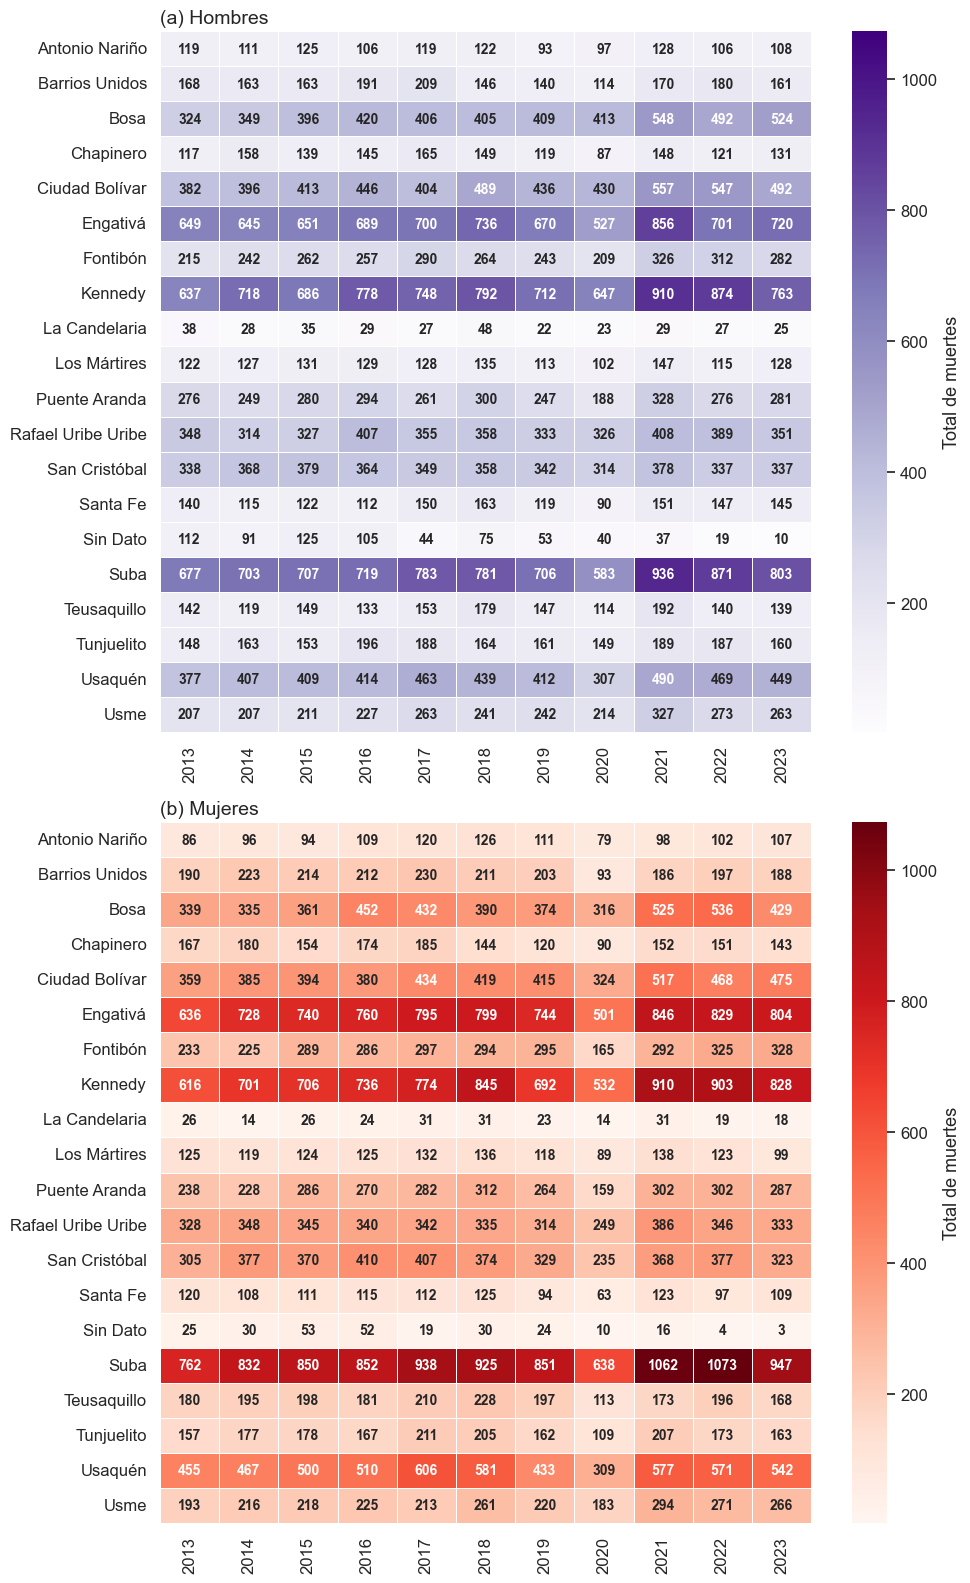

In [32]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

datos_filtrados = datos_filtrados[datos_filtrados["ANO"].between(2013, 2023)]

# Crear tablas dinámicas (pivot) sumando TOTAL_CASOS
heatmap_data_male = datos_filtrados[datos_filtrados['SEXO'] == 'Hombres'].pivot_table(
    index='LOCALIDAD', columns='ANO', values='TOTAL_CASOS', aggfunc='sum'
)

heatmap_data_female = datos_filtrados[datos_filtrados['SEXO'] == 'Mujeres'].pivot_table(
    index='LOCALIDAD', columns='ANO', values='TOTAL_CASOS', aggfunc='sum'
)

# Eliminar filas no deseadas
for df in [heatmap_data_male, heatmap_data_female]:
    df.drop(index=["Sin información", "Sumapaz"], errors="ignore", inplace=True)

# Escala común para ambos mapas
vmin = min(heatmap_data_male.min().min(), heatmap_data_female.min().min())
vmax = max(heatmap_data_male.max().max(), heatmap_data_female.max().max())

# Crear figura con dos subgráficos
fig = plt.figure(figsize=(10, 16))
gs = gridspec.GridSpec(2, 1)

# (a) MASCULINO
ax1 = fig.add_subplot(gs[0])
sns.heatmap(
    heatmap_data_male, cmap="Purples", annot=True, fmt=".0f", linewidths=0.5,
    edgecolor="black", annot_kws={"size": 10, "weight": "bold"},
    mask=heatmap_data_male.isnull(), yticklabels=1, xticklabels=1,
    square=False, ax=ax1, vmin=vmin, vmax=vmax
)
ax1.set_title("(a) Hombres", loc="left", fontsize=14)
ax1.set_ylabel("")
ax1.tick_params(axis="both", labelsize=12)
plt.xticks(rotation=90)

# Barra de color hombres
cbar1 = ax1.collections[0].colorbar
cbar1.set_label("Total de muertes", fontsize=13)
cbar1.ax.tick_params(labelsize=12)
plt.xlabel("")

# (b) FEMENINO
ax2 = fig.add_subplot(gs[1])
sns.heatmap(
    heatmap_data_female, cmap="Reds", annot=True, fmt=".0f", linewidths=0.5,
    edgecolor="black", annot_kws={"size": 10, "weight": "bold"},
    mask=heatmap_data_female.isnull(), yticklabels=1, xticklabels=1,
    square=False, ax=ax2, vmin=vmin, vmax=vmax
)
ax2.set_title("(b) Mujeres", loc="left", fontsize=14)
ax2.set_ylabel("")
ax2.tick_params(axis="both", labelsize=12)
plt.xticks(rotation=90)

# Barra de color mujeres
cbar2 = ax2.collections[0].colorbar
cbar2.set_label("Total de muertes", fontsize=13)
cbar2.ax.tick_params(labelsize=12)
plt.xlabel("")

plt.tight_layout()
plt.show()

In [60]:
poblacion_hombres

,ANO,Cod_Loc,LOCALIDAD,Sexo,Edad,Grupo_Edad,Población
0,2005,1,Usaquén,Hombres,0,00 a 04,2909
1,2005,1,Usaquén,Hombres,1,00 a 04,2954
2,2005,1,Usaquén,Hombres,2,00 a 04,2919
3,2005,1,Usaquén,Hombres,3,00 a 04,2989
4,2005,1,Usaquén,Hombres,4,00 a 04,3079
...,...,...,...,...,...,...,...
131396,2035,0,Bogotá,Hombres,96,95 a 99,510
131397,2035,0,Bogotá,Hombres,97,95 a 99,371
131398,2035,0,Bogotá,Hombres,98,95 a 99,268
131399,2035,0,Bogotá,Hombres,99,95 a 99,192


In [74]:
datos_filtrados

,ANO,LOCALIDAD,SEXO,EDAD_QUINQUENAL,CAUSAS_667,CAUSAS_105,TOTAL_CASOS
100714,2013,Antonio Nariño,Hombres,100 o más,Enfermedades crónicas de las vías respiratoria...,Enfermedades crónicas de las vías respiratorias,1
100718,2013,Antonio Nariño,Hombres,20 a 24,Infecciones respiratorias agudas,Neumonía,1
100734,2013,Antonio Nariño,Hombres,40 a 44,Enfermedades isquemicas del corazón,Enfermedades isquemicas del corazón,1
100739,2013,Antonio Nariño,Hombres,45 a 49,Enfermedades isquemicas del corazón,Enfermedades isquemicas del corazón,1
100740,2013,Antonio Nariño,Hombres,45 a 49,Enfermedades crónicas de las vías respiratoria...,Enfermedades crónicas de las vías respiratorias,1
...,...,...,...,...,...,...,...
245683,2023,Usme,Mujeres,90 a 94,Enfermedades crónicas de las vías respiratoria...,Enfermedades crónicas de las vías respiratorias,12
245685,2023,Usme,Mujeres,90 a 94,Enfermedades cerebrovasculares,Enfermedades cerebrovasculares,5
245691,2023,Usme,Mujeres,90 a 94,Enfermedad cardiopulmonar y enfermedades de la...,Todas las demás formas de enfermedad del corazón,1
245699,2023,Usme,Mujeres,95 a 99,Enfermedades crónicas de las vías respiratoria...,Enfermedades crónicas de las vías respiratorias,3


In [62]:
# NORMALIZACION DE DATOS: 100.000
data_poblacional = data_poblacional.rename(columns={
    'Año': 'ANO',
    'Localidad': 'LOCALIDAD'
})

# Agrupar muertes por sexo, localidad y año
conteo_m = datos_filtrados[datos_filtrados['SEXO'] == 'Hombres'] \
    .groupby(['LOCALIDAD', 'ANO']).size().reset_index(name='MUERTES')

conteo_f = datos_filtrados[datos_filtrados['SEXO'] == 'Mujeres'] \
    .groupby(['LOCALIDAD', 'ANO']).size().reset_index(name='MUERTES')

# Filtrar población por sexo
# Filtrar población por sexo
tmp_h = data_poblacional[data_poblacional['Sexo'] == 'Hombres']
poblacion_hombres = tmp_h.groupby(['ANO', 'Cod_Loc', 'LOCALIDAD'])['Población'].sum().reset_index()

tmp_m = data_poblacional[data_poblacional['Sexo'] == 'Mujeres']
poblacion_mujeres = tmp_m.groupby(['ANO', 'Cod_Loc', 'LOCALIDAD'])['Población'].sum().reset_index()

# Merge de muertes con población
merged_m = pd.merge(conteo_m, poblacion_hombres, on=['LOCALIDAD', 'ANO'], how='left')
merged_f = pd.merge(conteo_f, poblacion_mujeres, on=['LOCALIDAD', 'ANO'], how='left')

# Calcular tasa por 100,000 habitantes
merged_m['TASA'] = (merged_m['MUERTES'] / merged_m['Población']) * 100000
merged_f['TASA'] = (merged_f['MUERTES'] / merged_f['Población']) * 100000

# Añadir columna sexo para luego unir todo
merged_m['SEXO'] = 'Masculino'
merged_f['SEXO'] = 'Femenino'

# Unir ambos DataFrames
merged_all = pd.concat([merged_m, merged_f], ignore_index=True)

merged_all.loc[merged_all['TASA'] < 0, 'TASA'] = 0

# Mostrar resultados
print(merged_all.head())


        LOCALIDAD   ANO  MUERTES  Cod_Loc  Población        TASA       SEXO
0  Antonio Nariño  2013       48     15.0    40071.0  119.787377  Masculino
1  Antonio Nariño  2014       43     15.0    39232.0  109.604405  Masculino
2  Antonio Nariño  2015       48     15.0    38522.0  124.604122  Masculino
3  Antonio Nariño  2016       47     15.0    37964.0  123.801496  Masculino
4  Antonio Nariño  2017       46     15.0    37579.0  122.408792  Masculino


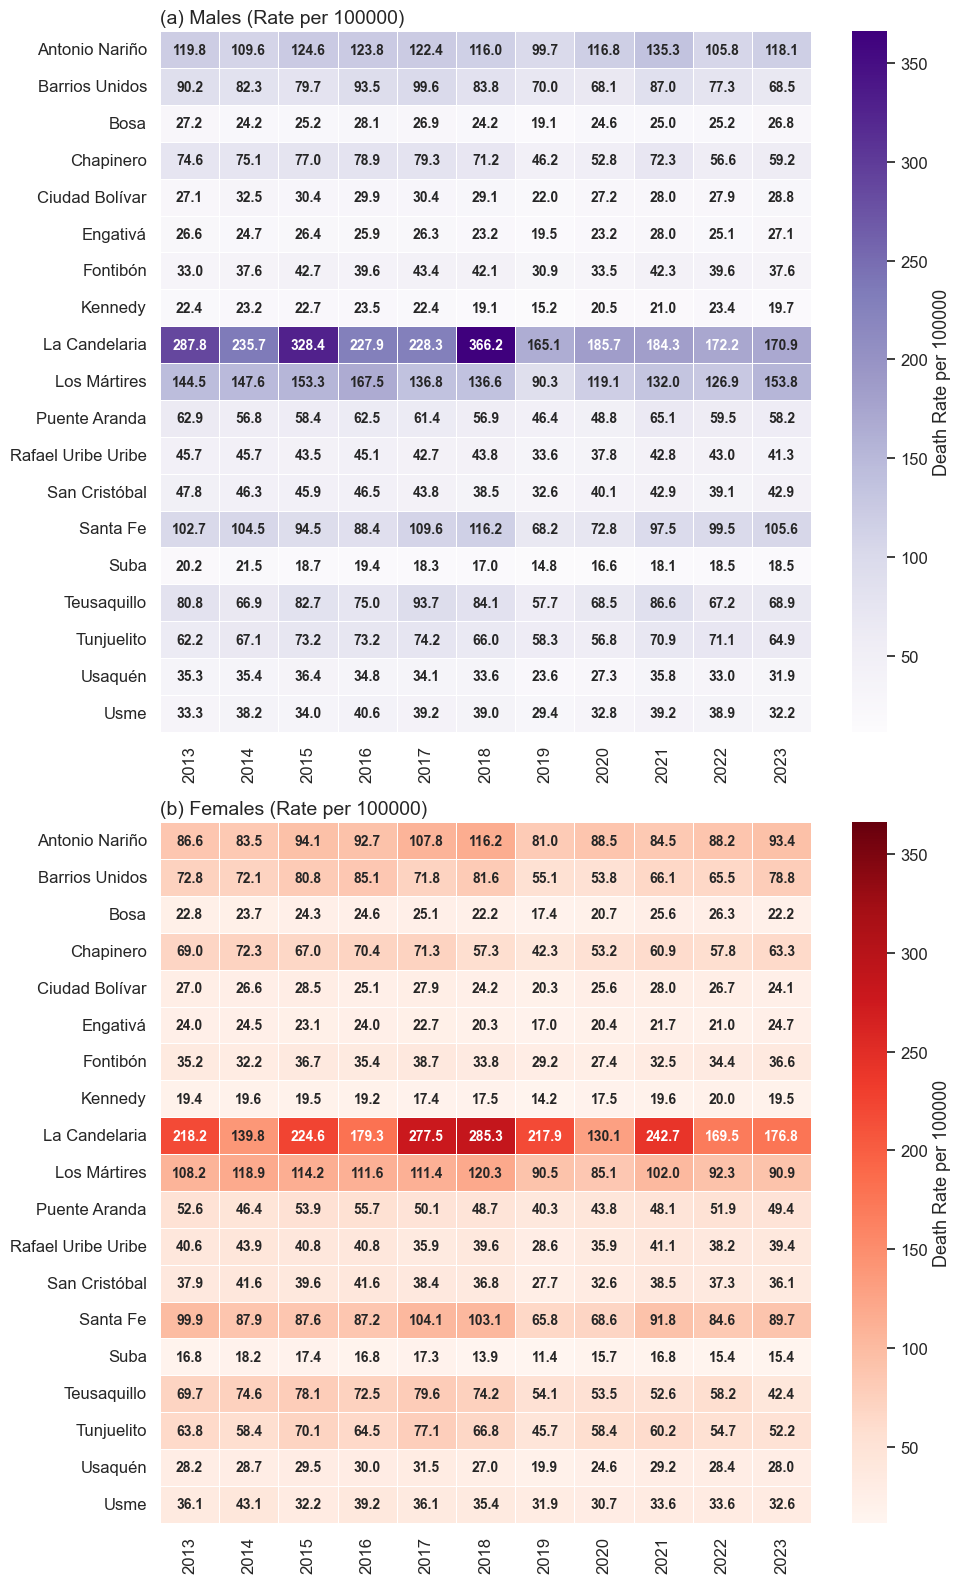

In [88]:
#FILTRO POR GRUPO DE EDAD SUMARLOS

# Crear pivot tables para tasas, separadas por sexo
heatmap_data_male = merged_all[merged_all['SEXO'] == 'Masculino'].pivot_table(
    index='LOCALIDAD', columns='ANO', values='TASA'
)

heatmap_data_female = merged_all[merged_all['SEXO'] == 'Femenino'].pivot_table(
    index='LOCALIDAD', columns='ANO', values='TASA'
)

# Quitar localidades no deseadas
heatmap_data_male = heatmap_data_male.drop(index=["Sin información", "Sumapaz"], errors="ignore")
heatmap_data_female = heatmap_data_female.drop(index=["Sin información", "Sumapaz"], errors="ignore")

# Escala de color consistente entre ambos heatmaps
vmin = min(heatmap_data_male.min().min(), heatmap_data_female.min().min())
vmax = max(heatmap_data_male.max().max(), heatmap_data_female.max().max())

# Crear figura y layout
fig = plt.figure(figsize=(10, 16))
gs = gridspec.GridSpec(2, 1)

# Heatmap para hombres (tasas)
ax1 = fig.add_subplot(gs[0])
sns.heatmap(
    heatmap_data_male, cmap="Purples", annot=True, fmt=".1f", linewidths=0.5,
    edgecolor="black", annot_kws={"size": 10, "weight": "bold"}, mask=heatmap_data_male.isnull(),
    yticklabels=1, xticklabels=1, square=False, ax=ax1, vmin=vmin, vmax=vmax
)
ax1.set_title("(a) Males (Rate per 100000)", loc="left", fontsize=14)
plt.xticks(rotation=90)
ax1.set_ylabel("", fontsize=12)
ax1.tick_params(axis="both", labelsize=12)

cbar1 = ax1.collections[0].colorbar
cbar1.set_label("Death Rate per 100000", fontsize=13)
cbar1.ax.tick_params(labelsize=12)
plt.xlabel("")

# Heatmap para mujeres (tasas)
ax2 = fig.add_subplot(gs[1])
sns.heatmap(
    heatmap_data_female, cmap="Reds", annot=True, fmt=".1f", linewidths=0.5,
    edgecolor="black", annot_kws={"size": 10, "weight": "bold"}, mask=heatmap_data_female.isnull(),
    yticklabels=1, xticklabels=1, square=False, ax=ax2, vmin=vmin, vmax=vmax
)
ax2.set_title("(b) Females (Rate per 100000)", loc="left", fontsize=14)
plt.xticks(rotation=90)
ax2.set_ylabel("")
ax2.tick_params(axis="both", labelsize=12)

cbar2 = ax2.collections[0].colorbar
cbar2.set_label("Death Rate per 100000", fontsize=13)
cbar2.ax.tick_params(labelsize=12)
plt.xlabel("")

plt.tight_layout()
plt.savefig('Figures/Figure_9.pdf', dpi = 300, bbox_inches = 'tight')
plt.savefig('Figures/Figure_9.jpg', dpi = 300, bbox_inches = 'tight')
plt.show()

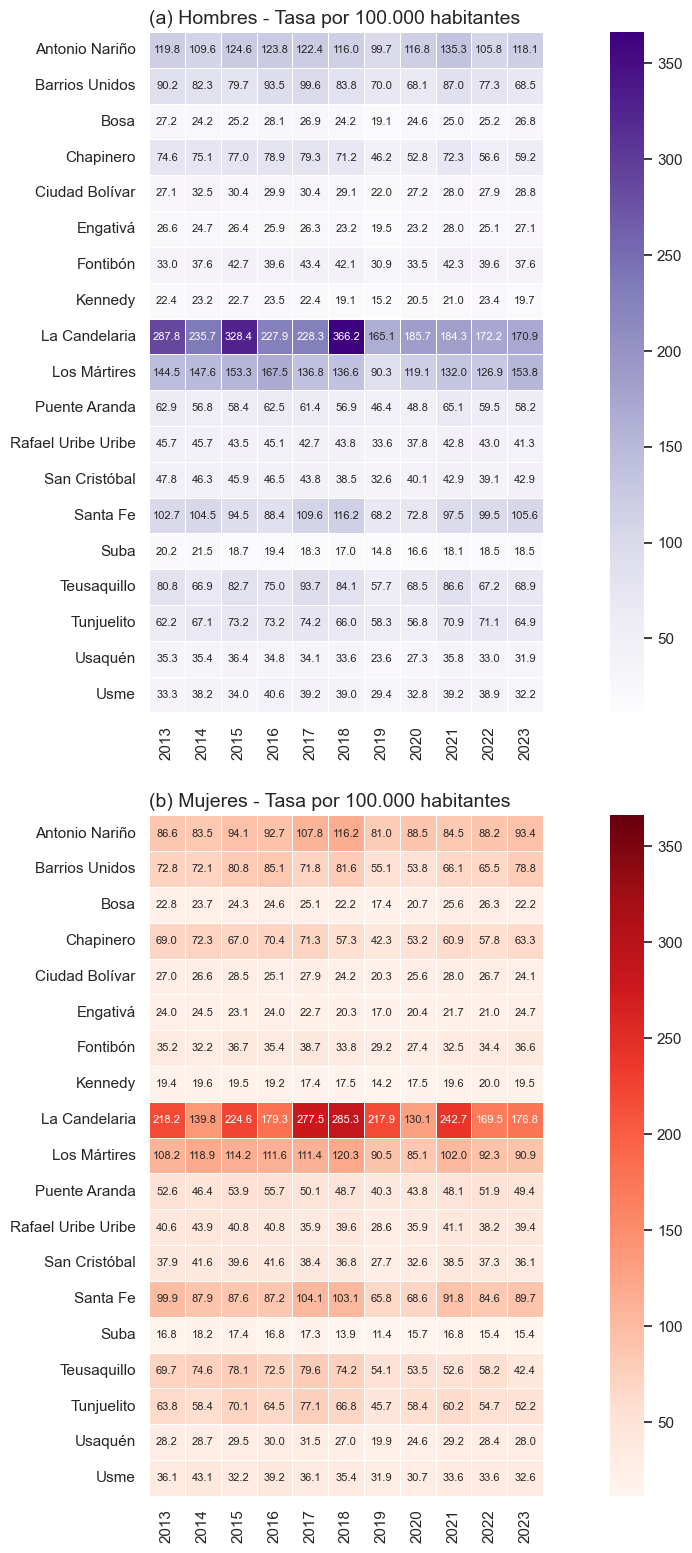

In [66]:
# Asegurarse de que no haya tasas negativas
merged_all.loc[merged_all['TASA'] < 0, 'TASA'] = 0

# Crear tablas dinámicas para el heatmap por sexo
heatmap_data_male = merged_all[merged_all['SEXO'] == 'Masculino'].pivot_table(
    index='LOCALIDAD', columns='ANO', values='TASA'
)

heatmap_data_female = merged_all[merged_all['SEXO'] == 'Femenino'].pivot_table(
    index='LOCALIDAD', columns='ANO', values='TASA'
)

# Eliminar localidades que no se desean mostrar
localidades_excluir = ["Sin información", "Sumapaz"]
heatmap_data_male = heatmap_data_male.drop(index=localidades_excluir, errors="ignore")
heatmap_data_female = heatmap_data_female.drop(index=localidades_excluir, errors="ignore")

# Definir escala de colores común
vmin = min(heatmap_data_male.min().min(), heatmap_data_female.min().min())
vmax = max(heatmap_data_male.max().max(), heatmap_data_female.max().max())

# Crear figura con mayor ancho para mejor visualización
fig = plt.figure(figsize=(14, 16))
gs = gridspec.GridSpec(2, 1)

# Mapa de calor para hombres
ax1 = fig.add_subplot(gs[0])
sns.heatmap(
    heatmap_data_male,
    cmap="Purples", annot=True, fmt=".1f", linewidths=0.5,
    edgecolor="black", annot_kws={"size": 8}, mask=heatmap_data_male.isnull(),
    square=True, cbar=True, ax=ax1, vmin=vmin, vmax=vmax
)
ax1.set_title("(a) Hombres - Tasa por 100.000 habitantes", loc="left", fontsize=14)
ax1.set_ylabel("")
ax1.set_xlabel("")
ax1.tick_params(axis="both", labelsize=11)
plt.setp(ax1.get_xticklabels(), rotation=90)

# Mapa de calor para mujeres
ax2 = fig.add_subplot(gs[1])
sns.heatmap(
    heatmap_data_female,
    cmap="Reds", annot=True, fmt=".1f", linewidths=0.5,
    edgecolor="black", annot_kws={"size": 8}, mask=heatmap_data_female.isnull(),
    square=True, cbar=True, ax=ax2, vmin=vmin, vmax=vmax
)
ax2.set_title("(b) Mujeres - Tasa por 100.000 habitantes", loc="left", fontsize=14)
ax2.set_ylabel("")
ax2.set_xlabel("")
ax2.tick_params(axis="both", labelsize=11)
plt.setp(ax2.get_xticklabels(), rotation=90)

plt.tight_layout(pad=2.0)
plt.show()

In [89]:
# Renombrar columnas para consistencia
data_poblacional = data_poblacional.rename(columns={
    'Año': 'ANO',
    'Localidad': 'LOCALIDAD'
})

# Contar muertes totales por localidad y año (sin separar por sexo)
conteo_total = datos_filtrados.groupby(['LOCALIDAD', 'ANO']).size().reset_index(name='MUERTES')

# Sumar población total (hombres + mujeres) por localidad y año
poblacion_total = (
    data_poblacional
    .groupby(['ANO', 'Cod_Loc', 'LOCALIDAD'])['Población']
    .sum()
    .reset_index()
)

# Unir muertes con población por año
merged_total = pd.merge(conteo_total, poblacion_total, on=['LOCALIDAD', 'ANO'], how='left')

# Calcular población promedio por localidad (promedio entre años)
poblacion_media = (
    merged_total
    .groupby('LOCALIDAD')['Población']
    .mean()
    .reset_index(name='POBLACION_MEDIA')
)

# Calcular total de muertes por localidad
muertes_totales = (
    merged_total
    .groupby('LOCALIDAD')['MUERTES']
    .sum()
    .reset_index(name='MUERTES_TOTALES')
)

# Unir ambas para calcular la tasa con población promedio
resultados = pd.merge(muertes_totales, poblacion_media, on='LOCALIDAD')
resultados['TASA_MEDIA_ANUAL'] = (resultados['MUERTES_TOTALES'] / resultados['POBLACION_MEDIA']) * 100000

# Calcular Bogotá total
muertes_bogota = resultados['MUERTES_TOTALES'].sum()
poblacion_bogota = resultados['POBLACION_MEDIA'].sum()
tasa_bogota = (muertes_bogota / poblacion_bogota) * 100000

# Añadir Bogotá al dataframe
fila_bogota = pd.DataFrame([{
    'LOCALIDAD': 'Bogotá',
    'MUERTES_TOTALES': muertes_bogota,
    'POBLACION_MEDIA': poblacion_bogota,
    'TASA_MEDIA_ANUAL': tasa_bogota
}])

resultados = pd.concat([resultados, fila_bogota], ignore_index=True)

# Mostrar resultados
print(resultados[['LOCALIDAD', 'POBLACION_MEDIA']])

poblacion = resultados[['LOCALIDAD', 'POBLACION_MEDIA']]


             LOCALIDAD  POBLACION_MEDIA
0       Antonio Nariño     8.150427e+04
1       Barrios Unidos     1.418093e+05
2                 Bosa     6.957869e+05
3            Chapinero     1.616890e+05
4       Ciudad Bolívar     6.237957e+05
5             Engativá     7.977647e+05
6             Fontibón     3.735254e+05
7              Kennedy     1.017954e+06
8        La Candelaria     1.756145e+04
9         Los Mártires     7.820800e+04
10       Puente Aranda     2.465077e+05
11  Rafael Uribe Uribe     3.713393e+05
12       San Cristóbal     3.909701e+05
13            Santa Fe     1.046977e+05
14            Sin Dato              NaN
15                Suba     1.181398e+06
16         Teusaquillo     1.520018e+05
17          Tunjuelito     1.748829e+05
18             Usaquén     5.446116e+05
19                Usme     3.720907e+05
20              Bogotá     7.528098e+06


          Location  Deaths     Poblacion  Tasa_100mil
0           Bogotá     707  7.528098e+06     9.391482
1   Ciudad Bolívar     107  6.237957e+05    17.153051
2         Engativá      91  7.977647e+05    11.406872
3         Fontibón      30  3.735254e+05     8.031583
4          Kennedy     133  1.017954e+06    13.065422
5    Puente Aranda      45  2.465077e+05    18.255006
6    San Cristóbal      17  3.909701e+05     4.348159
7             Suba     107  1.181398e+06     9.057068
8      Teusaquillo      29  1.520018e+05    19.078719
9       Tunjuelito       5  1.748829e+05     2.859056
10         Usaquén      10  5.446116e+05     1.836171
11            Usme       7  3.720907e+05     1.881262


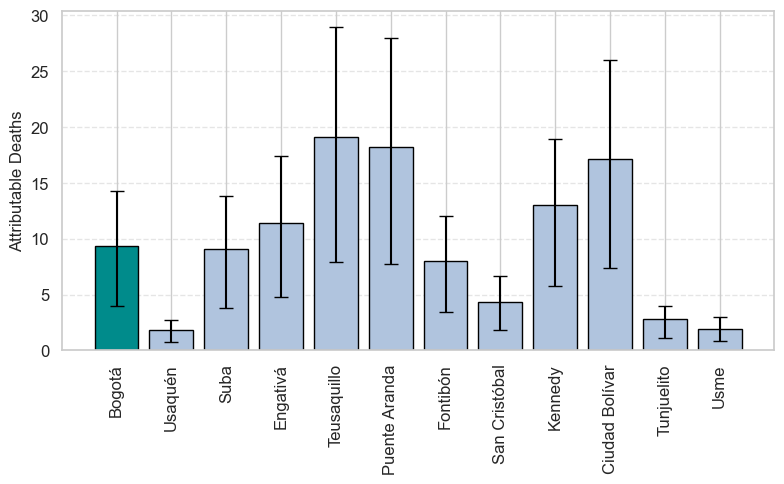

In [90]:
data = {
    'Location': [
        'Bogotá', 'Ciudad Bolívar', 'Engativá', 'Fontibón', 'Kennedy',
        'Puente Aranda', 'San Cristóbal', 'Suba', 'Teusaquillo',
        'Tunjuelito', 'Usaquén', 'Usme'
    ],
    'Deaths': [707, 107, 91, 30, 133, 45, 17, 107, 29, 5, 10, 7],
    'CI_low': [299, 46, 38, 13, 59, 19, 7, 45, 12, 2, 4, 3],
    'CI_high': [1076, 162, 139, 45, 193, 69, 26, 163, 44, 7, 15, 11]
}

desired_order = [
    'Bogotá', 'Usaquén', 'Suba', 'Engativá', 'Teusaquillo',
    'Puente Aranda', 'Fontibón', 'San Cristóbal', 'Kennedy',
    'Ciudad Bolívar', 'Tunjuelito', 'Usme'
]

df_man = pd.DataFrame(data)

# Agrega la población al DataFrame
# Convierte el DataFrame de población en un diccionario {localidad: población_media}
poblacion_dict = dict(zip(poblacion['LOCALIDAD'], poblacion['POBLACION_MEDIA']))

# Usa .map() con ese diccionario
df_man['Poblacion'] = df_man['Location'].map(poblacion_dict)

# Calcula tasa por 100,000 habitantes
df_man['Tasa_100mil'] = (df_man['Deaths'] / df_man['Poblacion']) * 100000

# Muestra los resultados
print(df_man[['Location', 'Deaths', 'Poblacion', 'Tasa_100mil']])

# Calculate error margins
# CI en tasas por 100,000 habitantes
df_man['CI_low_rate'] = (df_man['CI_low'] / df_man['Poblacion']) * 100000
df_man['CI_high_rate'] = (df_man['CI_high'] / df_man['Poblacion']) * 100000

# Tasa media
df_man['Tasa_100mil'] = (df_man['Deaths'] / df_man['Poblacion']) * 100000

# Margen de error para yerr
df_man['err_low'] = df_man['Tasa_100mil'] - df_man['CI_low_rate']
df_man['err_high'] = df_man['CI_high_rate'] - df_man['Tasa_100mil']

df_man['Location'] = pd.Categorical(df_man['Location'], categories=desired_order, ordered=True)
df_man.sort_values('Location', inplace=True)

colors = ['darkcyan' if loc == 'Bogotá' else 'lightsteelblue' for loc in df_man['Location']]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(df_man['Location'], df_man['Tasa_100mil'], yerr=[df_man['err_low'], df_man['err_high']], capsize=5, 
        color=colors, edgecolor='k')
plt.xticks(rotation=90, fontsize = 12)
plt.yticks(fontsize = 12)
plt.ylabel('Attributable Deaths', fontsize = 12)
#plt.title('Attributable Deaths by Location (Age 25+) with 95% CI', fontsize = 13)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
#plt.yscale('log')
plt.savefig('Figures/Figure_10.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns

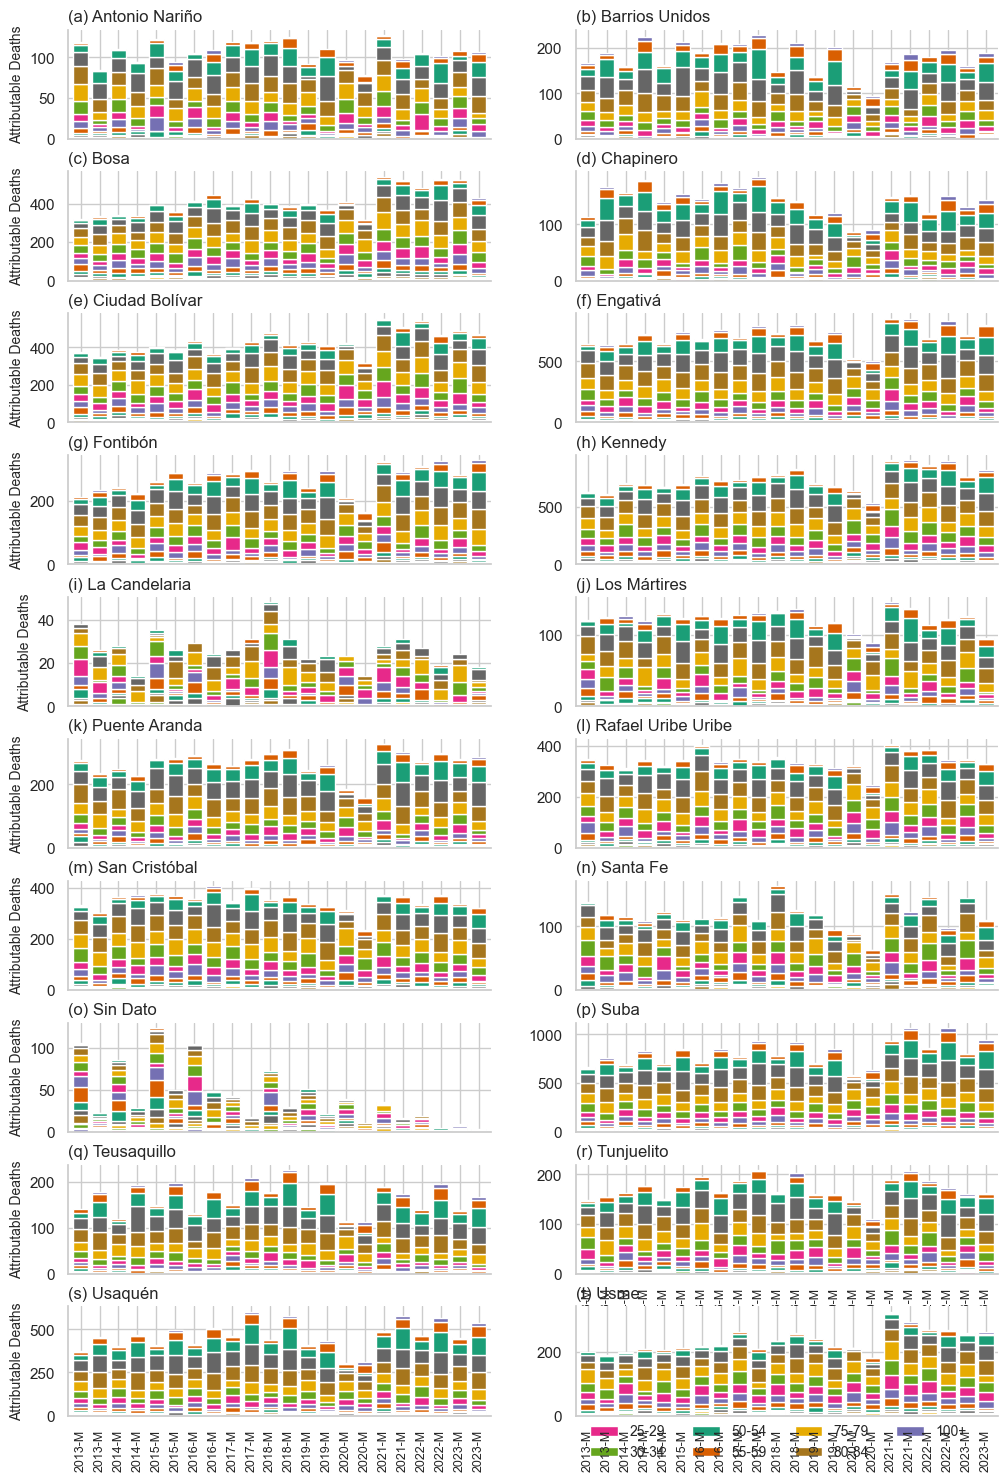

In [69]:
# Remove "Sin información" and "Sumapaz" from localities
datos_filtrados = datos_filtrados[
    ~datos_filtrados["LOCALIDAD"].isin(["Sin información", "Sumapaz"])
]

# Unique localities
localidades_unicas = datos_filtrados["LOCALIDAD"].unique()
n_localities = len(localidades_unicas)

# Define sorted age groups
sorted_age_groups = [
    "0-4", "5-9", "10-14", "15-19", "20-24", "25-29", "30-34", "35-39",
    "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75-79",
    "80-84", "85-89", "90-94", "95-99", "100+"
]

age_group_mapping = {"00 a 04": "0-4","05 a 09": "5-9", "10 a 14": "10-14",
                     "15 a 19": "15-19","20 a 24": "20-24","25 a 29": "25-29",
                     "30 a 34": "30-34","35 a 39": "35-39","40 a 44": "40-44",
                     "45 a 49": "45-49","50 a 54": "50-54","55 a 59": "55-59",
                     "60 a 64": "60-64","65 a 69": "65-69","70 a 74": "70-74",
                     "75 a 79": "75-79","80 a 84": "80-84","85 a 89": "85-89",
                     "90 a 94": "90-94","95 a 99": "95-99","100 o más": "100+"
                    }

# Define a fixed color palette for age groups
paleta_edad = sns.color_palette("Dark2", len(sorted_age_groups))
color_dict = dict(zip(sorted_age_groups, paleta_edad))

# Set up figure with subplots (5 rows, 4 columns)
fig = plt.figure(figsize=(12, 18))
gs = gridspec.GridSpec(10, 2, wspace=0.2, hspace=0.3)

# Create labeled titles (a), (b), (c), etc.
titulo_labels = list("abcdefghijklmnopqrstuvwxyz")[:len(localidades_unicas)]

# Loop through each locality and create a subplot
for i, localidad in enumerate(localidades_unicas):
    row, col = divmod(i, 2)  # Get subplot position
    ax = plt.subplot(gs[row, col])

    # Filter data for locality
    datos_localidad = datos_filtrados[datos_filtrados["LOCALIDAD"] == localidad]

    datos_agrupados = datos_localidad.groupby(
        ['ANO', 'SEXO', 'EDAD_QUINQUENAL']
    )['TOTAL_CASOS'].sum().unstack().fillna(0)

    #pdb.set_trace()
    # Reorder columns based on the sorted age groups
    # Rename columns using the mapping
    datos_agrupados = datos_agrupados.rename(columns=age_group_mapping)

    # Ensure only existing age groups are reindexed (to avoid filling everything with 0s)
    existing_age_groups = [age for age in sorted_age_groups if age in datos_agrupados.columns]
    datos_agrupados = datos_agrupados.reindex(columns=existing_age_groups, fill_value=0)


    # Rename index for formatted x-axis labels (e.g., "2010-F", "2010-M")
    datos_agrupados.index = [
        f"{year}-F" if sex == "Femenino" else f"{year}-M"
        for year, sex in datos_agrupados.index
    ]

    # Plot stacked bar chart with consistent colors
    datos_agrupados.plot(kind="bar", stacked=True, ax=ax, width=0.8, color=[color_dict[age] for age in sorted_age_groups])

    # Titles and labels
    ax.set_title(f"({titulo_labels[i]}) {localidad}", loc="left", fontsize=12)
    ax.set_xlabel("")  # Remove x-labels except last row
    ax.set_ylabel("Attributable Deaths" if col == 0 else "", fontsize = 10)  # Y-label only on first column

    # Remove duplicate legends in individual plots
    plt.legend([], frameon=False)

    # X-axis settings: Only last row should show x labels
    if row == 9:  # Last row
        ax.set_xticks(range(len(datos_agrupados.index)))
        ax.set_xticklabels(datos_agrupados.index, rotation=90, fontsize=9)
    elif i == 17:
        ax.set_xticks(range(len(datos_agrupados.index)))
        ax.set_xticklabels(datos_agrupados.index, rotation=90, fontsize=9)
    else:
        ax.set_xticklabels([])


    # Remove spines for cleaner look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if i == 18:
        # **Create the legend separately above the first row**
        handles, labels = ax.get_legend_handles_labels()
        plt.legend(handles, labels, title = 'Age Group', loc="upper center", ncol=4,
                   fontsize=10, frameon=False, bbox_to_anchor=(1.685, 0.8), title_fontsize = 10)

#plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit legend
plt.show()


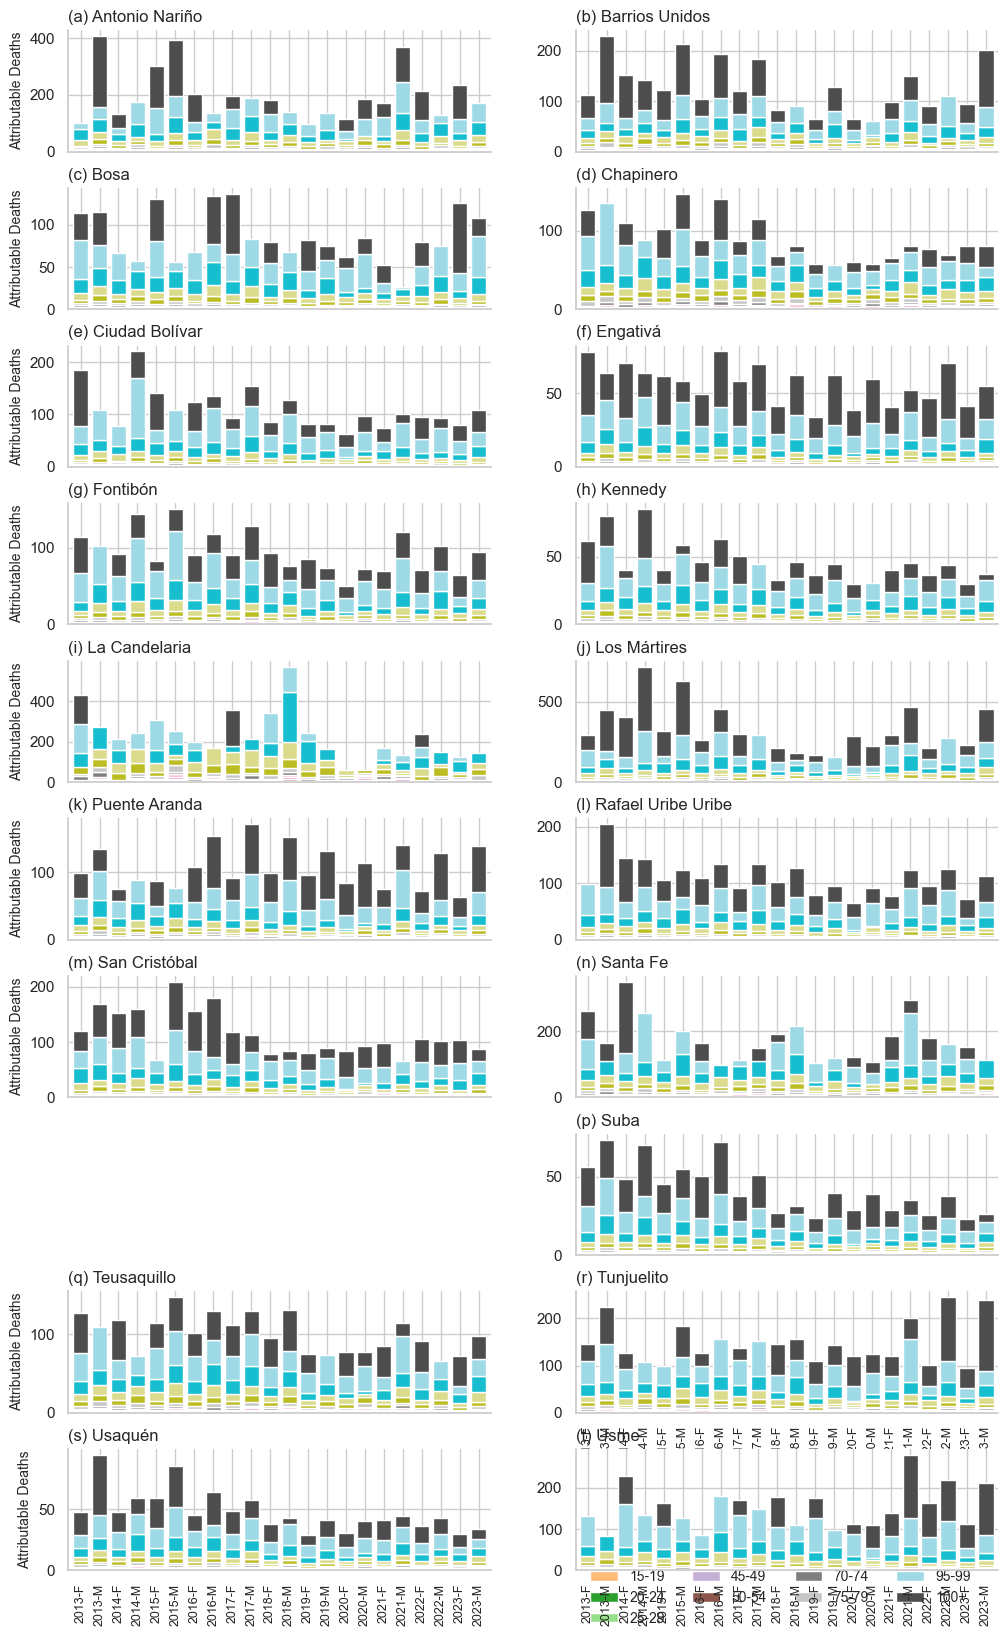

In [114]:
def get_age_group(edad):
    if edad >= 100:
        return "100+"
    else:
        low = (edad // 5) * 5
        high = low + 4
        return f"{low}-{high}"
    
# Merge population data
tmp_h['SEXO'] = 'Hombres'
tmp_m['SEXO'] = 'Mujeres'
poblacion_df = pd.concat([tmp_h, tmp_m])

poblacion_df['Grupo_Edad'] = poblacion_df['Edad'].apply(get_age_group)

poblacion_df['SEXO'] = poblacion_df['SEXO'].map({'Hombres': 'Masculino', 'Mujeres': 'Femenino'})

poblacion_df = poblacion_df[
    ~poblacion_df["LOCALIDAD"].isin(["Sin información", "Sumapaz"])
]

# Age group mapping and order
sorted_age_groups = [
    "0-4", "5-9", "10-14", "15-19", "20-24", "25-29", "30-34", "35-39",
    "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75-79",
    "80-84", "85-89", "90-94", "95-99", "100+"
]

age_group_mapping = {
    "00 a 04": "0-4", "00 a 04 años": "0-4",
    "05 a 09": "5-9", "05 a 09 años": "5-9",
    "10 a 14": "10-14", "10 a 14 años": "10-14",
    "15 a 19": "15-19", "15 a 19 años": "15-19",
    "20 a 24": "20-24", "20 a 24 años": "20-24",
    "25 a 29": "25-29", "25 a 29 años": "25-29",
    "30 a 34": "30-34", "30 a 34 años": "30-34",
    "35 a 39": "35-39", "35 a 39 años": "35-39",
    "40 a 44": "40-44", "40 a 44 años": "40-44",
    "45 a 49": "45-49", "45 a 49 años": "45-49",
    "50 a 54": "50-54", "50 a 54 años": "50-54",
    "55 a 59": "55-59", "55 a 59 años": "55-59",
    "60 a 64": "60-64", "60 a 64 años": "60-64",
    "65 a 69": "65-69", "65 a 69 años": "65-69",
    "70 a 74": "70-74", "70 a 74 años": "70-74",
    "75 a 79": "75-79", "75 a 79 años": "75-79",
    "80 a 84": "80-84", "80 a 84 años": "80-84",
    "85 a 89": "85-89", "85 a 89 años": "85-89",
    "90 a 94": "90-94", "90 a 94 años": "90-94",
    "95 a 99": "95-99", "95 a 99 años": "95-99",
    "100 o más": "100+", "100 o más años": "100+"
}

# Map values to standard format
sexo_map = {
    'Hombres': 'Masculino',
    'Mujeres': 'Femenino',
}

# Define target values from mapping
target_age_groups = set(age_group_mapping.values())

# For datos_filtrados
if not set(datos_filtrados['EDAD_QUINQUENAL'].dropna().unique()).issubset(target_age_groups):
    datos_filtrados['EDAD_QUINQUENAL'] = datos_filtrados['EDAD_QUINQUENAL'].map(age_group_mapping)

poblacion_agrupada = (
    poblacion_df
    .groupby(['ANO', 'SEXO', 'Grupo_Edad', 'LOCALIDAD'], as_index=False)['Población']
    .sum()
)

# Fixed color palette
# Use tab20 and add one more distinguishable color (21 total)
base_colors = sns.color_palette("tab20")
extra_color = [(0.3, 0.3, 0.3)]  # e.g., dark gray
paleta_edad = base_colors + extra_color

# Map to dictionary
color_dict = dict(zip(sorted_age_groups, paleta_edad))

# Unique localities
localidades_unicas = datos_filtrados["LOCALIDAD"].unique()
titulo_labels = list("abcdefghijklmnopqrstuvwxyz")[:len(localidades_unicas)]

# Set up grid for plots
n_localities = len(localidades_unicas)
n_cols = 2
n_rows = (n_localities + n_cols - 1) // n_cols  # Ceiling division

fig = plt.figure(figsize=(12, n_rows * 2))
gs = gridspec.GridSpec(n_rows, n_cols, wspace=0.2, hspace=0.3)

for i, localidad in enumerate(localidades_unicas):
    row, col = divmod(i, 2)
    ax = plt.subplot(gs[row, col])

    # Filter deaths and population by locality
    
    datos_localidad = datos_filtrados[datos_filtrados["LOCALIDAD"] == localidad]
    poblacion_localidad = poblacion_agrupada[poblacion_agrupada["LOCALIDAD"] == localidad]
    
    # Deaths grouped by year, sex, and age group
    #pdb.set_trace()
    datos_muertes = (
        datos_localidad
        .groupby(['ANO', 'SEXO', 'EDAD_QUINQUENAL','LOCALIDAD'])['ANO']
        .count()
        .reset_index(name='muertes')
    )
    # Renombrar columnas para consistencia
    datos_muertes = datos_muertes.rename(columns={
        'EDAD_QUINQUENAL': 'Grupo_Edad',
        'Sexo':'SEXO',
        'Población':'muertes',
    })
    datos_muertes['SEXO'] = datos_muertes['SEXO'].map(sexo_map)
    
    # Merge with population
    merged = pd.merge(
        datos_muertes,
        poblacion_localidad,
        on=['ANO', 'SEXO', 'Grupo_Edad', 'LOCALIDAD'],
        how='left'
    )
    
    # Death rate per 1000
    merged['rate'] = (merged['muertes'] / merged['Población']) * 1000
    
    # Pivot to wide format
    datos_agrupados = (
        merged
        .pivot_table(index=['ANO', 'SEXO'], columns='Grupo_Edad', values='rate')
        .fillna(0)
    )

    # Reorder and rename columns
    datos_agrupados = datos_agrupados.reindex(columns=sorted_age_groups, fill_value=0)

    # Index for x-axis labels
    datos_agrupados.index = [
        f"{year}-F" if sex == "Femenino" else f"{year}-M"
        for year, sex in datos_agrupados.index
    ]
    
    # Plot
    if not datos_agrupados.empty:
        datos_agrupados.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            width=0.8,
            color=[color_dict[age] for age in sorted_age_groups]
        )
        # (Continue with title, labels, etc.)
    else:
        ax.set_visible(False)  # optionally hide the subplot if no data

    ax.set_title(f"({titulo_labels[i]}) {localidad}", loc="left", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Attributable Deaths" if col == 0 else "", fontsize=10)
    plt.legend([], frameon=False)

    if row == 9 or i == 17:
        ax.set_xticks(range(len(datos_agrupados.index)))
        ax.set_xticklabels(datos_agrupados.index, rotation=90, fontsize=9)
    else:
        ax.set_xticklabels([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if i == 18:
        handles, labels = ax.get_legend_handles_labels()
        plt.legend(
            handles, labels, title='Age Group', loc="upper center", ncol=4,
            fontsize=10, frameon=False, bbox_to_anchor=(1.685, 0.8),
            title_fontsize=10
        )

#plt.savefig('Figures/Figure_5.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()


In [234]:
def plot_localities(localidades, title_labels, legend_pos, filename=None):
    valid_localidades = []
    valid_titulo_labels = []

    # First, filter valid localidades (i.e., those with data)
    for localidad, label in zip(localidades, title_labels):
        datos_localidad = datos_filtrados[datos_filtrados["LOCALIDAD"] == localidad]
        if not datos_localidad.empty:
            valid_localidades.append(localidad)
            valid_titulo_labels.append(label)
    try:
        valid_localidades.remove('Sin Dato')
    except:
        print('Data is fine')

    # Now plot only the valid ones
    n_localities = len(valid_localidades)
    n_cols = 2
    n_rows = (n_localities + n_cols - 1) // n_cols
   

    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(n_rows, n_cols, wspace=0.2, hspace=0.3)

    for i, localidad in enumerate(valid_localidades):
        row, col = divmod(i, 2)
        ax = plt.subplot(gs[i])

        datos_localidad = datos_filtrados[datos_filtrados["LOCALIDAD"] == localidad]
        poblacion_localidad = poblacion_agrupada[poblacion_agrupada["LOCALIDAD"] == localidad]

        datos_muertes = (
            datos_localidad
            .groupby(['ANO', 'SEXO', 'EDAD_QUINQUENAL', 'LOCALIDAD'])['ANO']
            .count()
            .reset_index(name='muertes')
        )
        datos_muertes = datos_muertes.rename(columns={
            'EDAD_QUINQUENAL': 'Grupo_Edad',
        })
        datos_muertes['SEXO'] = datos_muertes['SEXO'].map(sexo_map)

        merged = pd.merge(
            datos_muertes,
            poblacion_localidad,
            on=['ANO', 'SEXO', 'Grupo_Edad', 'LOCALIDAD'],
            how='left'
        )

        merged['rate'] = (merged['muertes'] / merged['Población']) * 1000
        datos_agrupados = (
            merged
            .pivot_table(index=['ANO', 'SEXO'], columns='Grupo_Edad', values='rate')
            .fillna(0)
        )
        datos_agrupados = datos_agrupados.reindex(columns=sorted_age_groups, fill_value=0)
        datos_agrupados.index = [
            f"{year}-F" if sex == "Femenino" else f"{year}-M"
            for year, sex in datos_agrupados.index
        ]

        if not datos_agrupados.empty:
            datos_agrupados.plot(
                kind="bar",
                stacked=True,
                ax=ax,
                width=0.8,
                color=[color_dict[age] for age in sorted_age_groups]
            )
        else:
            ax.set_visible(False)

        ax.set_title(f"({title_labels[i]}) {localidad}", loc="left", fontsize=12)
        ax.set_xlabel("")
        #ax.set_ylabel("Attributable Deaths" if col == 0 else "", fontsize=10)
        
        if legend_pos == 0:
            if row == n_rows - 1:
                ax.set_xticks(range(len(datos_agrupados.index)))
                ax.set_xticklabels(datos_agrupados.index, rotation=90, fontsize=12)
            else:
                ax.set_xticklabels([])
        else:
            if i == 7 or i == 8:
                ax.set_xticks(range(len(datos_agrupados.index)))
                ax.set_xticklabels(datos_agrupados.index, rotation=90, fontsize=12)
            else:
                ax.set_xticklabels([])

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis='x', which='both', bottom=True, top=False, length=3)
        plt.grid(False)
        plt.legend([], frameon=False)
        ax.tick_params(axis='y', labelsize=12)
        
        # Optional legend on last subplot
        if legend_pos == 0:    
            if i == 0:
                handles, labels = ax.get_legend_handles_labels()
                plt.legend(
                    handles, labels, title='Age Group', loc="upper center", ncol=8,
                    fontsize=12, frameon=False, bbox_to_anchor=(1.1, 2.4),
                    title_fontsize=12
                )
        else:
            if i == 8:
                handles, labels = ax.get_legend_handles_labels()
                plt.legend(
                    handles, labels, title='Age Group', loc="upper center", ncol=4,
                    fontsize=12, frameon=False, bbox_to_anchor=(1.675, 0.7),
                    title_fontsize=12
                )
    fig.text(0.06, 0.5, 'Attributable Deaths', va='center', rotation='vertical', fontsize=16)
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()


Data is fine


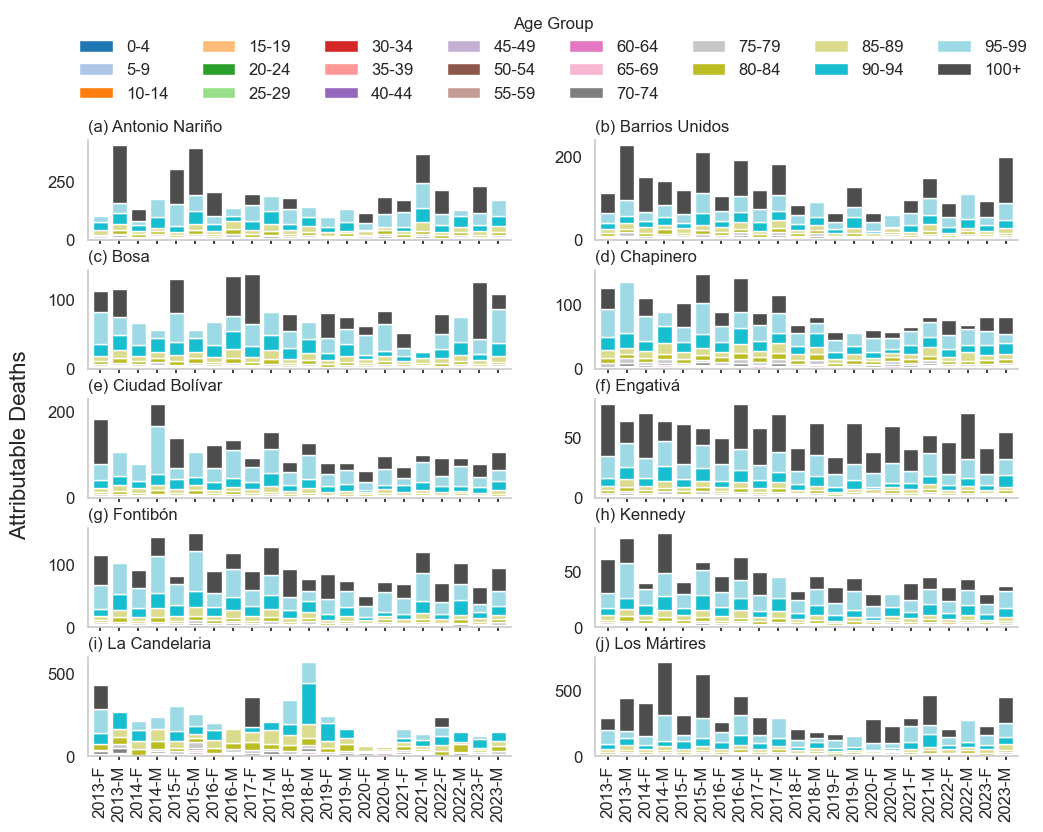

In [236]:
# First 10
plot_localities(localidades_unicas[:10], titulo_labels[:10], 0, filename='Figures/Figure_5.pdf')

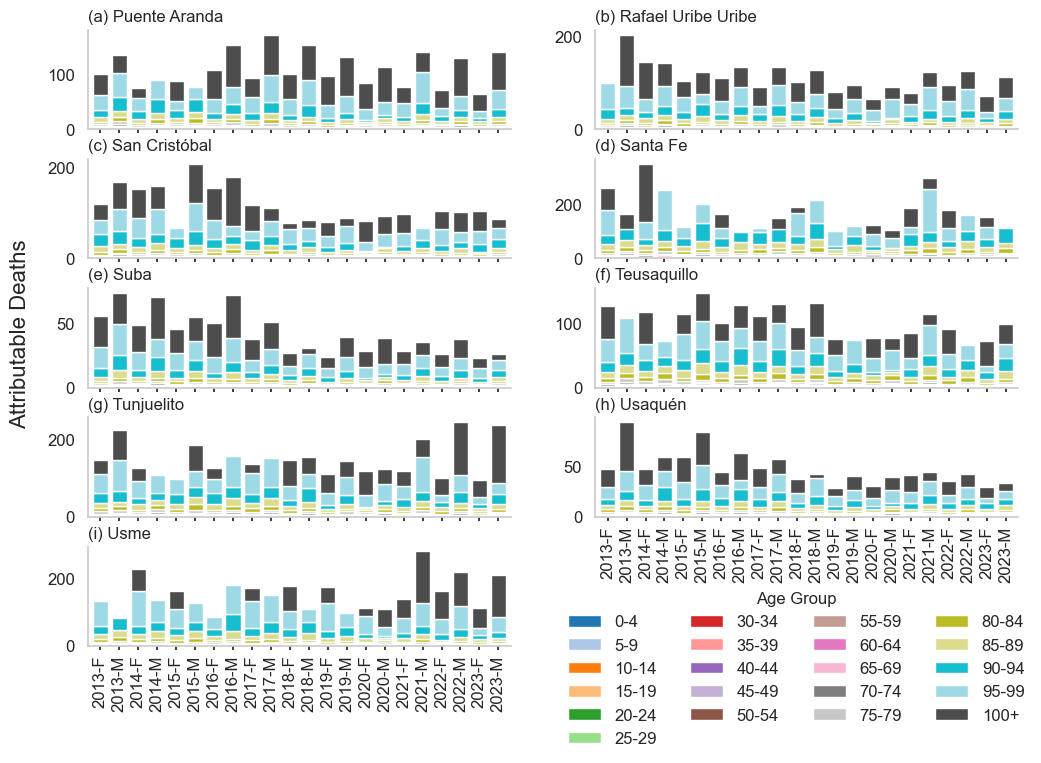

In [224]:
# Remaining (up to 10 more)
plot_localities(localidades_unicas[10:], titulo_labels[:10], 1, filename='Figures/Figure_6.jpg')

In [ ]:
datos_filtrados['COUNT_OF_DEATHS'] = 1
df_agg = (
    datos_filtrados
    .groupby(['ANIO', 'SEXO', 'LOCALIDAD_NOMBRE', 'EDAD_GRUPO'], dropna=False)['COUNT_OF_DEATHS']
    .sum()
    .reset_index()
)

In [ ]:
# Function to extract numeric midpoint from age group labels
def convert_age_group_to_numeric(age_group):
    """
    Converts an age group string (e.g., "20 a 24 años") to the numeric midpoint.
    """
    match = re.search(r"(\d+)\s*a\s*(\d+)", str(age_group))
    if match:
        lower, upper = map(int, match.groups())
        return (lower + upper) / 2  # Compute midpoint
    elif "y más" in str(age_group):  # Special case for "90 y más"
        return 95  # Assign 95 as an approximation for 90+
    else:
        return np.nan

# Replace numeric age with categorical labels
def convert_age_numeric_to_label(age_numeric):
    """Convert numeric age midpoints to categorical labels"""
    return age_bins.get(age_numeric, "Unknown")

# Function to generate hexbin plots using a 4-column layout
def plot_hexbin_deaths(datos_filtrados, gridsize=30, cmap="viridis"):
    """
    Creates hexbin plots for multiple localities using a **4-column** layout.
    - **3 columns for plots, 1 column for colorbars**
    - **X-axis: Year (ANIO), Y-axis: Age Group (converted to numeric), Color: Frequency count**
    - **Logarithmic binning for better visibility**

    Args:
        datos_filtrados (pd.DataFrame): Filtered dataset containing deaths, age group, and year.
        gridsize (int): Grid size for hexbins (default=30).
        cmap (str): Colormap for hexbin plots.
    """


    # Remove "Sin informacion" from localities
    datos_filtrados = datos_filtrados[datos_filtrados["LOCALIDAD_NOMBRE"] != "Sin información"].copy()

    localidades_unicas = datos_filtrados["LOCALIDAD_NOMBRE"].unique()
    n_localities = len(localidades_unicas)
    n_cols = 4  # Set 4 columns (3 plots + 1 for colorbars)
    n_plot_cols = 3  # Number of plot columns (excluding colorbars)
    n_rows = int(np.ceil(n_localities / n_plot_cols))  # Compute required rows

    # Convert age group to numeric
    datos_filtrados["EDAD_GRUPO_NUMERIC"] = datos_filtrados["EDAD_GRUPO"].apply(convert_age_group_to_numeric)
    # Apply conversion to the dataset
    datos_filtrados["EDAD_GRUPO_LABEL"] = datos_filtrados["EDAD_GRUPO_NUMERIC"].map(convert_age_numeric_to_label)

    # Unique sorted numeric values for y-axis ticks
    sorted_age_numeric = sorted(age_bins.keys())

    # Filter valid numeric values
    datos_filtrados = datos_filtrados.dropna(subset=["ANIO", "EDAD_GRUPO_NUMERIC"])
    datos_filtrados["ANIO"] = pd.to_numeric(datos_filtrados["ANIO"], errors="coerce")

    # Compute global limits for consistency
    valid_ages = datos_filtrados["EDAD_GRUPO_NUMERIC"].dropna()
    valid_years = datos_filtrados["ANIO"].dropna()

    if valid_ages.empty or valid_years.empty:
        print("Error: No valid data found for plotting.")
        return

    x_min, x_max = valid_years.min(), valid_years.max()
    y_min, y_max = valid_ages.min(), valid_ages.max()
    titulo = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)',
              '(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)','(u)']
    year_label = [2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021]

    # Compute global vmin/vmax safely
    all_counts = []
    for localidad in localidades_unicas:
        df_localidad = datos_filtrados[datos_filtrados["LOCALIDAD_NOMBRE"] == localidad]
        if df_localidad.empty:
            continue
        hb_counts, _, _ = np.histogram2d(df_localidad["ANIO"], df_localidad["EDAD_GRUPO_NUMERIC"], bins=gridsize)
        all_counts.append(hb_counts)

    # Flatten the list and compute valid min/max
    if all_counts:
        all_counts = np.concatenate(all_counts).flatten()
        vmin, vmax = np.percentile(all_counts[all_counts > 0], [2, 98]) if all_counts.size > 0 else (1, 10)
    else:
        vmin, vmax = 1, 10

    # Create figure with a 4-column layout
    fig = plt.figure(figsize=(18, 4 * n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols, width_ratios=[1, 1, 1, 0.1])  # 3 plots + 1 colorbar column

    hexbin_collections = []
    colorbar_axes = []

    for i, localidad in enumerate(localidades_unicas):
        row, col = divmod(i, n_plot_cols)  # Calculate row and column index for each locality
        ax = plt.subplot(gs[row, col])

        # Filter data for the locality
        df_localidad = datos_filtrados[datos_filtrados["LOCALIDAD_NOMBRE"] == localidad]
        if df_localidad.empty:
            ax.axis("off")  # Hide empty plots
            continue

        # Hexbin plot
        hb = ax.hexbin(
            df_localidad["ANIO"], df_localidad["EDAD_GRUPO_NUMERIC"], gridsize=gridsize, cmap=cmap,
            bins=None, mincnt=1, vmin=vmin, vmax=vmax, edgecolors='none'
        )

        hexbin_collections.append(hb)
        ax.set_title(f"{titulo[i]} {localidad}", fontsize=14, loc = 'left')

        # Set labels only on specific axes
        if col == 0:  # First column
            ax.set_ylabel("Age Group", fontsize=12)
            ax.set_yticks(sorted_age_numeric)
            ax.set_yticklabels([age_bins[age] for age in sorted_age_numeric], fontsize=10)
        else:
            ax.set_ylabel("")
            ax.set_yticks(sorted_age_numeric)
            ax.set_yticklabels([])

        # X-axis labels only on the last row
        if row == n_rows - 1:
            #ax.set_xlabel("Year", fontsize=12)
            ax.set_xticks(year_label)
            ax.set_xticklabels(year_label, rotation=90, fontsize=10)
        else:
            ax.set_xticklabels([])

        # Special case: the row before the last in the third column should have xticks and xlabel
        if row == n_rows - 2 and col == 2:
            #ax.set_xlabel("Year", fontsize=12)
            ax.set_xticks(year_label)
            ax.set_xticklabels(year_label, rotation=90, fontsize=10)


    # Hide any remaining empty axes in the last row
    for j in range(i + 1, n_rows * n_plot_cols):
        row, col = divmod(j, n_plot_cols)
        ax = plt.subplot(gs[row, col])
        ax.axis("off")

    # Add one colorbar per row in the fourth column
    for row in range(n_rows):
        cbar_ax = fig.add_subplot(gs[row, 3])  # Assign colorbar to the fourth column
        cbar = plt.colorbar(hexbin_collections[0], cax=cbar_ax)
        cbar.set_label("Frequency of Deaths", fontsize=12)
        cbar.ax.tick_params(labelsize=10)
        colorbar_axes.append(cbar_ax)

    plt.tight_layout(rect=[0, 0, 0.95, 1])  # Adjust layout to fit colorbars
    plt.show()



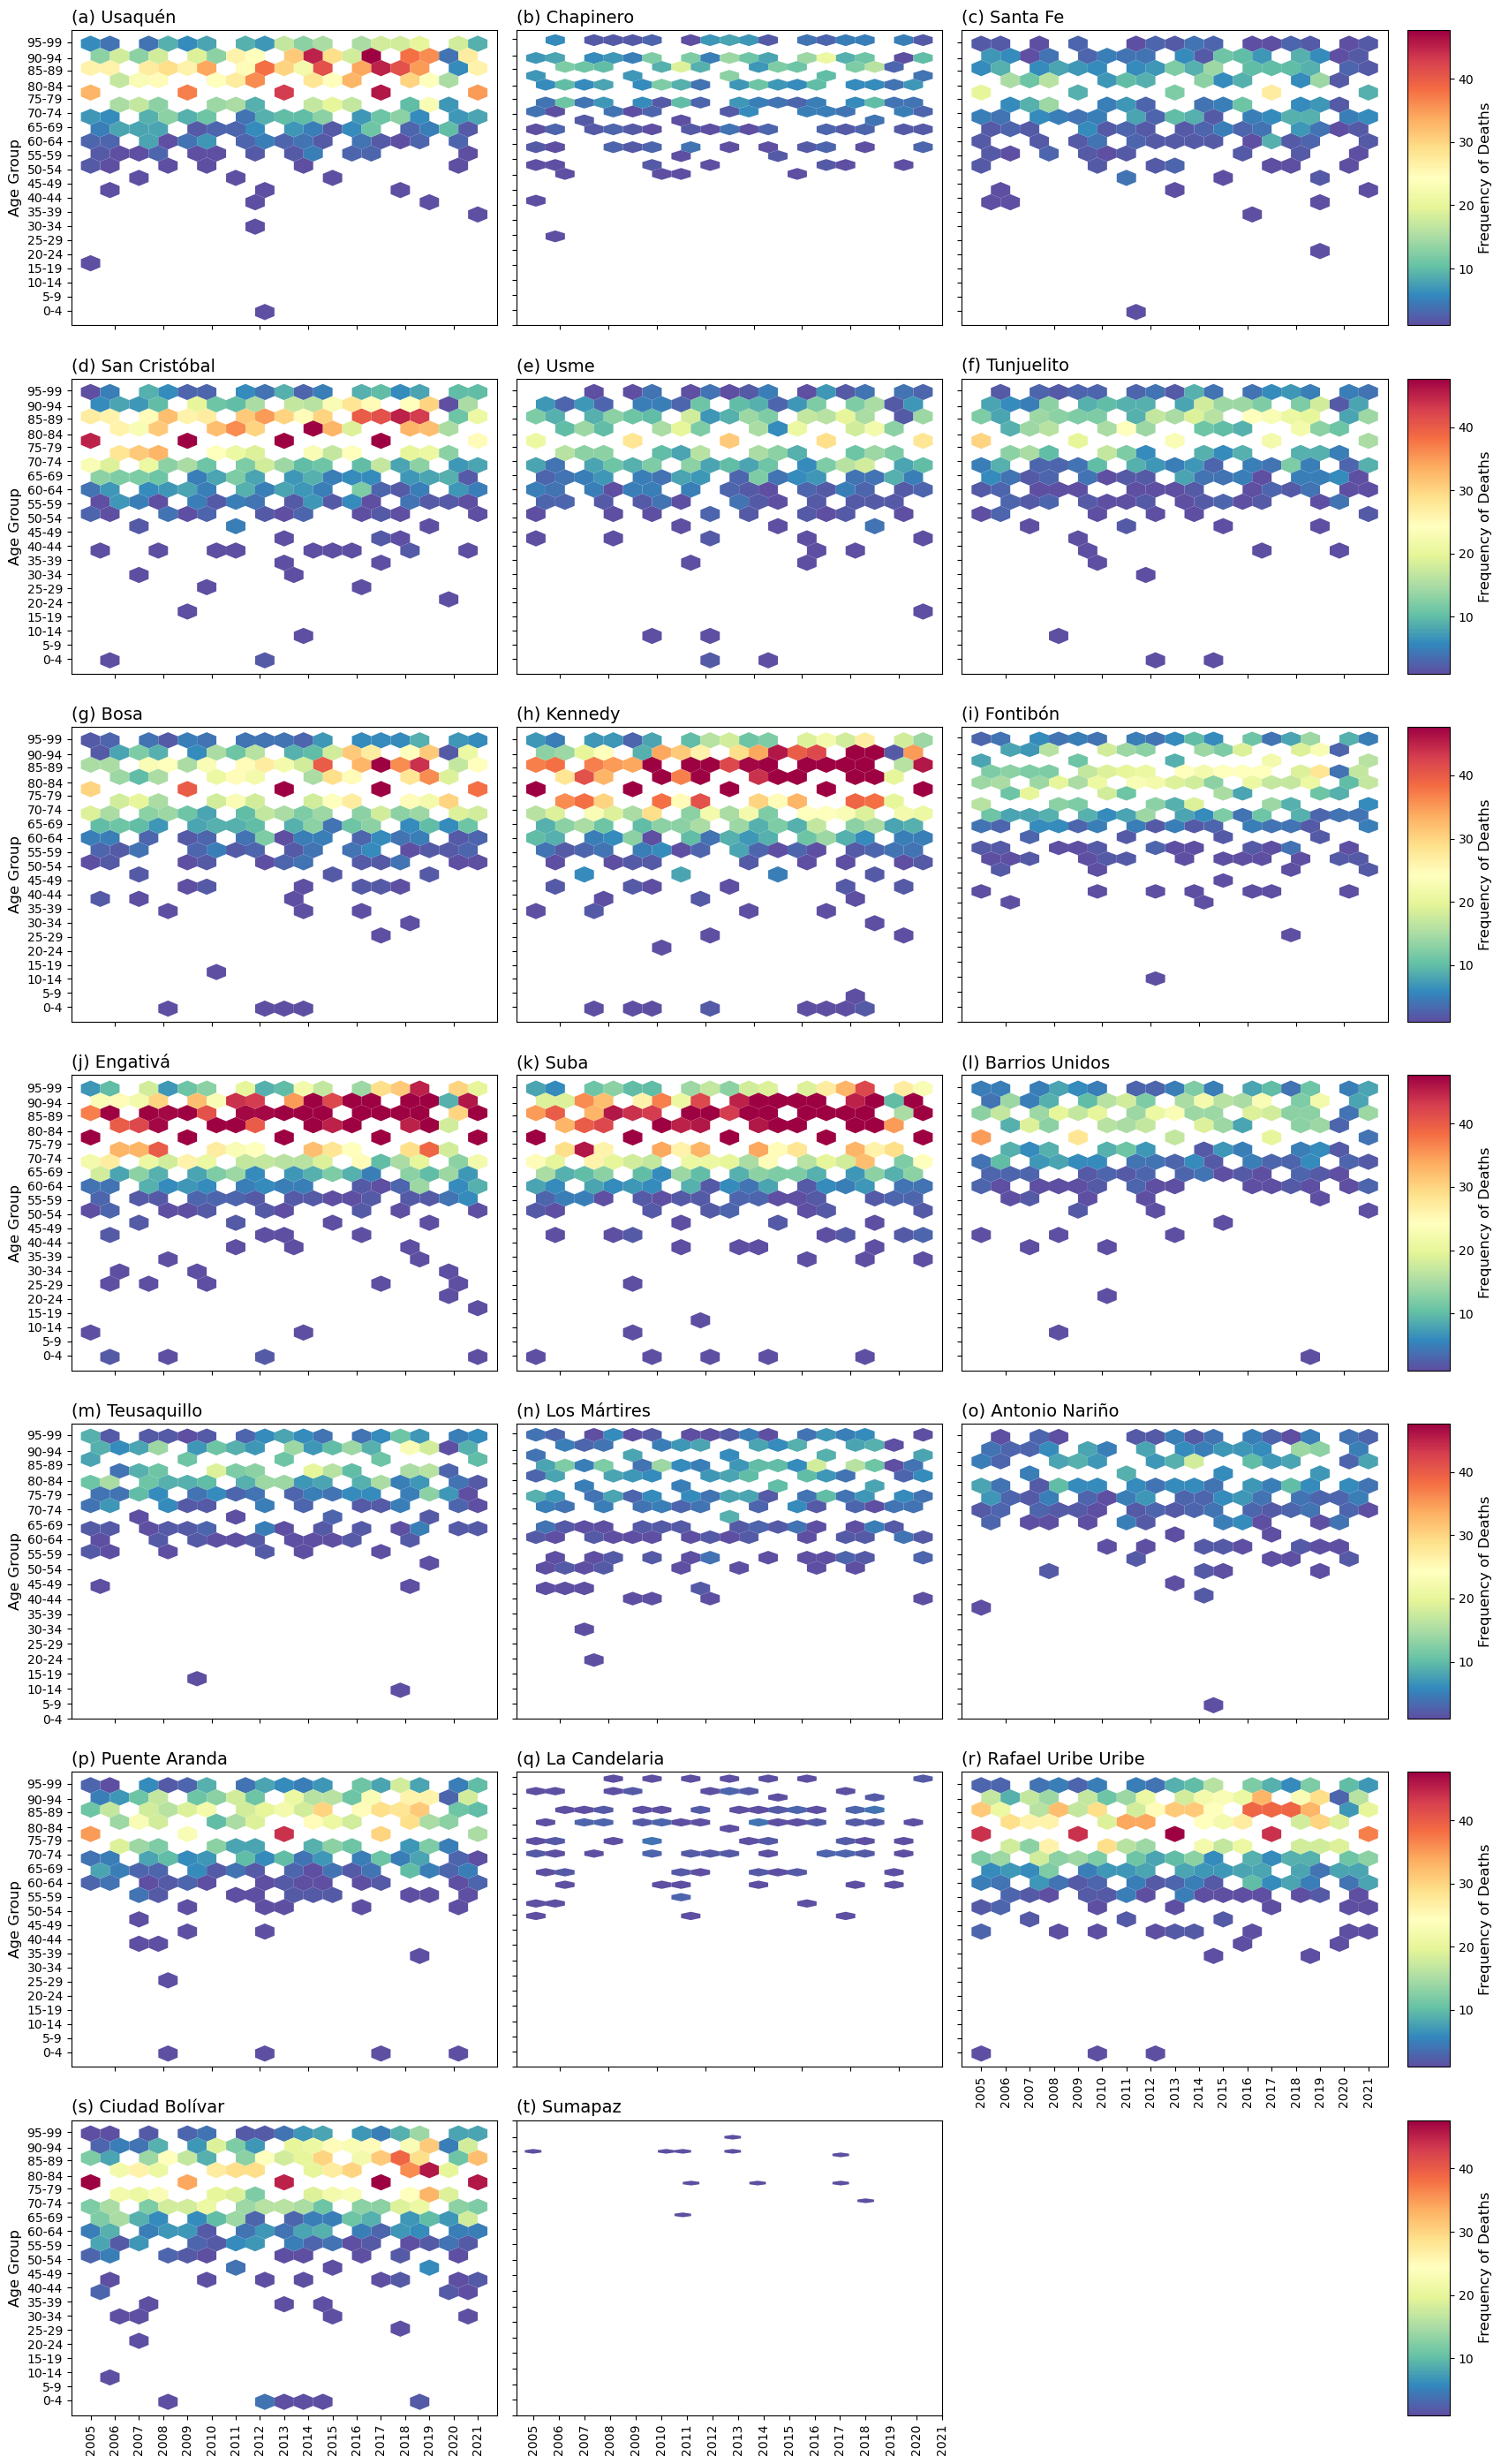

In [ ]:
# Call function with filtered dataset
titulo = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)',
              '(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)','(u)']

age_bins = {
    2.5: "0-4", 7.5: "5-9", 12.5: "10-14", 17.5: "15-19",
    22.5: "20-24", 27.5: "25-29", 32.5: "30-34", 37.5: "35-39",
    42.5: "40-44", 47.5: "45-49", 52.5: "50-54", 57.5: "55-59",
    62.5: "60-64", 67.5: "65-69", 72.5: "70-74", 77.5: "75-79",
    82: "80-84", 87.5: "85-89", 92: "90-94", 97.5:"95-99"}

cmap = LinearSegmentedColormap.from_list('', ['lightblue', 'orange', 'red'])
plot_hexbin_deaths(datos_filtrados, gridsize=20, cmap='Spectral_r')

In [ ]:
df_agg.EDAD_GRUPO.unique()

array(['65 a 69 años', '70 a 74 años', '75 a 79 años', '80 a 84 años',
       '85 a 89 años', '90 a 94 años', '60 a 64 años', '95 a 99 años',
       '40 a 44 años', '55 a 59 años', '50 a 54 años', '45 a 49 años',
       '00 a 04 años', '20 a 24 años', '10 a 14 años', '35 a 39 años',
       '30 a 34 años', '25 a 29 años', '100 o más años', '15 a 19 años',
       '05 a 09 años'], dtype=object)

In [ ]:
import numpy as np

def GEMM(Ci, b, a, m, n):
    C0 = 2.4  # μg/m^3, valor mínimo teórico de exposición de riesgo
    DCi = np.maximum(0, Ci - C0)
    exp_term = np.exp(b * np.log((DCi / a) + 1) / (1 + np.exp(-(DCi - m) / n)))
    RRi = np.exp(exp_term)
    return RRi


Ci = 17.2  # Concentración anual de OZONO en μg/m^3 promedio anual año 2020
b = 0.2969  # Coeficiente del modelo de exposición-respuesta enfermedad IHD
a = 1.9  # Parámetro 'a' del modelo enfermedad IHD
m = 12  # Parámetro 'm' del modelo enfermedad IHD
n = 40.2  # Parámetro 'n' del modelo enfermedad IHD

RRi = GEMM(Ci, b, a, m, n)
print("El RRi para una concentración de O3 de", Ci, "μg/m^3 es:", RRi)

El RRi para una concentración de O3 de 17.2 μg/m^3 es: 4.0406232063385845


In [ ]:
import math

In [ ]:
def calculate_mortality_change(Y0, Population, Delta_PM, beta):
    mortality_change = Y0 * Population * (1 - math.exp(-beta * Delta_PM))
    return mortality_change

Y0 = 13  # Tasa de mortalidad basal
Population = 878430  # población expuesta
Delta_PM = 10  # cambio anual en concentración de PM2.5
beta = 0.1

mortality_change = calculate_mortality_change(Y0, Population, Delta_PM, beta)

# GEMM POR ENFERMEDAD

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Función para calcular el RR usando el modelo GEMM
def calculate_rr(Ci_values, beta, alpha, mu, nu, C0=2.4):
    delta_Ci = np.maximum(0, np.array(Ci_values) - C0)  # ∆Ci = max(0, Ci - C0)
    exposure_response = np.log(delta_Ci / alpha + 1) / (1 + np.exp(-(delta_Ci - mu) / nu))
    RR = np.exp(beta * exposure_response)  # Fórmula GEMM
    return RR

# Cargar los datos de PM2.5 desde un archivo Excel
    filename = "Ozono_llenado.csv"  # Reemplaza con el nombre de tu archivo
    df = pd.read_csv(filename)
#pm_df = pd.read_excel(df, sheet_name="Hoja1")  # Ajusta el nombre de la hoja si es necesario
Ci_values = df["Ozone"].values  # Lista de concentraciones de PM2.5 para varios años

# Cargar los parámetros desde el archivo Excel
param_file = "parametros_enfermedad.xlsx"
params_df = pd.read_excel(param_file)

# Colores para diferenciar las enfermedades en la gráfica
colores = ['red','darkcyan','royalblue','lightcoral','purple']

plt.figure(figsize=(8, 6))

# Iterar sobre cada enfermedad y calcular RR para cada concentración de PM2.5
for i, row in params_df.iterrows():
    enfermedad = row["enfermedad"]  # Nombre de la enfermedad desde el archivo
    beta, alpha, mu, nu = row["beta"], row["alpha"], row["mu"], row["nu"]
    RR_values = calculate_rr(Ci_values, beta, alpha, mu, nu)

    # Graficar con líneas conectando los puntos y la etiqueta con el nombre real de la enfermedad
    #plt.plot(Ci_values, RR_values, marker="o", linestyle="-", color=colores[i % len(colores)], label=enfermedad)
    plt.plot(Ci_values, RR_values, linestyle="-", linewidth=1, color=colores[i % len(colores)], label=enfermedad)

#INTERVALO DE CONFIANZA DE CADA ENFERMEDAD

# Personalización de la gráfica
plt.xlabel("Ozone Concentration (ppb)")
plt.ylabel("Relative Risk (RR)")
plt.title("Global Exposure Mortality Model (GEMM)")
plt.legend(ncol=2, frameon = False, fontsize = 12)
plt.grid(linestyle = ':', linewidth = 0.5)
plt.show()



NameError: name 'df' is not defined

# REGRESION LINEAL


In [ ]:
import pandas as pd

df = pd.read_excel("data_insumo/PM25_Localidad.xlsx")
display(df.head())

,AÑO,LOCALIDAD,PM2.5,Total Población,Total Muertes
0,2022,Engativá,15.67,815262,61970
1,2022,Kennedy,33.59,1034293,55296
2,2022,Teusaquillo,14.51,167657,18005
3,2022,Ciudad Bolívar,19.22,656015,79002
4,2022,Fontibón,18.89,399020,22482


In [ ]:
# Check for missing values in 'PM2.5', 'Total Población', and 'Total Muertes'
missing_values = df[['PM2.5', 'Total Población', 'Total Muertes']].isnull().sum()
print("Missing Values:\n", missing_values)

# Remove rows with missing values
df.dropna(subset=['PM2.5', 'Total Población', 'Total Muertes'], inplace=True)

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print("\nDuplicate Rows:", duplicate_rows)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

Missing Values:
 PM2.5              1
Total Población    0
Total Muertes      0
dtype: int64

Duplicate Rows: 17


In [ ]:
import numpy as np

# Function to identify outliers using IQR
def identify_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

# Check for outliers in 'PM2.5', 'Total Población', and 'Total Muertes'
for column in ['PM2.5', 'Total Población', 'Total Muertes']:
    outliers = identify_outliers_iqr(df[column])
    print(f"\nOutliers in {column}:\n", outliers)

# Cap outliers in 'PM2.5', 'Total Población', and 'Total Muertes'
for column in ['PM2.5', 'Total Población', 'Total Muertes']:
    Q1 = np.percentile(df[column], 25)
    Q3 = np.percentile(df[column], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])


Outliers in PM2.5:
 1      33.590000
15     33.476841
43     36.404734
99     30.927954
113    31.950031
119    30.659083
127    30.259572
Name: PM2.5, dtype: float64

Outliers in Total Población:
 13     7873316
27     7823334
41     7732161
55     7592871
69     7412566
83     7337449
97     7300918
111    7273265
125    7252949
138    7228427
Name: Total Población, dtype: int64

Outliers in Total Muertes:
 13     522874
27     522874
41     429730
55     320224
69     310566
83     304563
97     297496
111    284285
125    276929
138    268807
Name: Total Muertes, dtype: int64


In [ ]:
# Ensure the required columns are present
required_columns = ['AÑO', 'LOCALIDAD', 'PM2.5', 'Total Población', 'Total Muertes']
if not all(col in df.columns for col in required_columns):
    raise ValueError("Missing required columns in DataFrame")

# Convert data types to numeric
for col in ['PM2.5', 'Total Población', 'Total Muertes']:
    df[col] = pd.to_numeric(df[col])

# Drop any other columns
columns_to_drop = [col for col in df.columns if col not in required_columns]
df.drop(columns=columns_to_drop, inplace=True)

# Group the data by 'LOCALIDAD' and then by 'AÑO'
df_grouped = df.groupby(['LOCALIDAD', 'AÑO']).agg({
    'PM2.5': 'first',
    'Total Población': 'first',
    'Total Muertes': 'first'
}).reset_index()

display(df_grouped.head())

,LOCALIDAD,AÑO,PM2.5,Total Población,Total Muertes
0,Bogotá,2013,17.295832,1515381.0,95816.5
1,Bogotá,2014,18.193595,1515381.0,95816.5
2,Bogotá,2015,17.407729,1515381.0,95816.5
3,Bogotá,2016,18.375612,1515381.0,95816.5
4,Bogotá,2017,17.338788,1515381.0,95816.5


In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Initialize a dictionary to store regression results
regression_results = {}

# Iterate over each unique location
for location in df_grouped['LOCALIDAD'].unique():
    # Filter data for the current location
    location_data = df_grouped[df_grouped['LOCALIDAD'] == location]

    # Prepare the feature matrix X and the target vector y
    X = location_data[['PM2.5', 'Total Población']]
    y = location_data['Total Muertes']

    # Create and fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Store the results
    regression_results[location] = {
        'intercept': model.intercept_,
        'coefficients': model.coef_,
        'r_squared': model.score(X, y)
    }

# Print the results
print(regression_results)

{'Bogotá': {'intercept': 95816.5, 'coefficients': array([0., 0.]), 'r_squared': 1.0}, 'Ciudad Bolívar': {'intercept': -398015.5551995363, 'coefficients': array([-281.33024228,    0.73349157]), 'r_squared': 0.9236967875599372}, 'Engativá': {'intercept': -663535.4150966988, 'coefficients': array([310.13520254,   0.87849872]), 'r_squared': 0.8521725948128241}, 'Fontibón': {'intercept': -79304.02817539524, 'coefficients': array([-4.12930393e+02,  2.72103865e-01]), 'r_squared': 0.9187726202480676}, 'Kennedy': {'intercept': -705874.9522388106, 'coefficients': array([3.46348311e+03, 6.30279637e-01]), 'r_squared': 0.7859690780085042}, 'Puente Aranda': {'intercept': -266244.03824317356, 'coefficients': array([188.93363628,   1.17608857]), 'r_squared': 0.9144259506509973}, 'San Cristóbal': {'intercept': -33593.09858179363, 'coefficients': array([-1.72827080e+02,  1.18348022e-01]), 'r_squared': 0.8554053595720466}, 'Suba': {'intercept': -287155.4087548194, 'coefficients': array([3.84400283e+02, 2

Regression Significance for Bogotá:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                    -8.000
Date:                Tue, 04 Mar 2025   Prob (F-statistic):               1.00
Time:                        13:31:44   Log-Likelihood:                 227.61
No. Observations:                  10   AIC:                            -451.2
Df Residuals:                       8   BIC:                            -450.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
PM2.5 

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1781: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


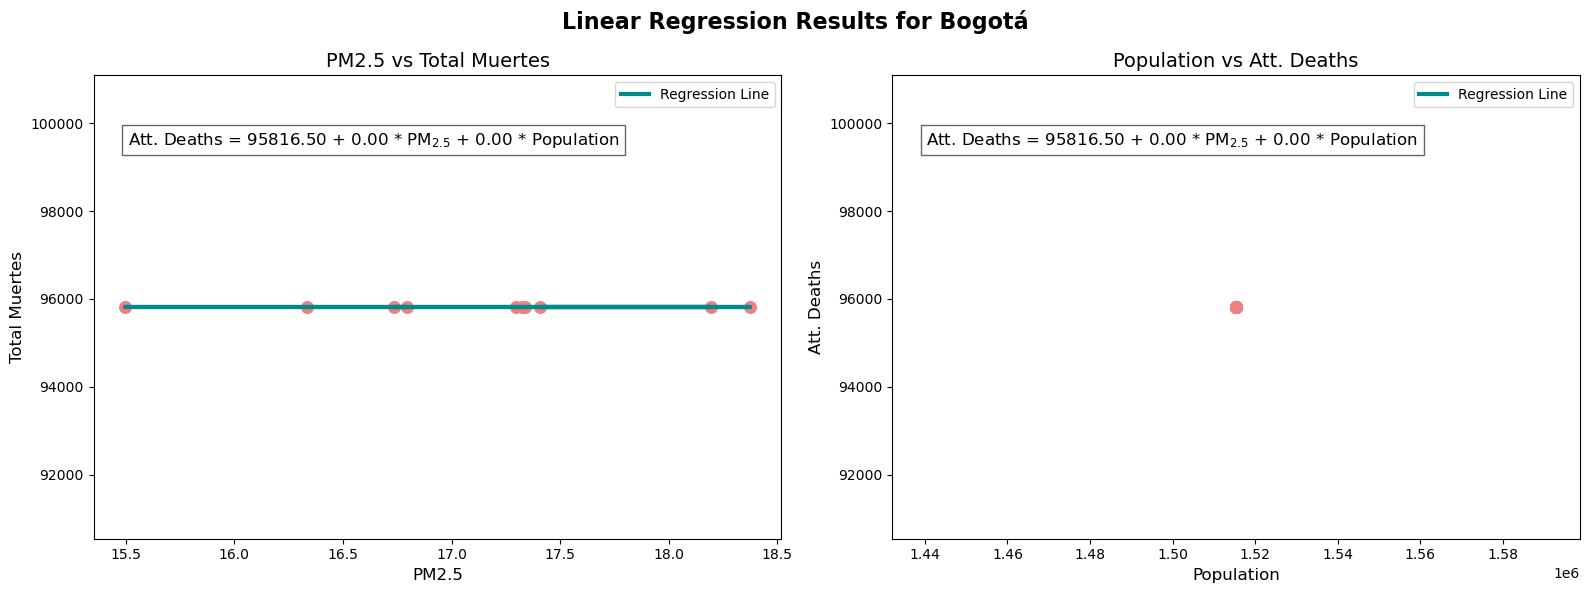

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


Regression Significance for Ciudad Bolívar:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     42.37
Date:                Tue, 04 Mar 2025   Prob (F-statistic):           0.000123
Time:                        13:31:45   Log-Likelihood:                -97.640
No. Observations:                  10   AIC:                             201.3
Df Residuals:                       7   BIC:                             202.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

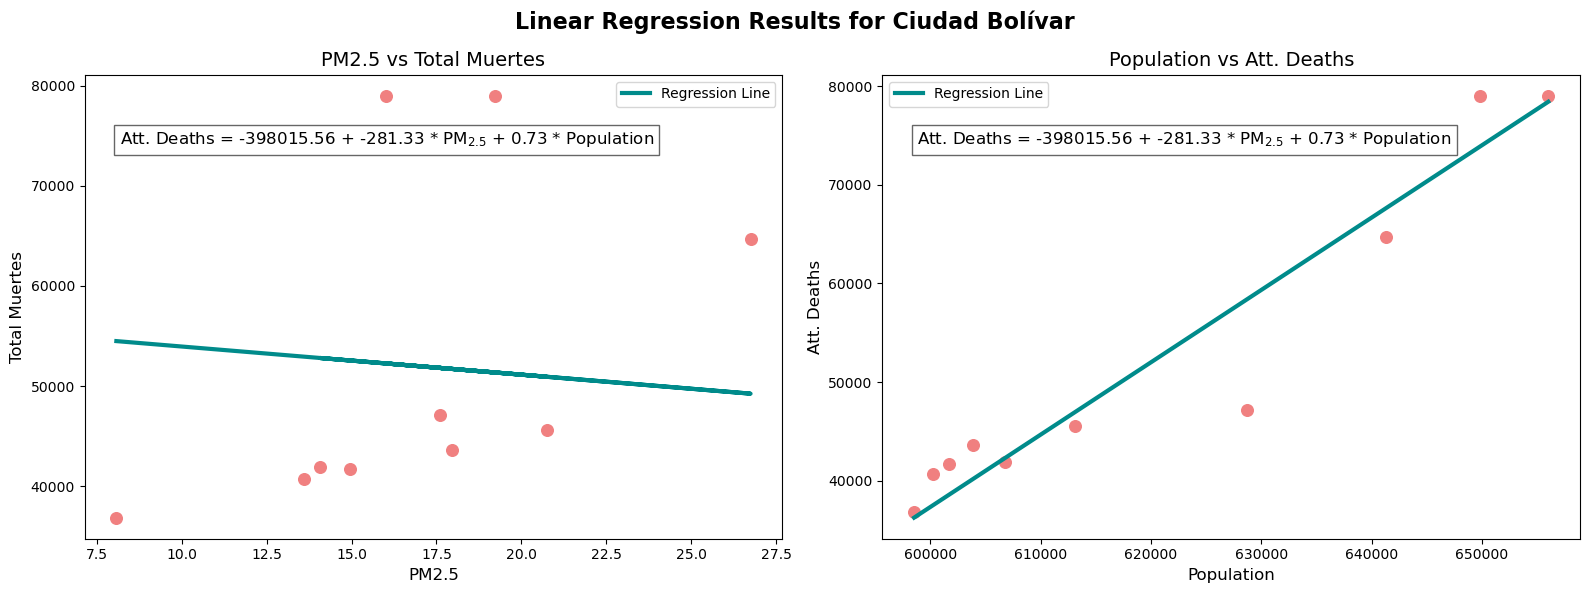

Regression Significance for Engativá:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     20.18
Date:                Tue, 04 Mar 2025   Prob (F-statistic):            0.00124
Time:                        13:31:45   Log-Likelihood:                -98.020
No. Observations:                  10   AIC:                             202.0
Df Residuals:                       7   BIC:                             202.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
cons

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


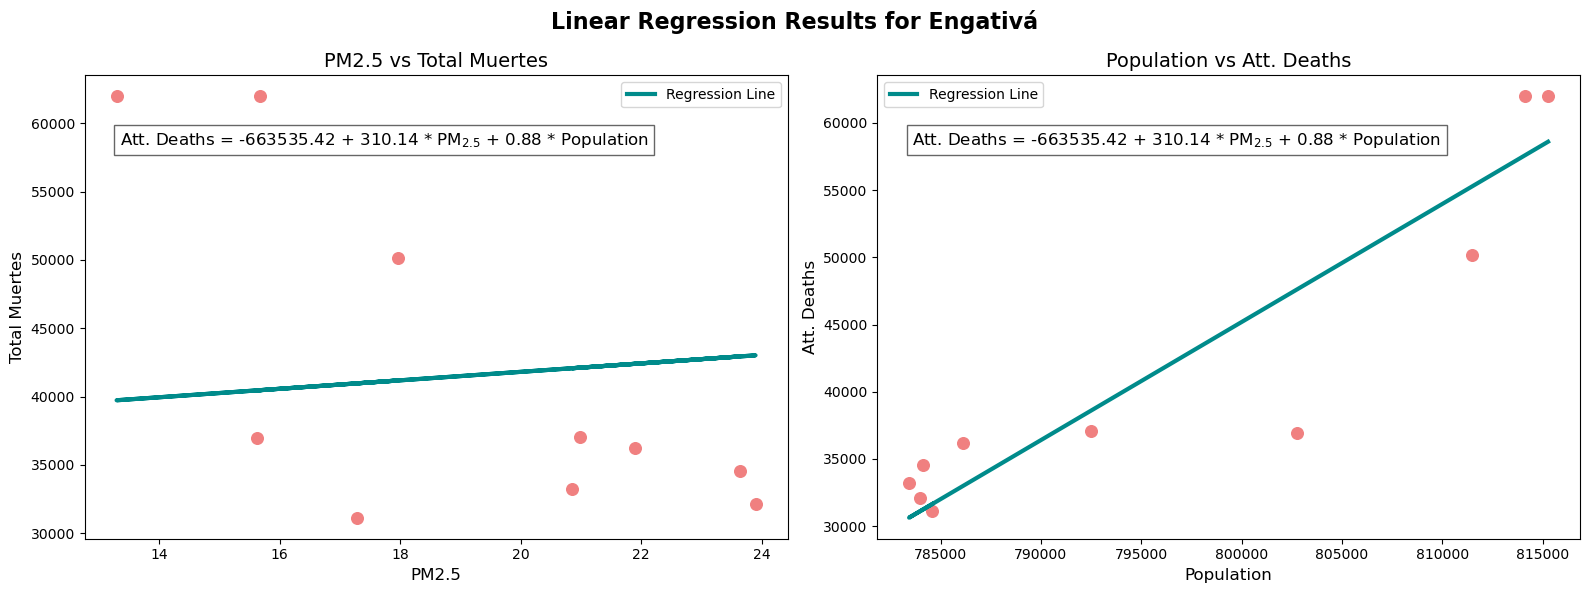

Regression Significance for Fontibón:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     39.59
Date:                Tue, 04 Mar 2025   Prob (F-statistic):           0.000153
Time:                        13:31:45   Log-Likelihood:                -85.308
No. Observations:                  10   AIC:                             176.6
Df Residuals:                       7   BIC:                             177.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
cons

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


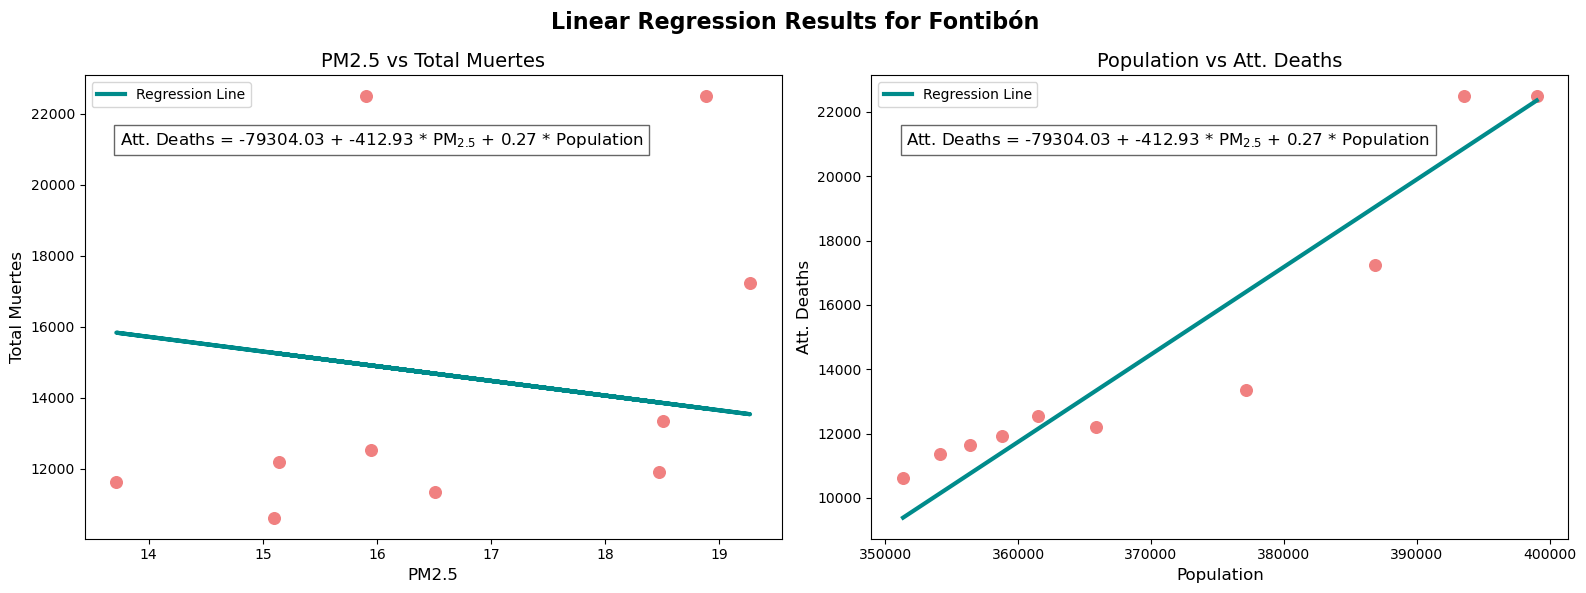

Regression Significance for Kennedy:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     12.85
Date:                Tue, 04 Mar 2025   Prob (F-statistic):            0.00454
Time:                        13:31:45   Log-Likelihood:                -98.937
No. Observations:                  10   AIC:                             203.9
Df Residuals:                       7   BIC:                             204.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


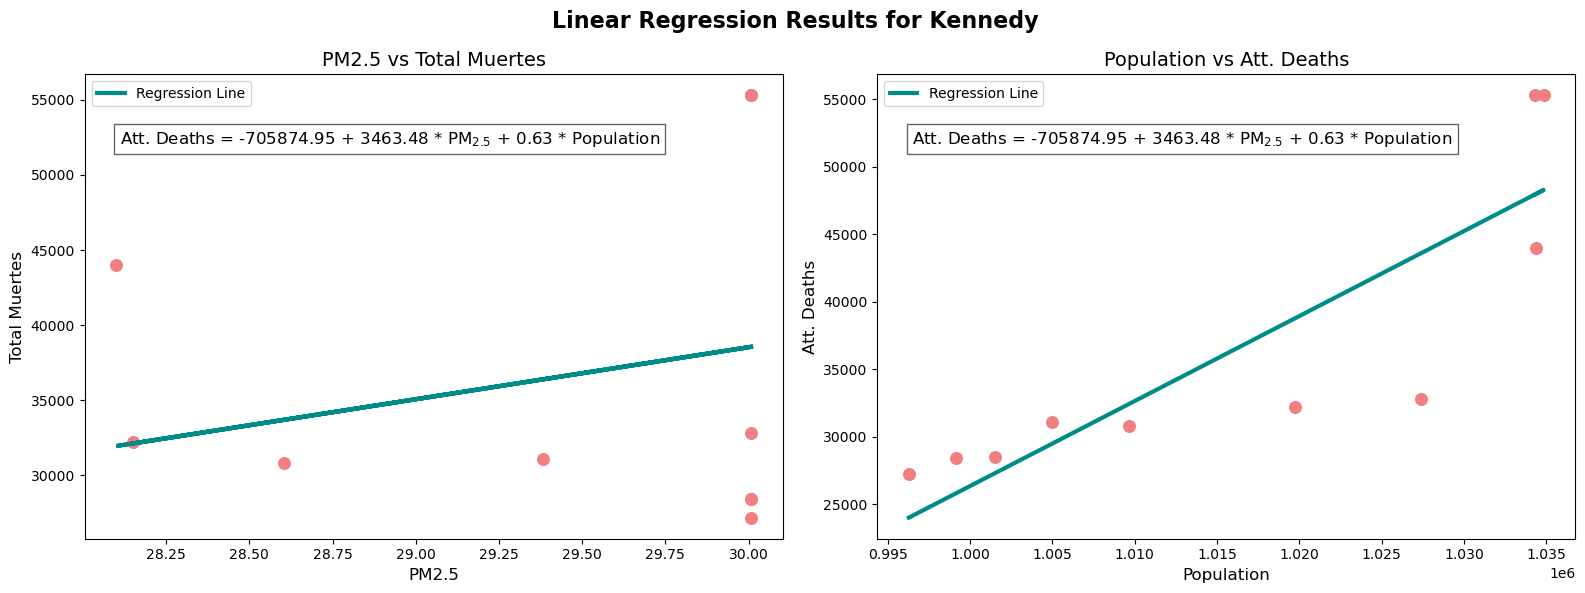

Regression Significance for Puente Aranda:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     37.40
Date:                Tue, 04 Mar 2025   Prob (F-statistic):           0.000183
Time:                        13:31:45   Log-Likelihood:                -90.197
No. Observations:                  10   AIC:                             186.4
Df Residuals:                       7   BIC:                             187.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


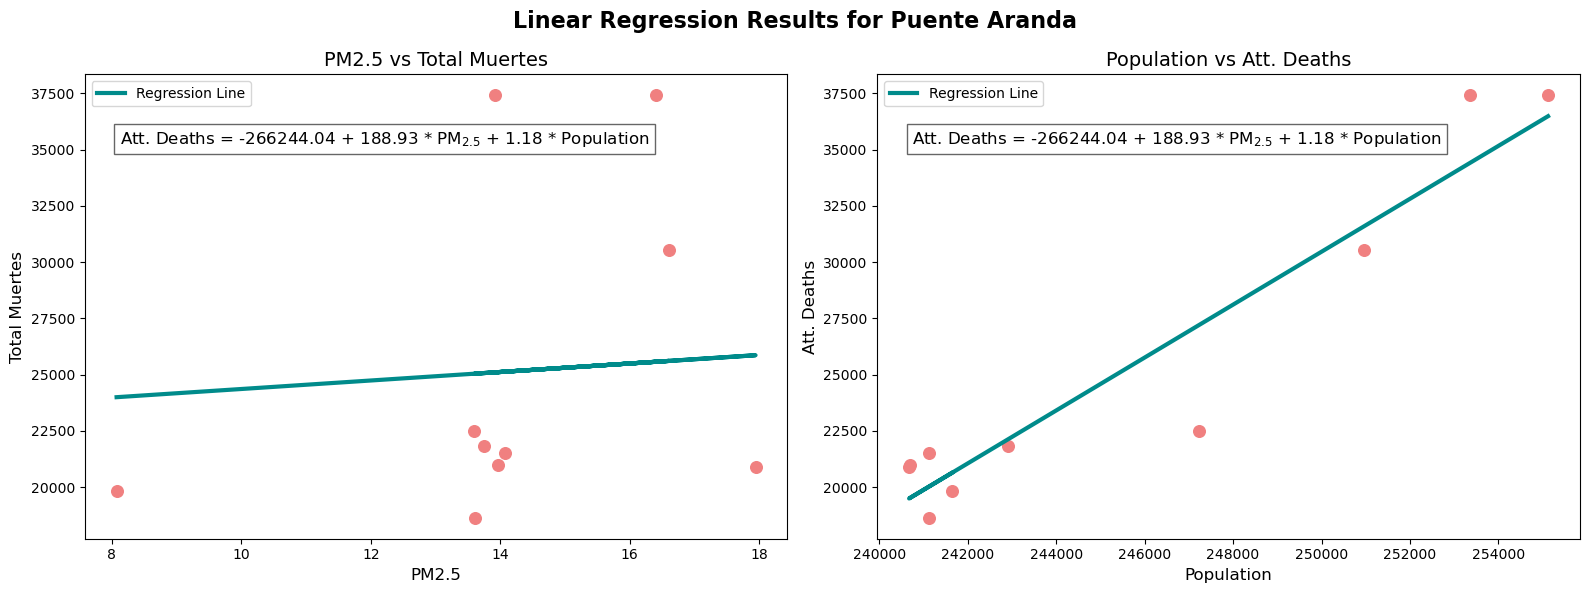

Regression Significance for San Cristóbal:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     20.71
Date:                Tue, 04 Mar 2025   Prob (F-statistic):            0.00115
Time:                        13:31:45   Log-Likelihood:                -79.610
No. Observations:                  10   AIC:                             165.2
Df Residuals:                       7   BIC:                             166.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


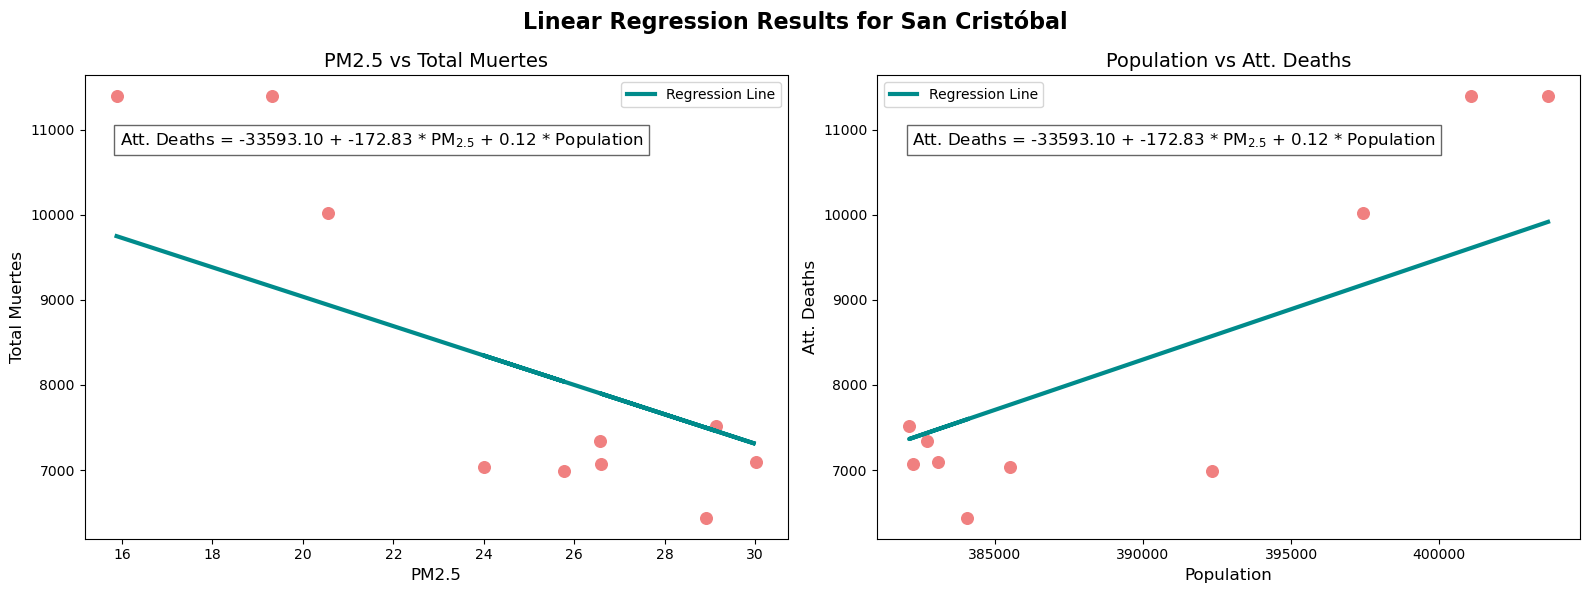

Regression Significance for Suba:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     31.14
Date:                Tue, 04 Mar 2025   Prob (F-statistic):           0.000678
Time:                        13:31:45   Log-Likelihood:                -88.986
No. Observations:                   9   AIC:                             184.0
Df Residuals:                       6   BIC:                             184.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const   

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


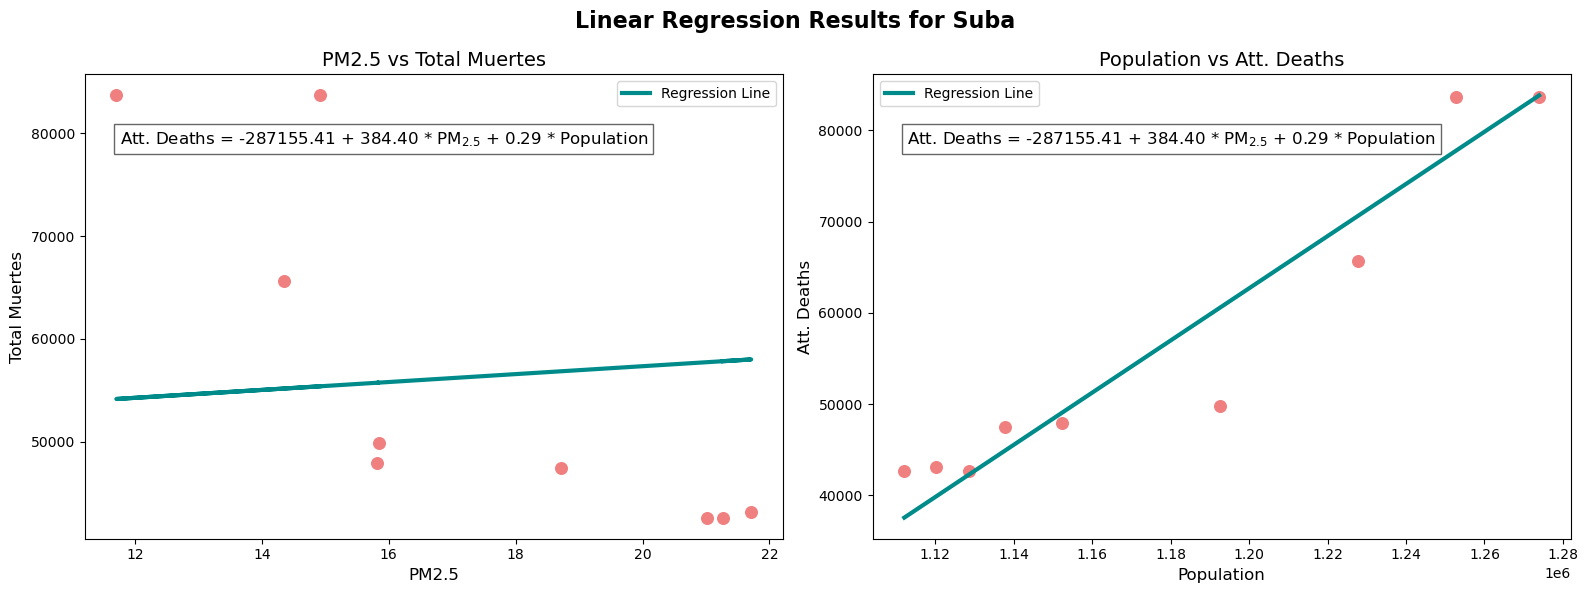

Regression Significance for Teusaquillo:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     47.98
Date:                Tue, 04 Mar 2025   Prob (F-statistic):           8.19e-05
Time:                        13:31:45   Log-Likelihood:                -80.874
No. Observations:                  10   AIC:                             167.7
Df Residuals:                       7   BIC:                             168.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
c

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


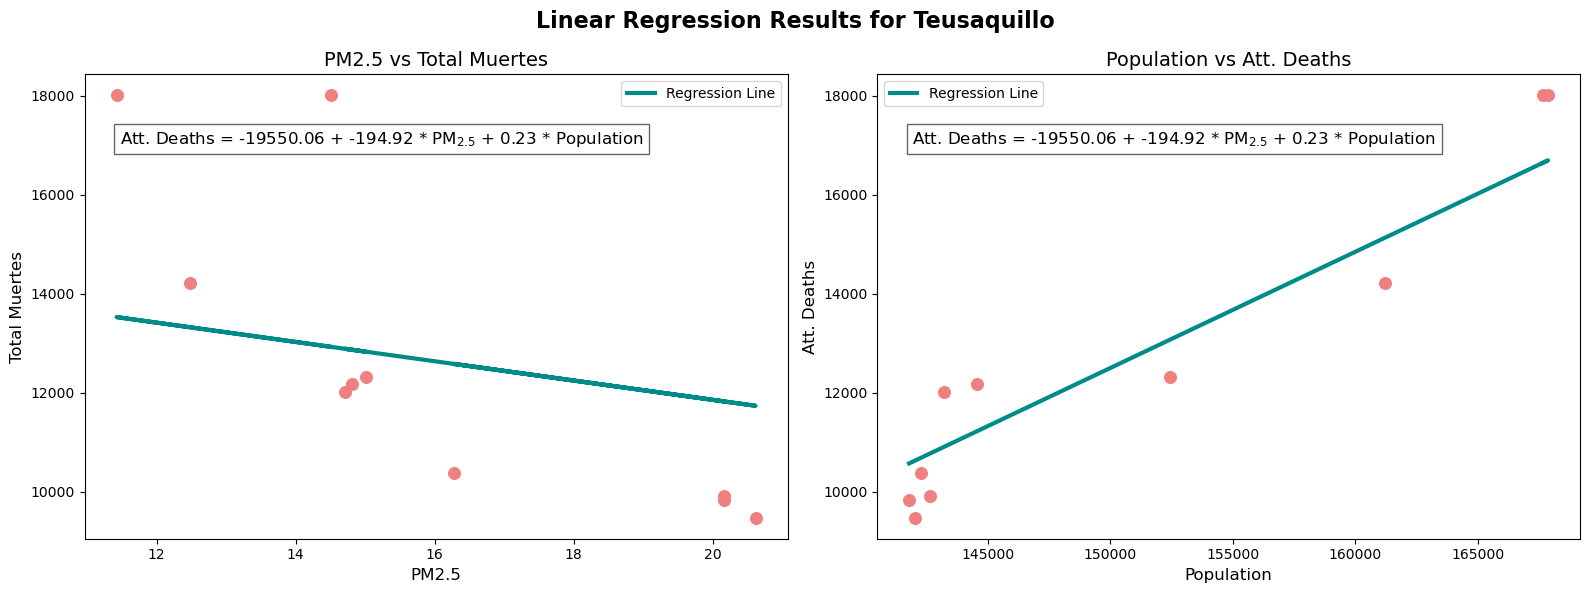

Regression Significance for Tunjuelito:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     37.82
Date:                Tue, 04 Mar 2025   Prob (F-statistic):           0.000177
Time:                        13:31:46   Log-Likelihood:                -74.151
No. Observations:                  10   AIC:                             154.3
Df Residuals:                       7   BIC:                             155.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
co

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


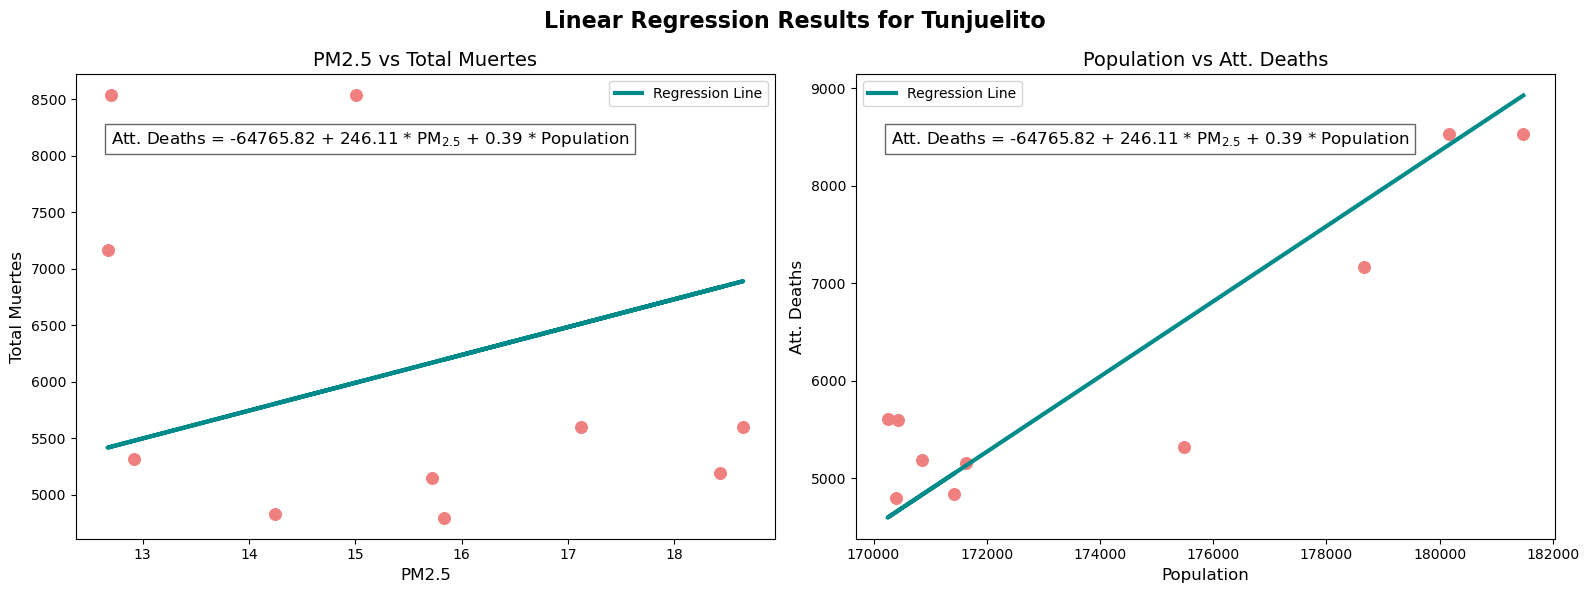

Regression Significance for Usaquén:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     28.39
Date:                Tue, 04 Mar 2025   Prob (F-statistic):           0.000438
Time:                        13:31:46   Log-Likelihood:                -68.368
No. Observations:                  10   AIC:                             142.7
Df Residuals:                       7   BIC:                             143.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


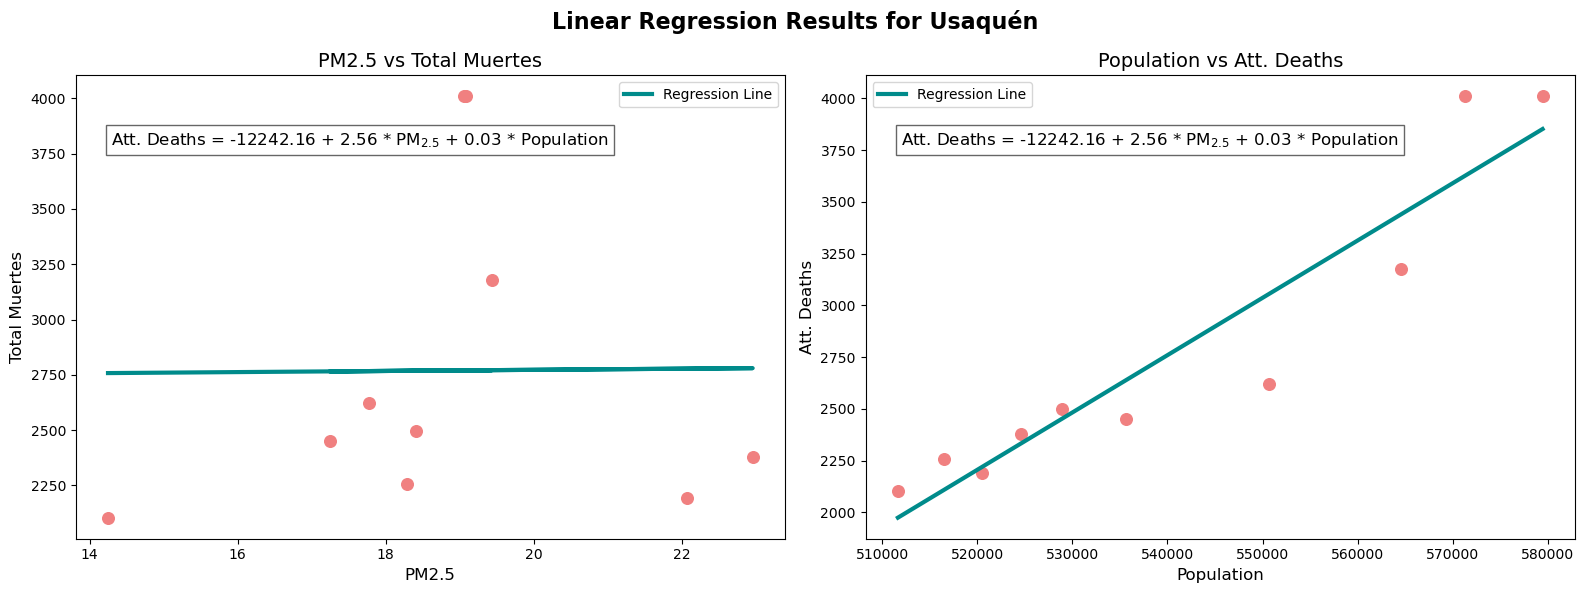

Regression Significance for Usme:
                            OLS Regression Results                            
Dep. Variable:          Total Muertes   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     51.07
Date:                Tue, 04 Mar 2025   Prob (F-statistic):           6.68e-05
Time:                        13:31:46   Log-Likelihood:                -76.966
No. Observations:                  10   AIC:                             159.9
Df Residuals:                       7   BIC:                             160.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const   

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


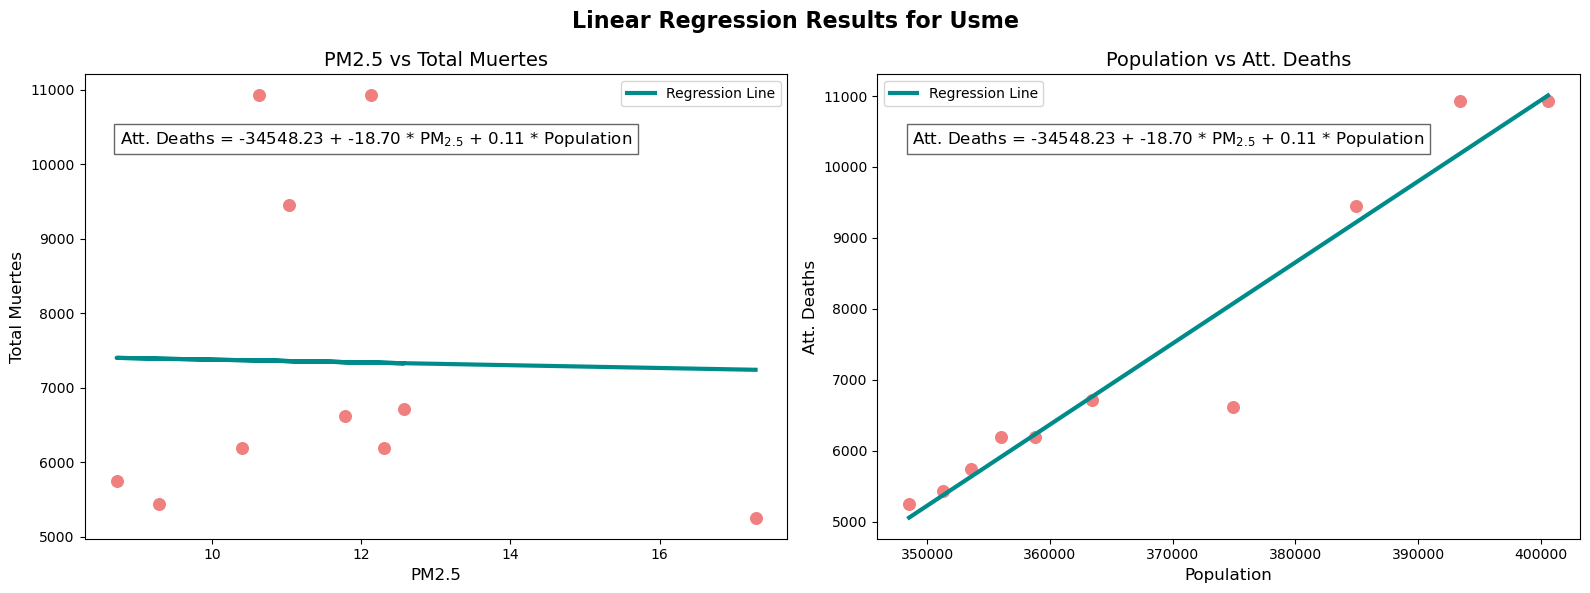

In [ ]:
# Iterate through the regression results for each location
for location, results in regression_results.items():
    # Filter data for the current location
    location_data = df_grouped[df_grouped['LOCALIDAD'] == location]

    # Create a figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Linear Regression Results for {location}', fontsize=16, fontweight='bold')

    # Extract coefficients and intercept
    intercept = results['intercept']
    coef_pm25 = results['coefficients'][0]
    coef_population = results['coefficients'][1]

    # **PM2.5 vs Total Muertes**
    axes[0].scatter(location_data['PM2.5'], location_data['Total Muertes'], color='lightcoral', s=70)
    axes[0].set_xlabel('PM2.5', fontsize=12)
    axes[0].set_ylabel('Total Muertes', fontsize=12)  # Keep "Total Muertes" in Spanish
    axes[0].set_title('PM2.5 vs Total Muertes', fontsize=14)

    # Calculate predicted Total Muertes based on PM2.5
    pm25_predictions = intercept + coef_pm25 * location_data['PM2.5'] + coef_population * location_data['Total Población'].mean()
    axes[0].plot(location_data['PM2.5'], pm25_predictions, color='darkcyan', label='Regression Line', linewidth=3)
    axes[0].legend()

    # Display the regression equation in the plot
    equation_pm25 = f'Att. Deaths = {intercept:.2f} + {coef_pm25:.2f} * PM$_{{2.5}}$ + {coef_population:.2f} * Population'
    axes[0].text(0.05, 0.85, equation_pm25, transform=axes[0].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.6))

    # **Total Población vs Total Muertes**
    axes[1].scatter(location_data['Total Población'], location_data['Total Muertes'], color='lightcoral', s=70)
    axes[1].set_xlabel('Population', fontsize=12)  # Keep "Total Población" in Spanish
    axes[1].set_ylabel('Att. Deaths', fontsize=12)  # Keep "Total Muertes" in Spanish
    axes[1].set_title('Population vs Att. Deaths', fontsize=14)

    # Calculate predicted Total Muertes based on Total Población
    population_predictions = intercept + coef_pm25 * location_data['PM2.5'].mean() + coef_population * location_data['Total Población']
    axes[1].plot(location_data['Total Población'], population_predictions, color='darkcyan', label='Regression Line', linewidth=3)
    axes[1].legend()

    # Display the regression equation in the plot
    equation_population = f"Att. Deaths = {intercept:.2f} + {coef_pm25:.2f} * PM$_{{2.5}}$ + {coef_population:.2f} * Population"
    axes[1].text(0.05, 0.85, equation_population, transform=axes[1].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.6))

    # **Calculate Regression Significance**
    X = location_data[['PM2.5', 'Total Población']]
    y = location_data['Total Muertes']
    X = sm.add_constant(X)  # Add constant for intercept

    model = sm.OLS(y, X).fit()
    p_values = model.pvalues
    r_squared = model.rsquared

    # Display significance results
    print(f"Regression Significance for {location}:")
    print(model.summary())  # Print full regression summary

    # Add R² value to the figure
    #r_squared_text = f'R² = {r_squared:.3f}'
    #axes[0].text(0.75, 0.1, r_squared_text, transform=axes[0].transAxes, fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6))
    #axes[1].text(0.75, 0.1, r_squared_text, transform=axes[1].transAxes, fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6))

    plt.tight_layout()
    plt.show()